# Modelos para Dados Tabulares em 2026 — um benchmark multicritério
### Acompanhamento Individual 1 · João Gabriel de Araújo Vasconcelos

**14 modelos × 18 datasets (OpenML)** · nested cross-validation (5×3) · tuning bayesiano (Optuna TPE) ·
testes estatísticos frequentistas **e** bayesianos · GPU única (RTX 5080).

> **Tese da apresentação.** O ditado *"em dados tabulares, GBDT sempre vence"* foi formado antes da
> geração 2024–2026 de deep learning tabular (TabM, RealMLP, STab, KANs) e dos *foundation models*
> (TabPFN v2.5, TabFM). Re-testamos com rigor — e mostramos **dois movimentos**: (1) entre GBDTs e o
> deep learning, a acurácia **empata**, e a decisão migra para outros eixos (custo, latência, robustez,
> estrutura da tarefa); (2) a geração 2026 de foundation models **quebra esse empate** em acurácia — ao
> custo de ~5 ordens de magnitude em latência, o que torna o arcabouço multicritério *mais* necessário,
> não menos. A contribuição é tornar essa decisão rigorosa, multi-eixo e acionável (**matriz de decisão +
> flowchart, agora validados quantitativamente**).

*Este notebook é autocontido: as figuras estão embutidas; o código que gera os números-chave está visível.*

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
FIG = '../results/figures'

def show(name, caption=None, width=820):
    p = f'{FIG}/{name}'
    display(Image(filename=p, width=width))
    if caption:
        display(Markdown(f'*{caption}*'))

print('presentation helpers ready')

presentation helpers ready


---
## 1. Os 14 modelos — proveniência e escolhas de implementação

Um ponto metodológico importante (e honesto): **nem todo modelo veio "de graça" de uma biblioteca.**
A tabela abaixo registra, para cada modelo, **de onde** veio a implementação — biblioteca oficial,
biblioteca da comunidade, ou **implementação própria** (reimplementada a partir do artigo / repositório
original). Isso afeta a interpretação dos resultados e foi parte significativa do trabalho de engenharia.

| # | Modelo | Família | Ano | Proveniência da implementação |
|---|--------|---------|-----|-------------------------------|
| 1 | **XGBoost** | GBDT | 2016 | Biblioteca oficial `xgboost` |
| 2 | **LightGBM** | GBDT | 2017 | Biblioteca oficial `lightgbm` |
| 3 | **CatBoost** | GBDT | 2018 | Biblioteca oficial `catboost` (handling categórico nativo) |
| 4 | **TabPFN v2.5** | Foundation | 2025 | Pacote oficial `tabpfn` (≥6.0) |
| 5 | **RealMLP** | DL (MLP) | 2024 | Pacote oficial `pytabkit` (Holzmüller et al., NeurIPS 2024) |
| 6 | **TabM** | DL (MLP) | 2025 | Pacote oficial `tabm` (Gorishniy et al., ICLR 2025) |
| 7 | **TabNet** | DL (attn+seleção) | 2021 | Biblioteca da comunidade `pytorch-tabnet` |
| 8 | **MLP** | DL (baseline) | — | **Implementação própria** (PyTorch): Linear→BatchNorm→ReLU→Dropout |
| 9 | **FT-Transformer** | DL (attention) | 2021 | **Implementação própria** da arquitetura + loop de treino custom |
| 10 | **SAINT** | DL (attention dupla) | 2021 | **Reimplementação própria a partir do artigo** (Somepalli et al., 2021) |
| 11 | **STab** | DL (competição estocástica) | 2024 | **Reimplementação própria a partir do artigo + repo de referência** (Voskou et al., ICML 2024 W) |
| 12 | **KAN** | DL (Kolmogorov-Arnold) | 2024 | Backbone `efficient-kan` (MIT) **vendorizado** + wrapper próprio (LayerNorm por camada, grid [-2,2] — desvios documentados) |
| 13 | **TabKAN** | DL (ChebyKAN) | 2025 | **Reimplementação própria a partir do artigo** (Eslamian et al., 2025) — pacote oficial incompatível com o protocolo (L-BFGS full-batch, sem early stopping/regressão) |
| 14 | **TabFM** | Foundation | 2026 | Pacote oficial Google (`tabfm`, commit pinado), pesos bf16 do Hugging Face; **sem paper peer-reviewed até jul/2026** (blog + model card) |

**Resumo da proveniência:** 7 de bibliotecas oficiais (3 GBDT + TabPFN + TabFM + RealMLP + TabM),
1 da comunidade (TabNet), 1 vendorizado com adaptações (KAN), e **5 implementações próprias em PyTorch**
(MLP, FT-Transformer, SAINT, STab, TabKAN) — as reimplementações passaram por *sanity check* contra os
valores publicados (ex.: TabKAN reproduz ~0,91 de AUC no adult, compatível com o ~0,90 do paper).

**Por que esses 14 / por que DL super-representado (9):** a família DL concentra a maior diversidade de
*viés indutivo* — atenção (FT-Transformer, SAINT, STab), MLP (MLP, RealMLP, TabM), atenção+seleção
(TabNet) e **Kolmogorov-Arnold** (KAN, TabKAN — ativações aprendíveis nas arestas, sem teste neutro
prévio na literatura). GBDTs (3) são o padrão de mercado; os **2 foundation models** (TabPFN, TabFM)
permitem testar se o paradigma zero-shot *replica entre laboratórios* (Prior Labs vs Google). Cobrir as
três famílias é o que torna o estudo um mapa do estado da arte, não um duelo.

### 1.1 Escolhas de arquitetura / implementação que importam

Estas decisões afetam a *justiça* da comparação e foram tomadas explicitamente:

- **Pré-processamento por família** (cada família recebe o input no formato que espera):
  - **GBDT** — *ordinal encoding* + imputação por mediana; **CatBoost** recebe os índices das colunas
    categóricas e usa seu *handling* nativo.
  - **Deep learning** — *standardização* dos numéricos + *one-hot* dos categóricos, com **teto de
    cardinalidade (max 50 categorias)**. Esse teto foi necessário: sem ele, `amazon_employee` explodia
    para ~6.900 colunas e estourava a memória da GPU nos modelos de atenção.
  - **TabPFN** — ordinal; normaliza internamente; **subamostra para 50K** (limite nativo da v2.5) e usa
    um *ensemble* de 4 subamostras para datasets maiores; inferência em *batches* (predição é cara).
- **STab** — usa **64 amostras de *Bayesian averaging*** na avaliação final (8 durante o tuning, por
  custo); ativação **LWTA (Local Winner-Takes-All)** com relaxação Gumbel-Softmax.
- **Treino DL** — máx. 200 épocas, *early stopping* (paciência 20), batch 256, Adam.
- **Robustez de execução** — *cap* de 100K amostras antes do split; redução automática de *batch size*
  em OOM + isolamento por subprocesso (um config grande não derruba a fila inteira).

---
## 2. Protocolo experimental

O esqueleto é uma **validação cruzada aninhada (nested CV)**: o laço externo *mede* o modelo de forma
honesta; o laço interno *escolhe* os hiperparâmetros — sem nunca olhar o conjunto de teste. Abaixo,
um esquema do pipeline ponta-a-ponta.

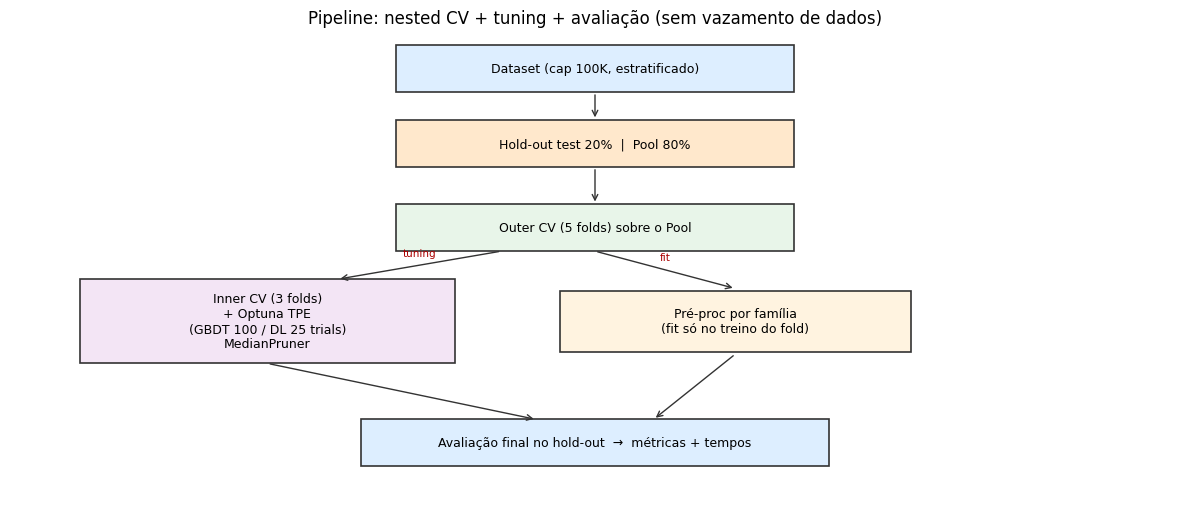

In [2]:
# Esquema do protocolo (desenhado, não é uma figura externa)
fig, ax = plt.subplots(figsize=(12, 5.2)); ax.axis('off')
def b(x,y,t,c='#eef',w=0.2,h=0.1):
    ax.add_patch(plt.Rectangle((x-w/2,y-h/2),w,h,fc=c,ec='#333',lw=1.2))
    ax.text(x,y,t,ha='center',va='center',fontsize=9)
def ar(x1,y1,x2,y2,lbl=''):
    ax.annotate('',(x2,y2),(x1,y1),arrowprops=dict(arrowstyle='->',color='#333'))
    if lbl: ax.text((x1+x2)/2,(y1+y2)/2+0.02,lbl,fontsize=7.5,color='#a00',ha='center')
b(0.5,0.92,'Dataset (cap 100K, estratificado)','#ddeeff',0.34,0.1)
b(0.5,0.76,'Hold-out test 20%  |  Pool 80%','#ffe8cc',0.34,0.1); ar(0.5,0.87,0.5,0.81)
b(0.5,0.58,'Outer CV (5 folds) sobre o Pool','#e8f5e9',0.34,0.1); ar(0.5,0.71,0.5,0.63)
b(0.22,0.38,'Inner CV (3 folds)\n+ Optuna TPE\n(GBDT 100 / DL 25 trials)\nMedianPruner','#f3e5f5',0.32,0.18)
b(0.62,0.38,'Pré-proc por família\n(fit só no treino do fold)','#fff3e0',0.3,0.13)
ar(0.42,0.53,0.28,0.47,'tuning'); ar(0.5,0.53,0.62,0.45,'fit')
b(0.5,0.12,'Avaliação final no hold-out  →  métricas + tempos','#ddeeff',0.4,0.1)
ar(0.22,0.29,0.45,0.17); ar(0.62,0.31,0.55,0.17)
ax.set_title('Pipeline: nested CV + tuning + avaliação (sem vazamento de dados)', fontsize=12)
plt.tight_layout(); plt.show()

**Configuração** (de `configs/experiment.yaml`):
seed=42 · test_size=0.2 · outer_folds=5 · inner_folds=3 · TPE com **MedianPruner** ·
**GBDT = 100 trials, DL/FM = 25 trials** (o custo por trial do DL é ~4× maior, daí o orçamento menor).

**Métricas** (primária / secundárias):
binária → **ROC-AUC** / acc, F1, log-loss, **KS** · multiclasse → **log-loss** / acc, F1-macro/weighted ·
regressão → **RMSE** / MAE, R². Tempos coletados: tuning, treino final, e **latência de inferência**.

**Hiperparâmetros tunados por modelo** (nº de HPs): xgboost 8 · lightgbm 9 · catboost 6 ·
ft_transformer 9 · tabnet 7 · saint 7 · mlp 5 · realmlp 9 · stab 8 · tabm 7 · **tabpfn 0 (zero-shot)**.

**Testes estatísticos:** Friedman (omnibus) → Nemenyi + Wilcoxon (Holm) + diagramas de *critical difference*;
Cohen's d (tamanho de efeito); ICs bootstrap; e — adicionado nesta fase — **teste bayesiano signed-rank
com ROPE** (probabilidade de superioridade, não só significância).

---
## 3. Os 18 datasets

10 binárias · 3 multiclasse · 5 regressão · de **1K a 581K** amostras · numéricos, mistos e categóricos.

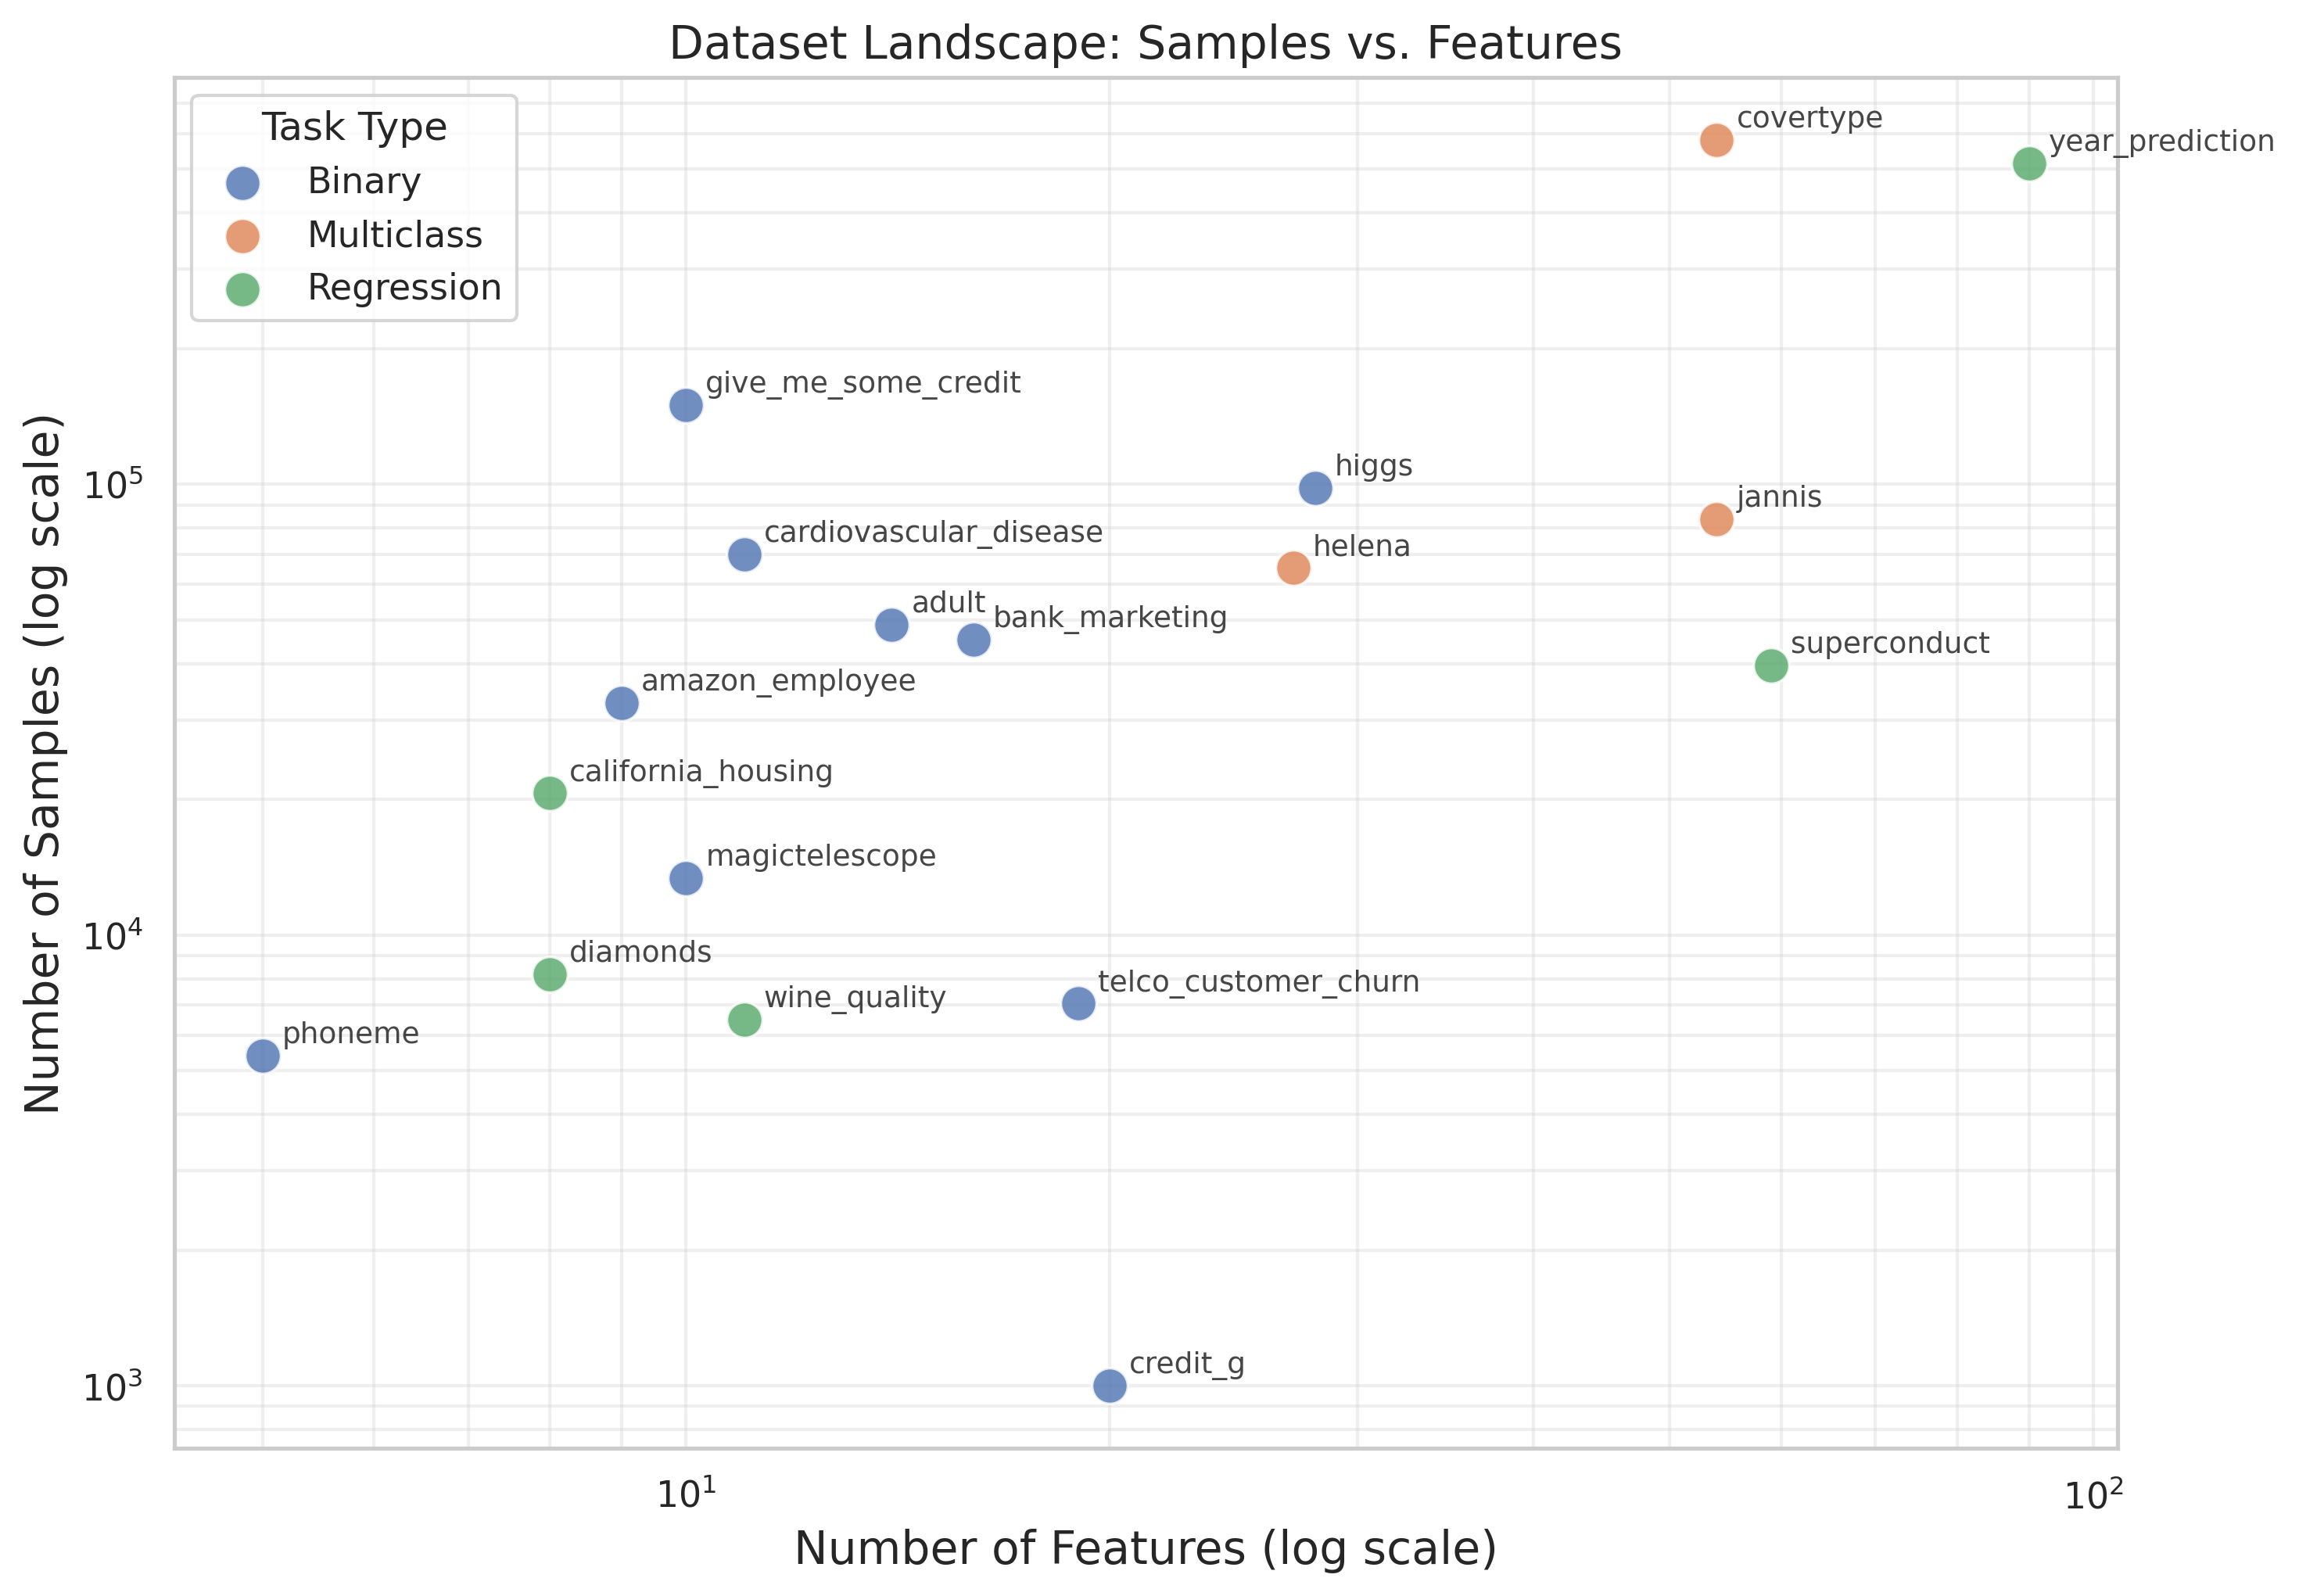

*Espaço amostras × features: o benchmark cobre 3 ordens de grandeza em tamanho e dimensionalidade.*

In [3]:
show('dataset_landscape.png', 'Espaço amostras × features: o benchmark cobre 3 ordens de grandeza em tamanho e dimensionalidade.', 720)

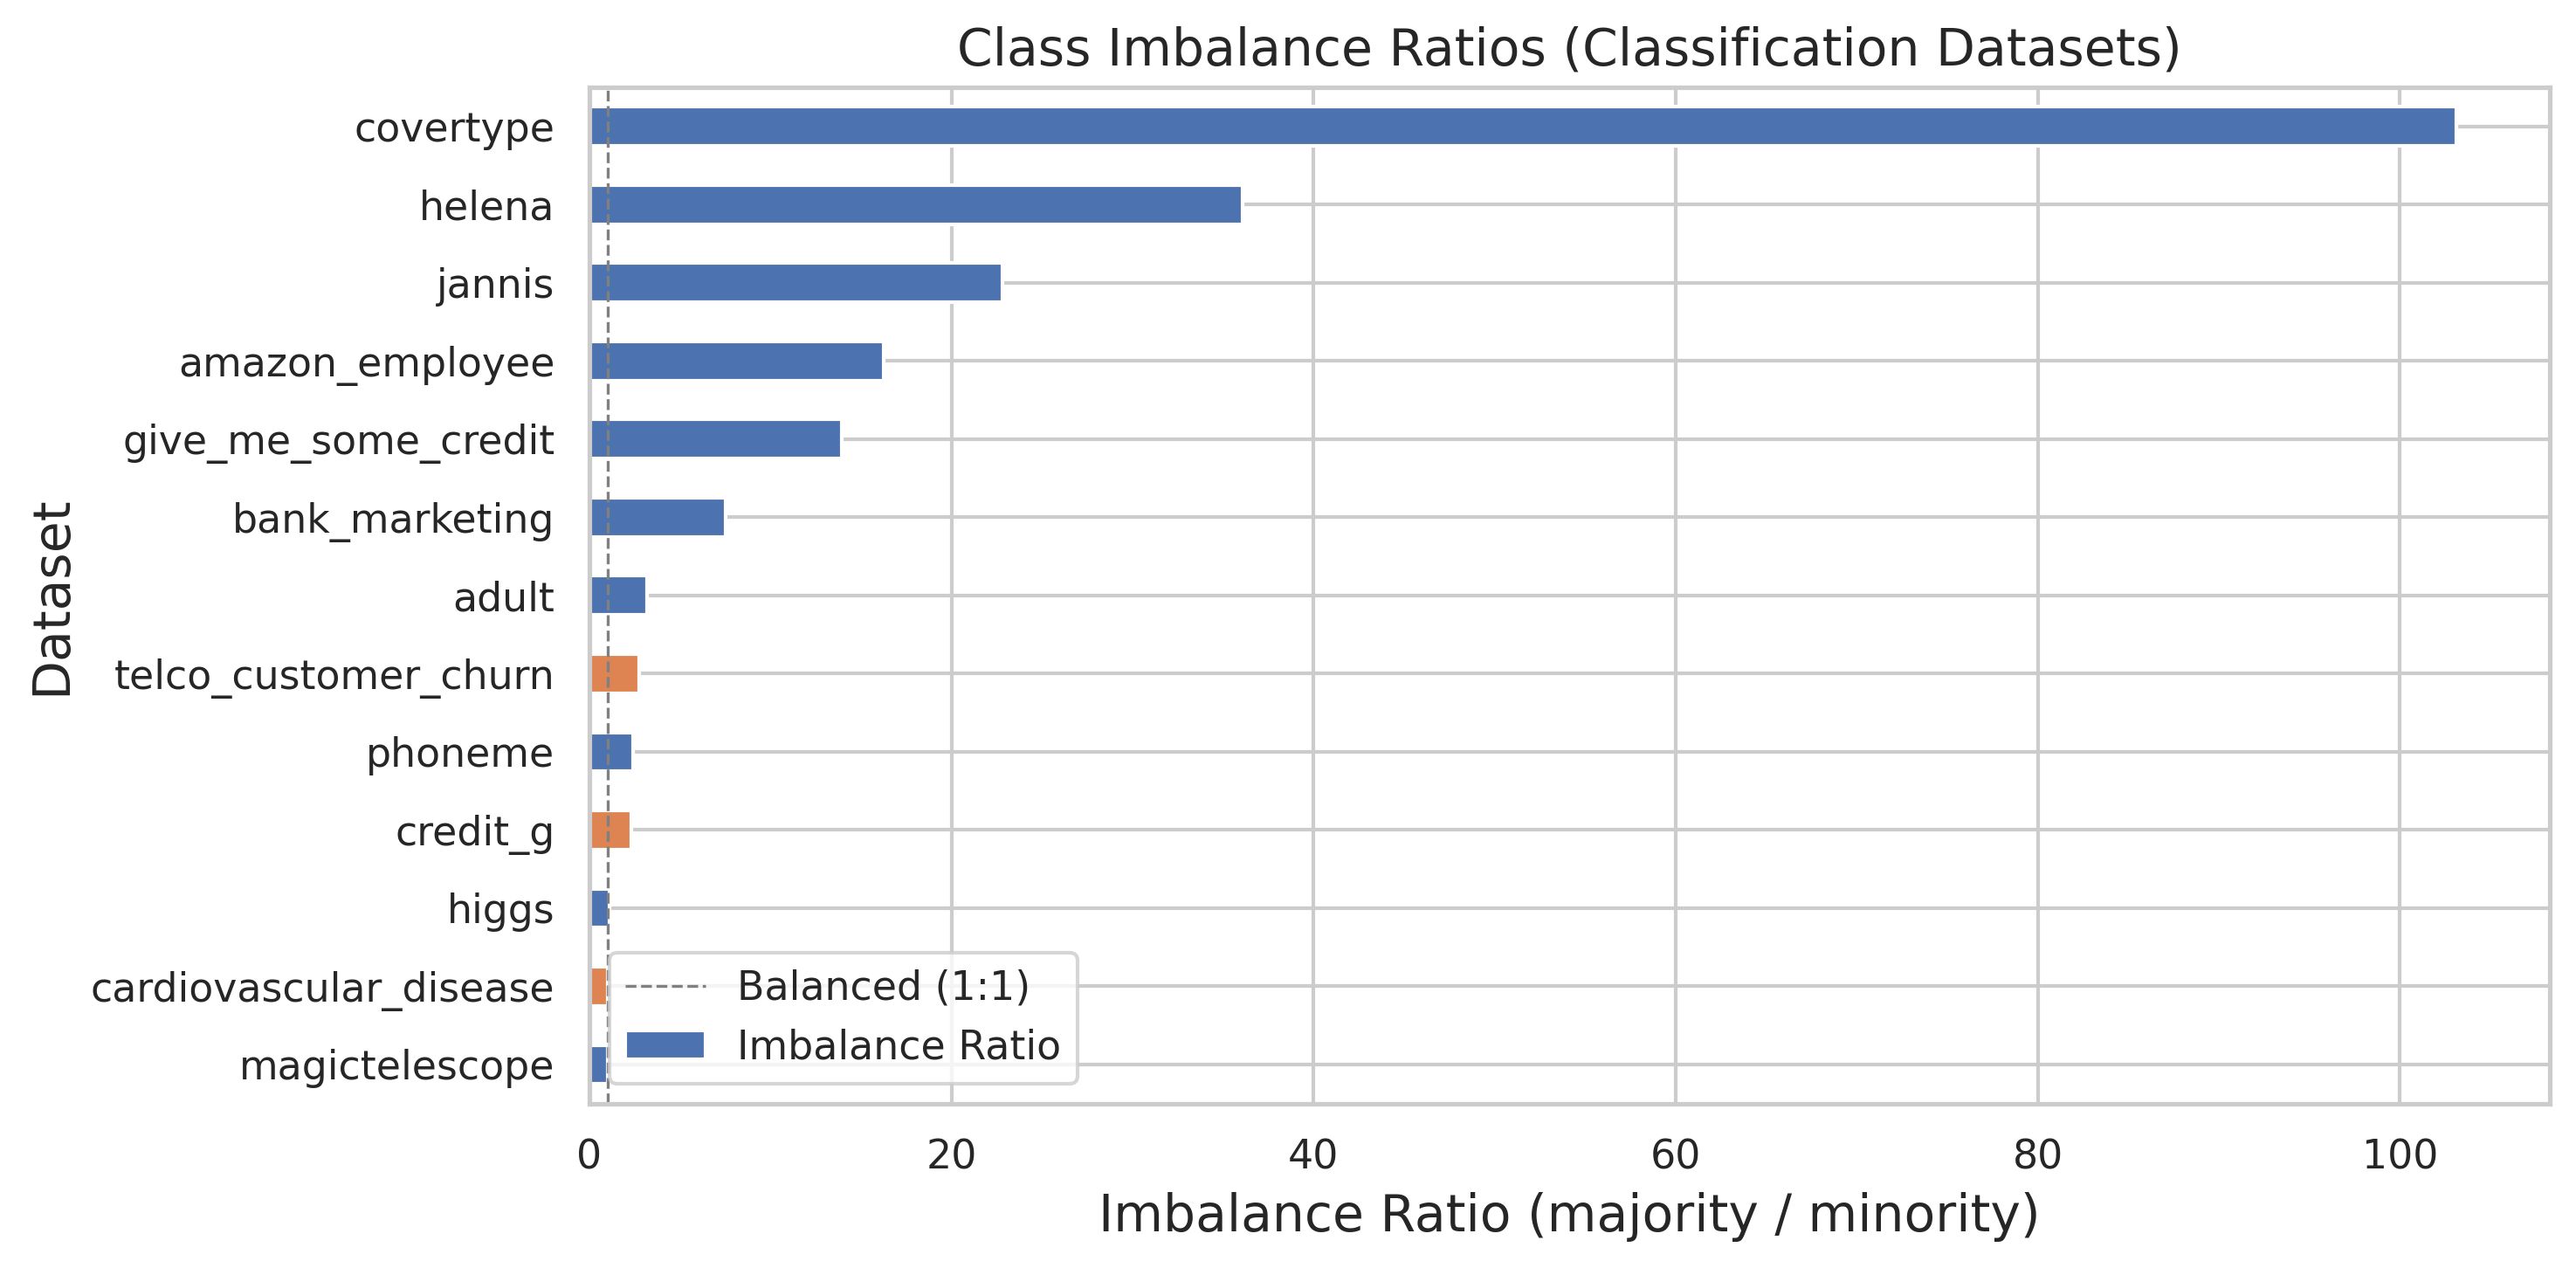

*Razões de desbalanceamento (classificação): de 1:1 a 16:1 — usado no eixo de robustez.*

In [4]:
show('class_imbalance.png', 'Razões de desbalanceamento (classificação): de 1:1 a 16:1 — usado no eixo de robustez.', 720)

---
## 4. Ato I — O Empate (a geração até 2025)

**Entre GBDTs, deep learning e o TabPFN — os 11 modelos da "geração até 2025" — o topo do campo é
estatisticamente indistinguível no desempenho bruto.** O Friedman acusa que *existe* diferença, mas o
post-hoc (Nemenyi/CD) não separa o cluster de topo. Confirmamos com **dois** instrumentos mais fortes
que uma média: o teste **bayesiano (ROPE)** e a **decomposição de variância**. *(A geração 2026 — TabFM
— quebra este empate: ver §6.2. As figuras abaixo já incluem os 14 modelos; a análise bayesiana desta
seção é declaradamente restrita aos 11 originais para caracterizar o empate histórico.)*

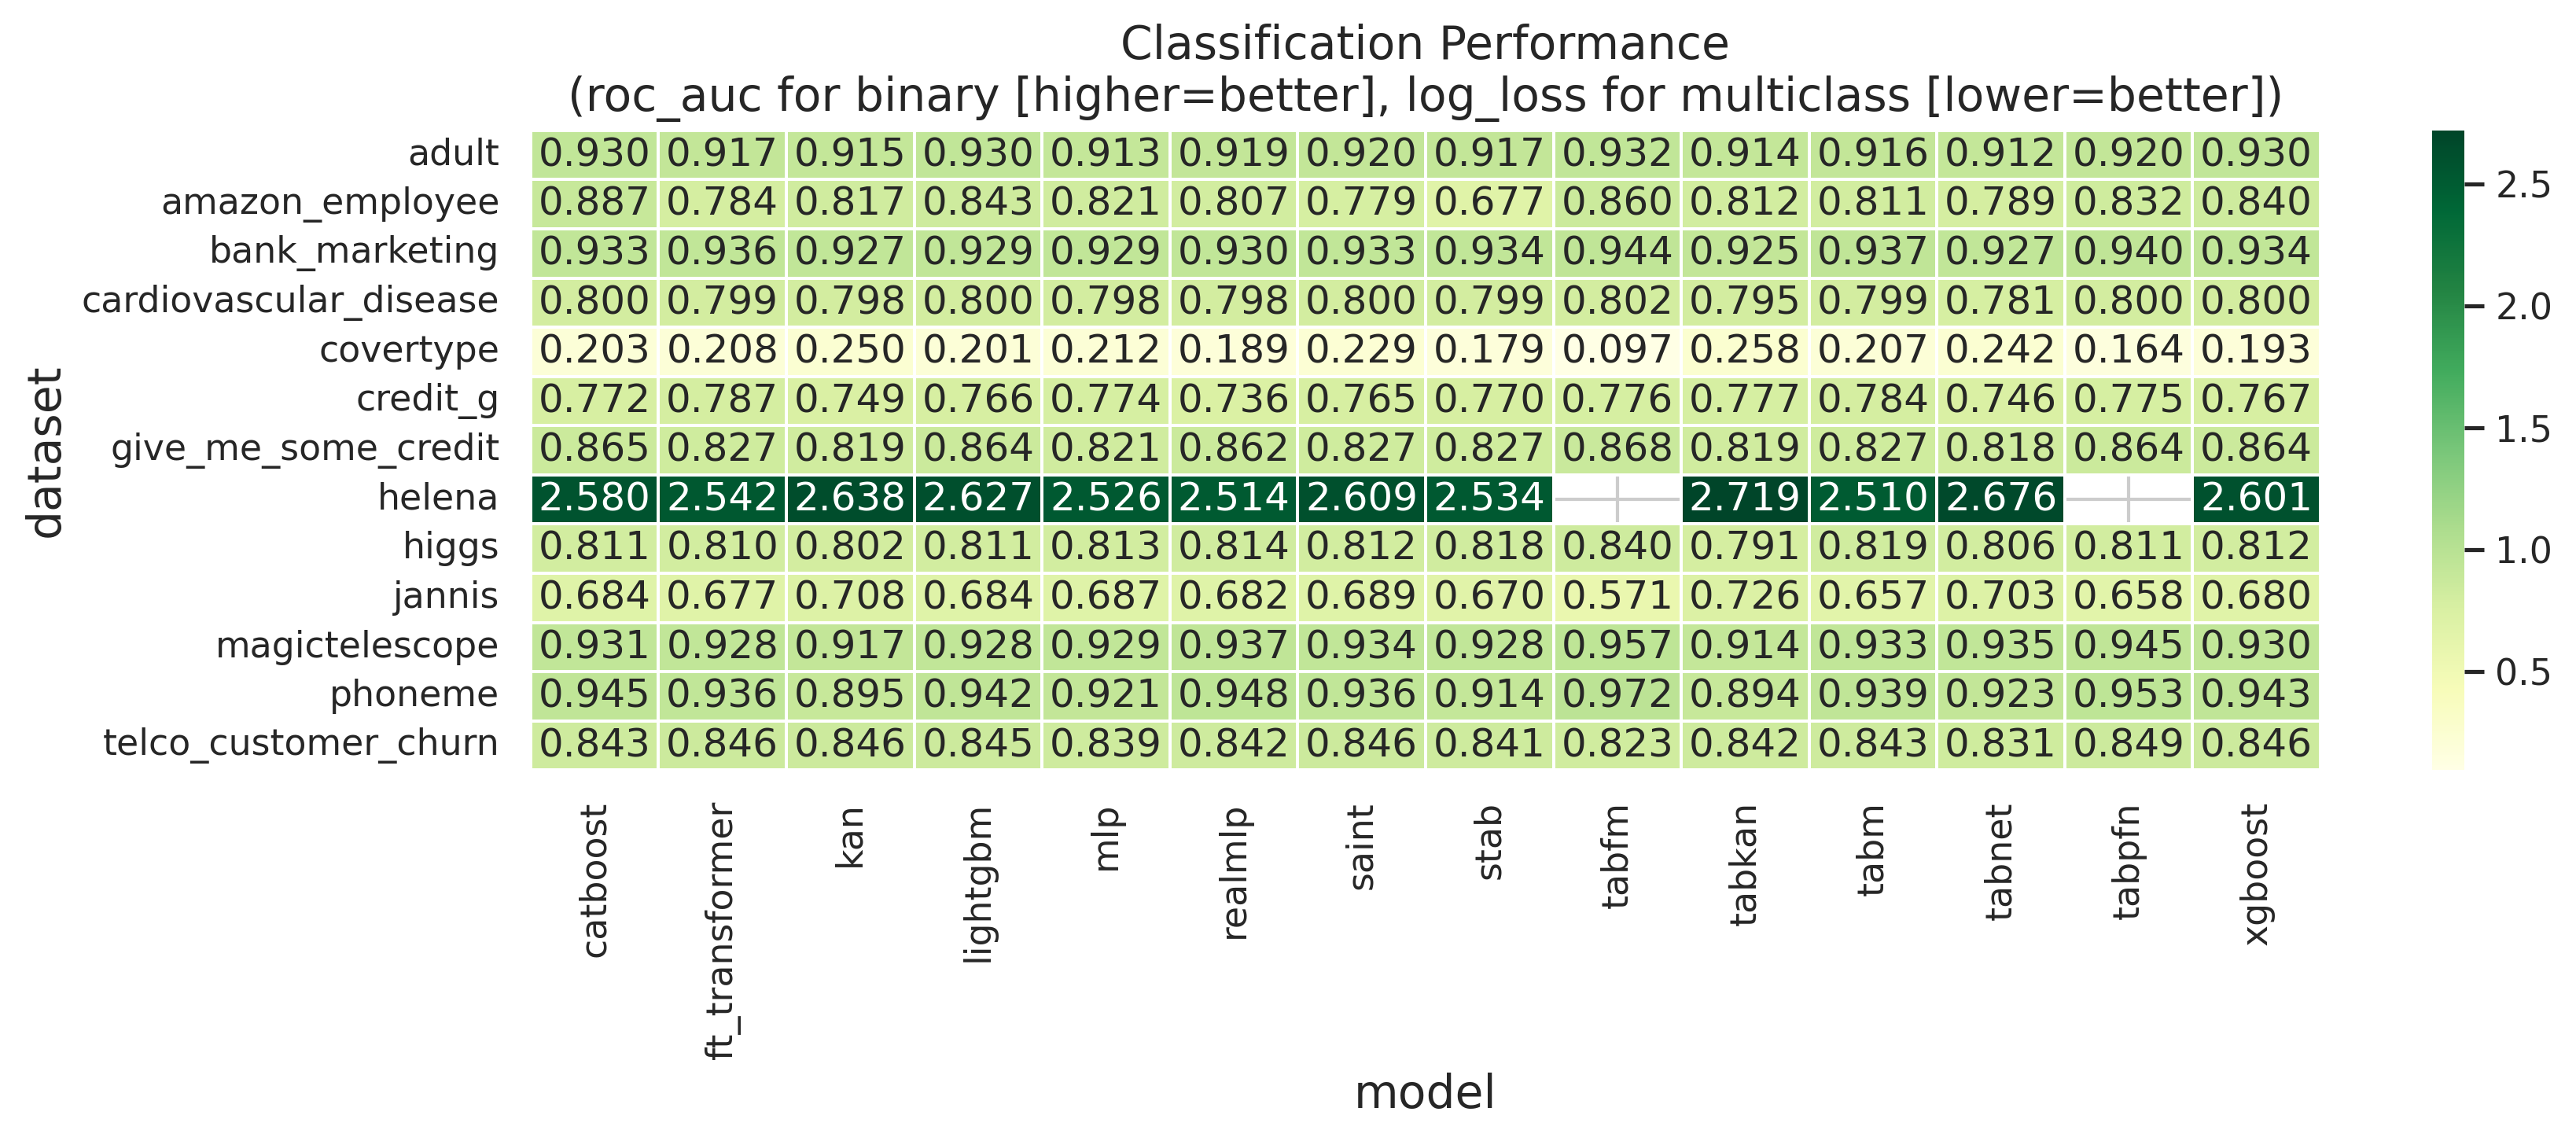

*Desempenho por modelo × dataset (ROC-AUC binária / log-loss multiclasse).*

In [5]:
show('heatmap_classification.png', 'Desempenho por modelo × dataset (ROC-AUC binária / log-loss multiclasse).', 880)

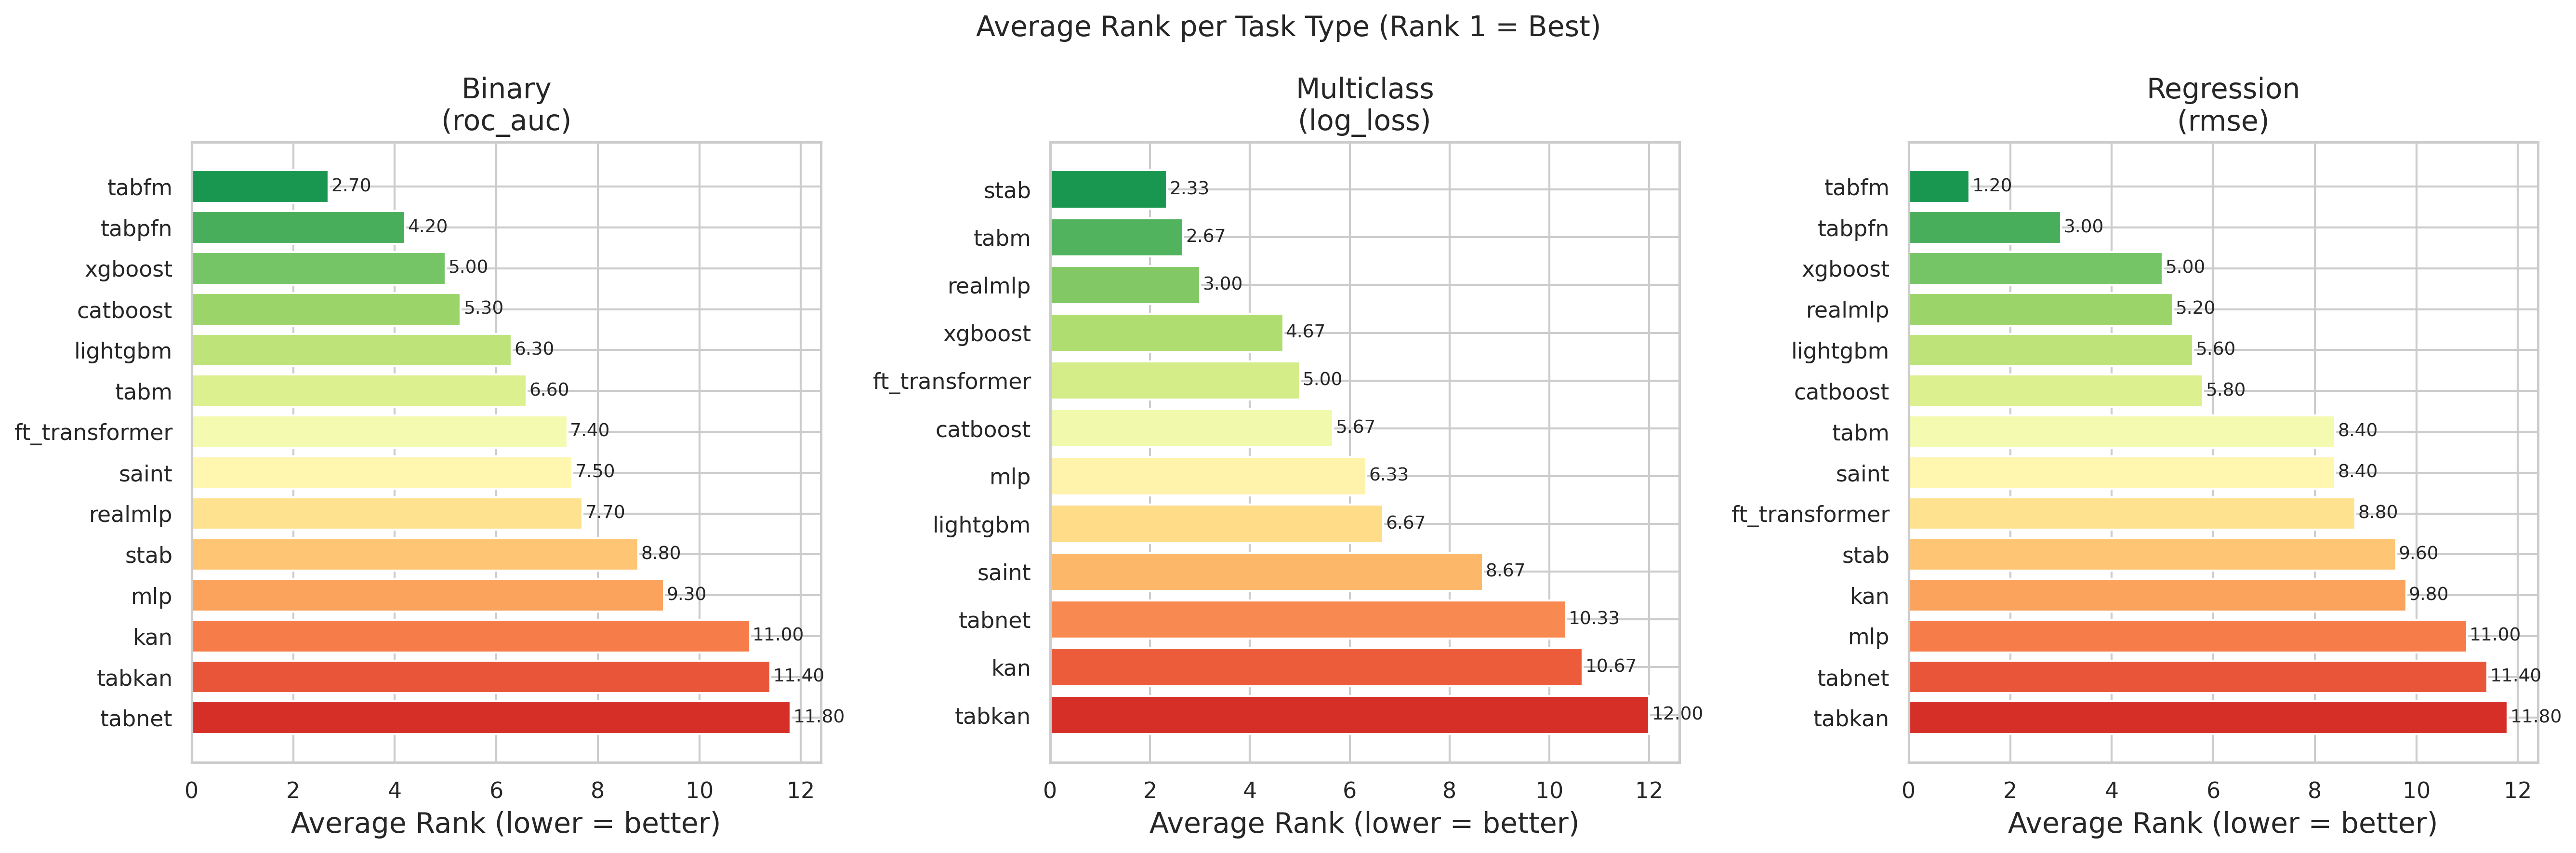

*Rank médio por tarefa (1 = melhor), agora com 14 modelos. O TabFM lidera as TRES tarefas (§6.2); entre os demais, TabPFN e GBDTs disputam binária/regressão e o DL lidera multiclasse.*

In [6]:
show('average_ranks.png', 'Rank médio por tarefa (1 = melhor), agora com 14 modelos. O TabFM lidera as TRES tarefas (§6.2); entre os demais, TabPFN e GBDTs disputam binária/regressão e o DL lidera multiclasse.', 880)

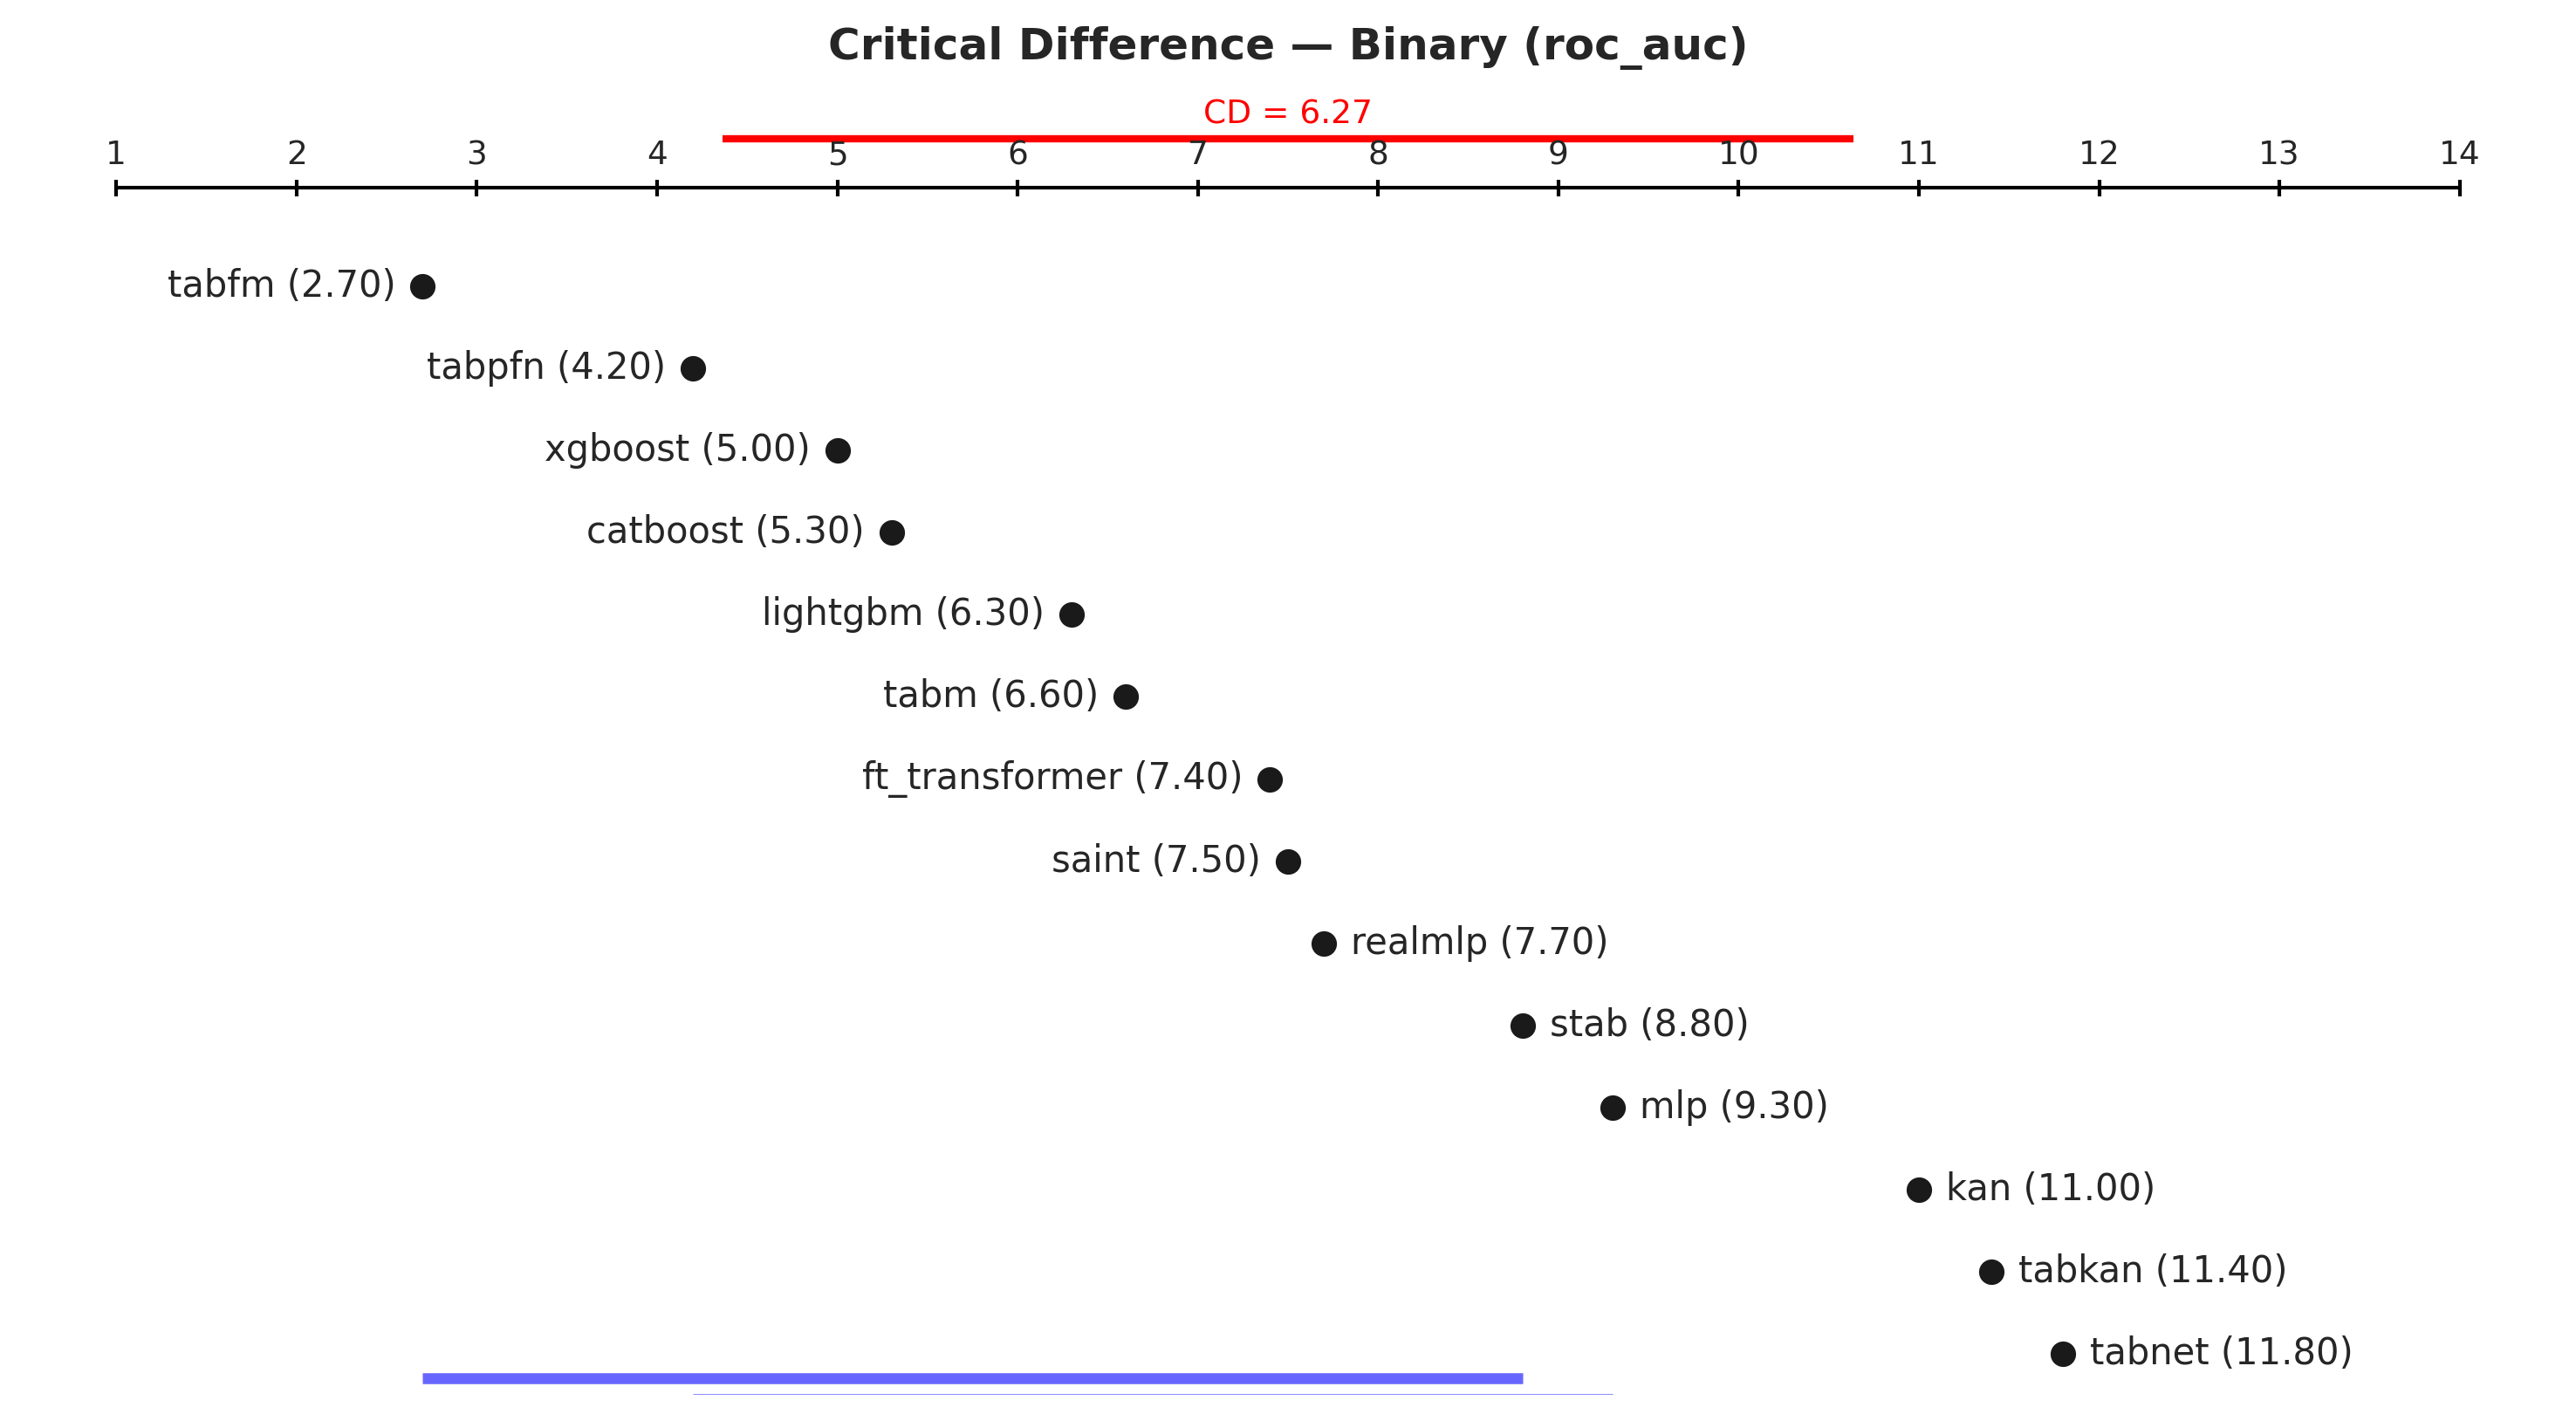

*Critical Difference (binária, 14 modelos): modelos ligados pela barra NÃO são significativamente diferentes. Com k=14 e N=10 o CD é largo — a separação do TabFM vem da consistência (13/18 vitórias) e do bayesiano, não do Nemenyi.*

In [7]:
show('cd_diagram_binary.png', 'Critical Difference (binária, 14 modelos): modelos ligados pela barra NÃO são significativamente diferentes. Com k=14 e N=10 o CD é largo — a separação do TabFM vem da consistência (13/18 vitórias) e do bayesiano, não do Nemenyi.', 720)

In [8]:
# Rigor do empate (1): bayesiano signed-rank vs o lider da geracao ate 2025 (TabPFN), ROPE = 0.01 AUC
# Escopo DECLARADO: restrito aos 11 modelos originais — o empate historico que a geracao 2026 quebra (§6.2)
from src.models.factory import get_model_family
from src.evaluation.enrichments import bayesian_pairwise_table, family_variance_decomposition
GEN2025 = ['xgboost', 'lightgbm', 'catboost', 'tabpfn', 'realmlp', 'tabm',
           'tabnet', 'mlp', 'ft_transformer', 'saint', 'stab']
test = pd.read_csv('../results/aggregated/test_results.csv')
FAM = {m: get_model_family(m) for m in test.model.unique()}
piv = (test[test.task_type=='binary']
       .pivot(index='dataset', columns='model', values='roc_auc')[GEN2025].dropna(axis=1))
bt = bayesian_pairwise_table(piv, higher_is_better=True, rope=0.01, ref='tabpfn').sort_values('P(better)', ascending=False)
print('Bayesian signed-rank vs TabPFN (binaria, ROPE = +/-0.01 AUC, 11 modelos ate-2025):')
display(bt.round(2))
print(f"{(bt['P(equiv)']>0.5).sum()}/{len(bt)} modelos sao PRATICAMENTE EQUIVALENTES ao TabPFN.")
sens = pd.read_csv('../results/aggregated/rope_sensitivity.csv')
print('\nSensibilidade do ROPE (robustez da conclusao):')
print(sens.to_string(index=False))
print('No limiar estrito (0.005), XGBoost e CatBoost seguem equivalentes ao TabPFN.')

Bayesian signed-rank vs TabPFN (binaria, ROPE = +/-0.01 AUC, 11 modelos ate-2025):


,model,vs,P(worse),P(equiv),P(better)
2,catboost,tabpfn,0.05,0.78,0.17
1,lightgbm,tabpfn,0.15,0.82,0.03
7,ft_transformer,tabpfn,0.44,0.54,0.02
0,xgboost,tabpfn,0.06,0.94,0.00
4,tabm,tabpfn,0.36,0.64,0.00
3,realmlp,tabpfn,0.33,0.67,0.00
5,tabnet,tabpfn,0.82,0.18,0.00
6,mlp,tabpfn,0.49,0.51,0.00
8,saint,tabpfn,0.44,0.56,0.00
9,stab,tabpfn,0.55,0.45,0.00


8/10 modelos sao PRATICAMENTE EQUIVALENTES ao TabPFN.

Sensibilidade do ROPE (robustez da conclusao):
 rope  n_equiv_of_10  mean_P_equiv
0.005              2         0.378
0.010              8         0.608
0.020             10         0.800
No limiar estrito (0.005), XGBoost e CatBoost seguem equivalentes ao TabPFN.


In [9]:
# Rigor do empate (2): a variancia de rank e' majoritariamente INTRA-familia
vd = family_variance_decomposition(piv.rank(axis=1, ascending=False), FAM)
print(f"eta^2 (parcela ENTRE-familias da variancia de rank) = {vd['eta_squared']:.2f}")
print(f"-> {(1-vd['eta_squared'])*100:.0f}% da variancia e' INTRA-familia: 'GBDT vs DL' e' uma abstracao fraca;")
print(f"   o modelo importa mais que a familia.  Ranks medios por familia: {vd['family_mean_rank']}")

eta^2 (parcela ENTRE-familias da variancia de rank) = 0.20
-> 80% da variancia e' INTRA-familia: 'GBDT vs DL' e' uma abstracao fraca;
   o modelo importa mais que a familia.  Ranks medios por familia: {'deep_learning': 7.043, 'foundation_model': 3.2, 'gbdt': 4.5}


**Leitura do Ato I.** Entre os modelos da geração até 2025, a manchete não é *quem venceu* — é que
*ninguém venceu por margem perceptível*. A maioria está dentro do ROPE do TabPFN (praticamente
equivalentes), e 80% da variância de rank é interna às famílias. A **sensibilidade do ROPE**
(0.005/0.01/0.02 → 2/8/10 equivalentes) mostra que a conclusão vale na margem de 1 ponto de AUC — e que
mesmo no limiar estrito de meio ponto os GBDTs de topo permanecem equivalentes ao líder. *O único sinal
robusto está no fundo: TabNet é consistentemente o pior — até a chegada das KANs (§6.2).*

---
## 5. Ato II — Os Eixos Ocultos (custo)

Os modelos que empatam em acurácia são **radicalmente diferentes em custo**: tempo de treino varia ~300×,
latência de inferência **~26.000×**. E o ranking de custo é quase o *inverso* da intuição.

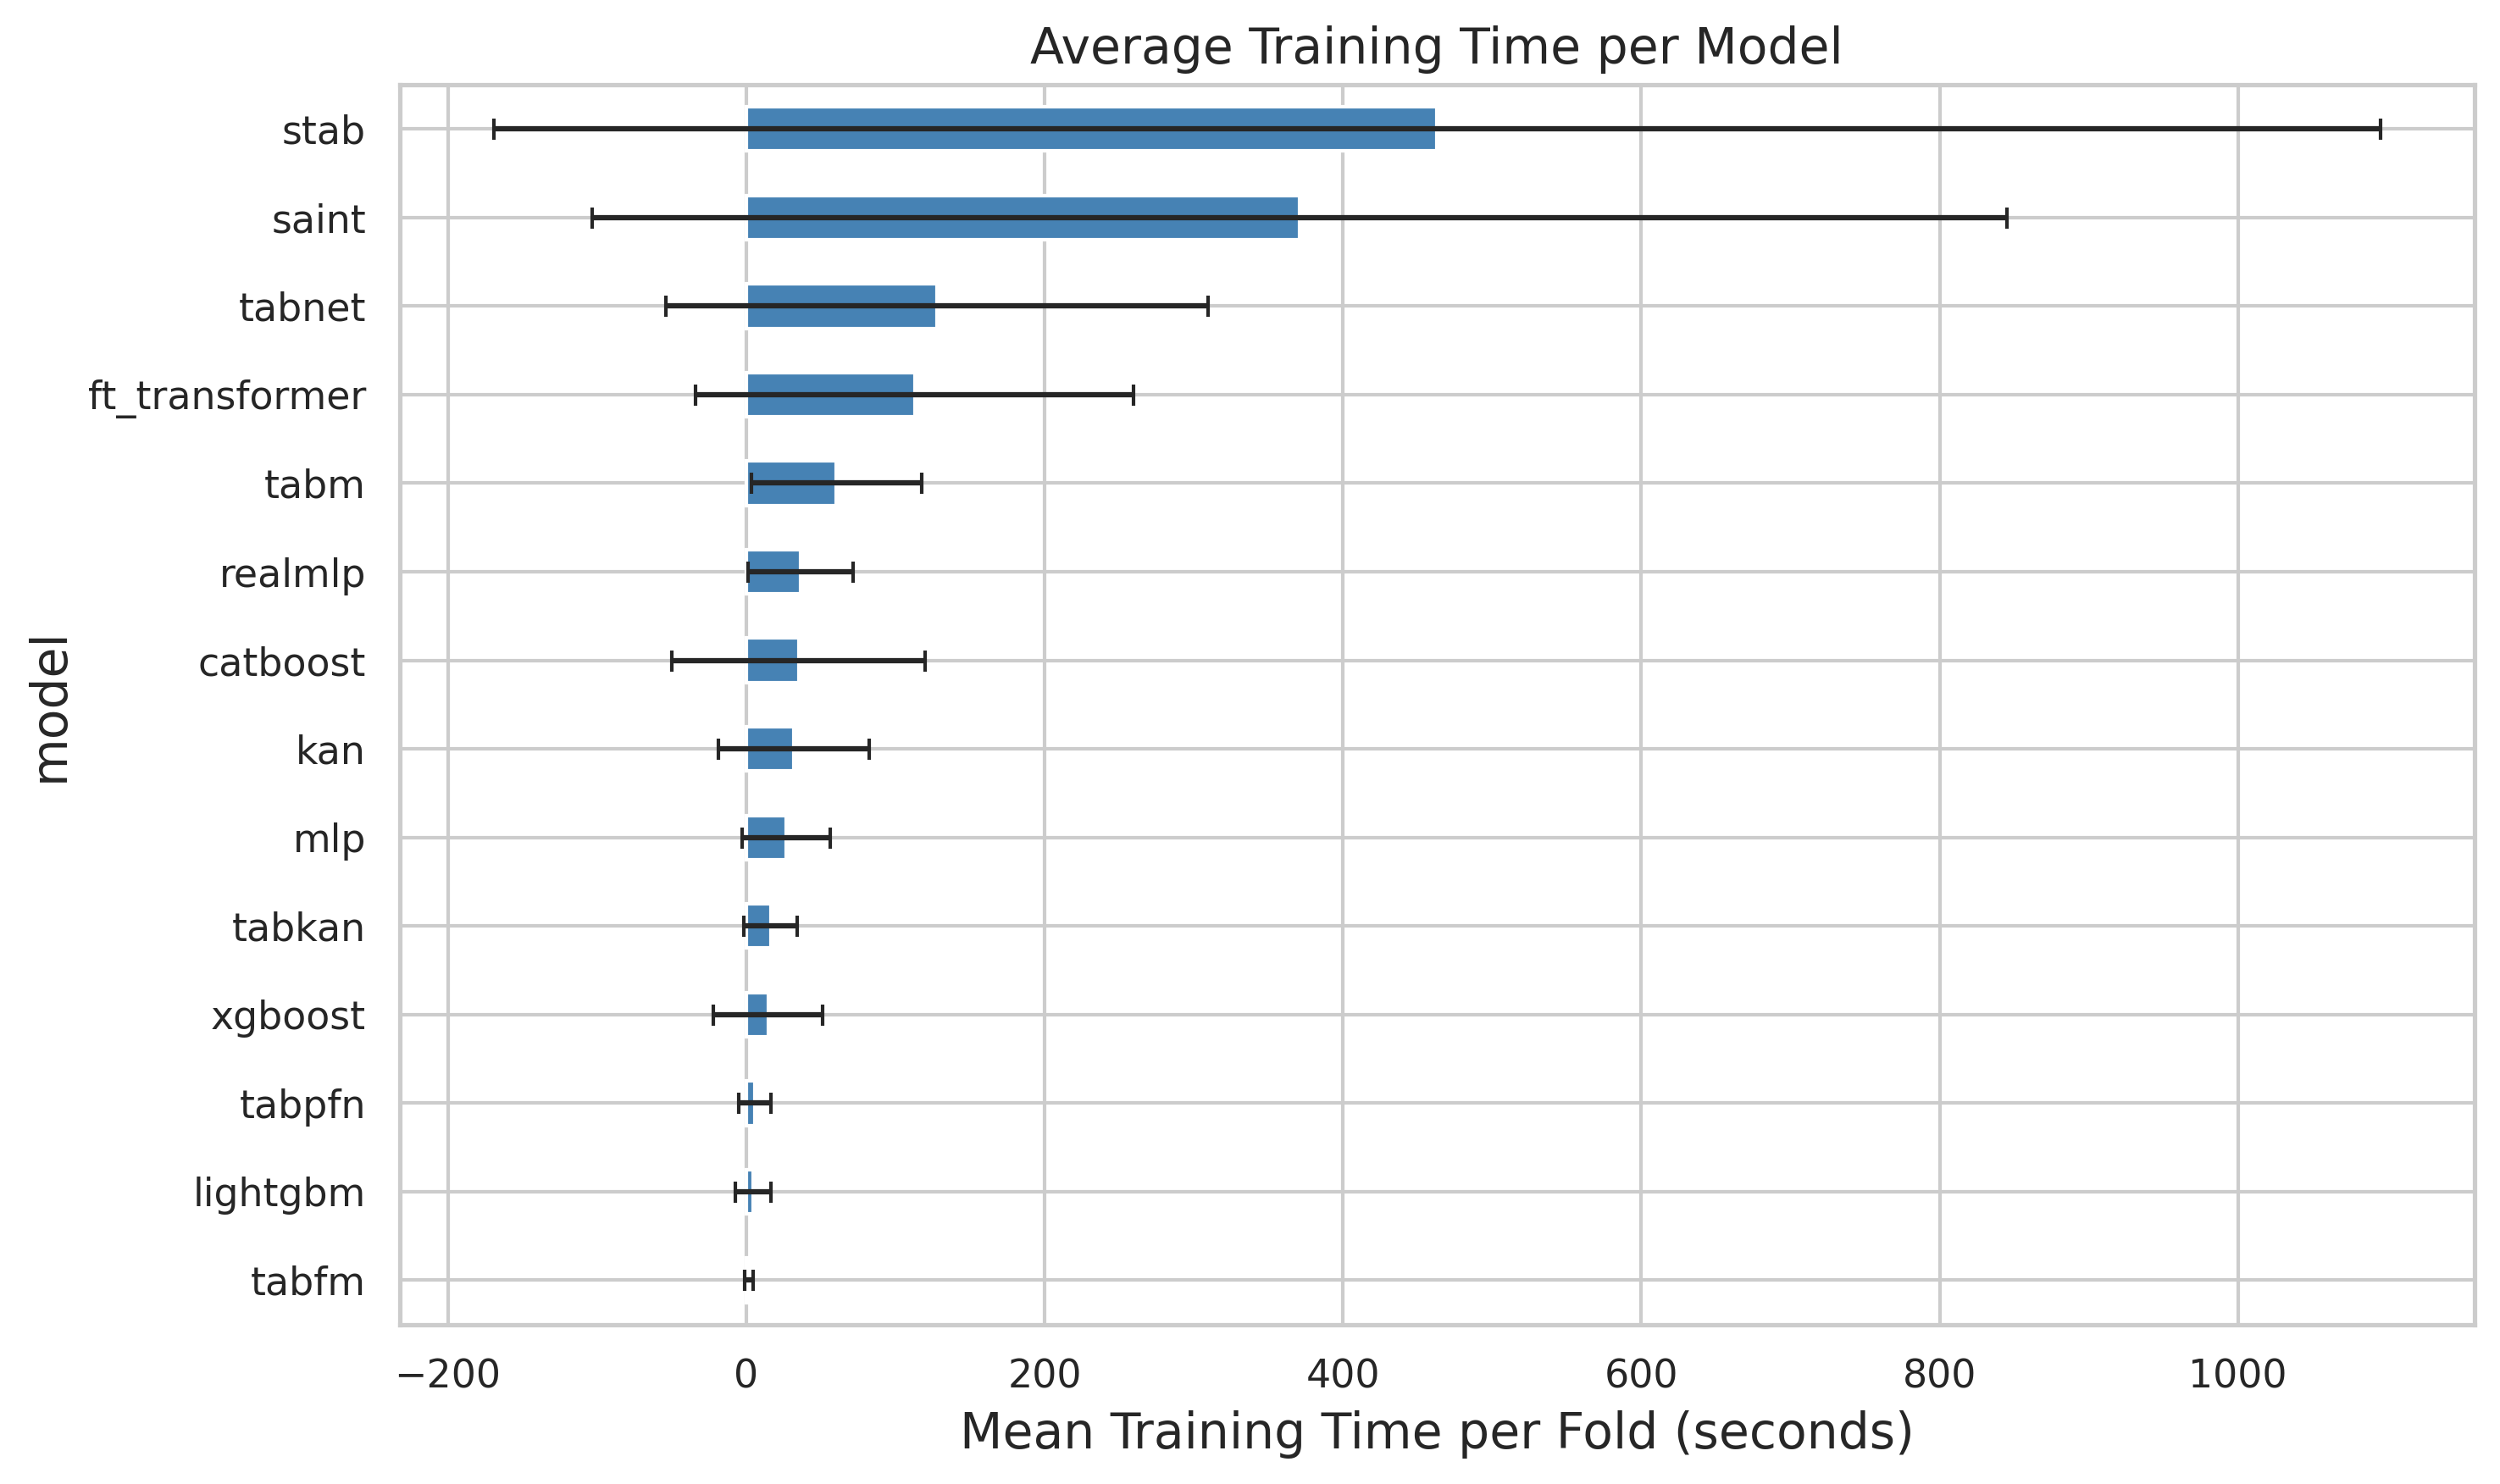

*Tempo de treino do modelo final (mediana). GBDTs e TabPFN: ~1-4s; DL pesado: minutos por fit.*

In [10]:
show('training_time.png', 'Tempo de treino do modelo final (mediana). GBDTs e TabPFN: ~1-4s; DL pesado: minutos por fit.', 720)

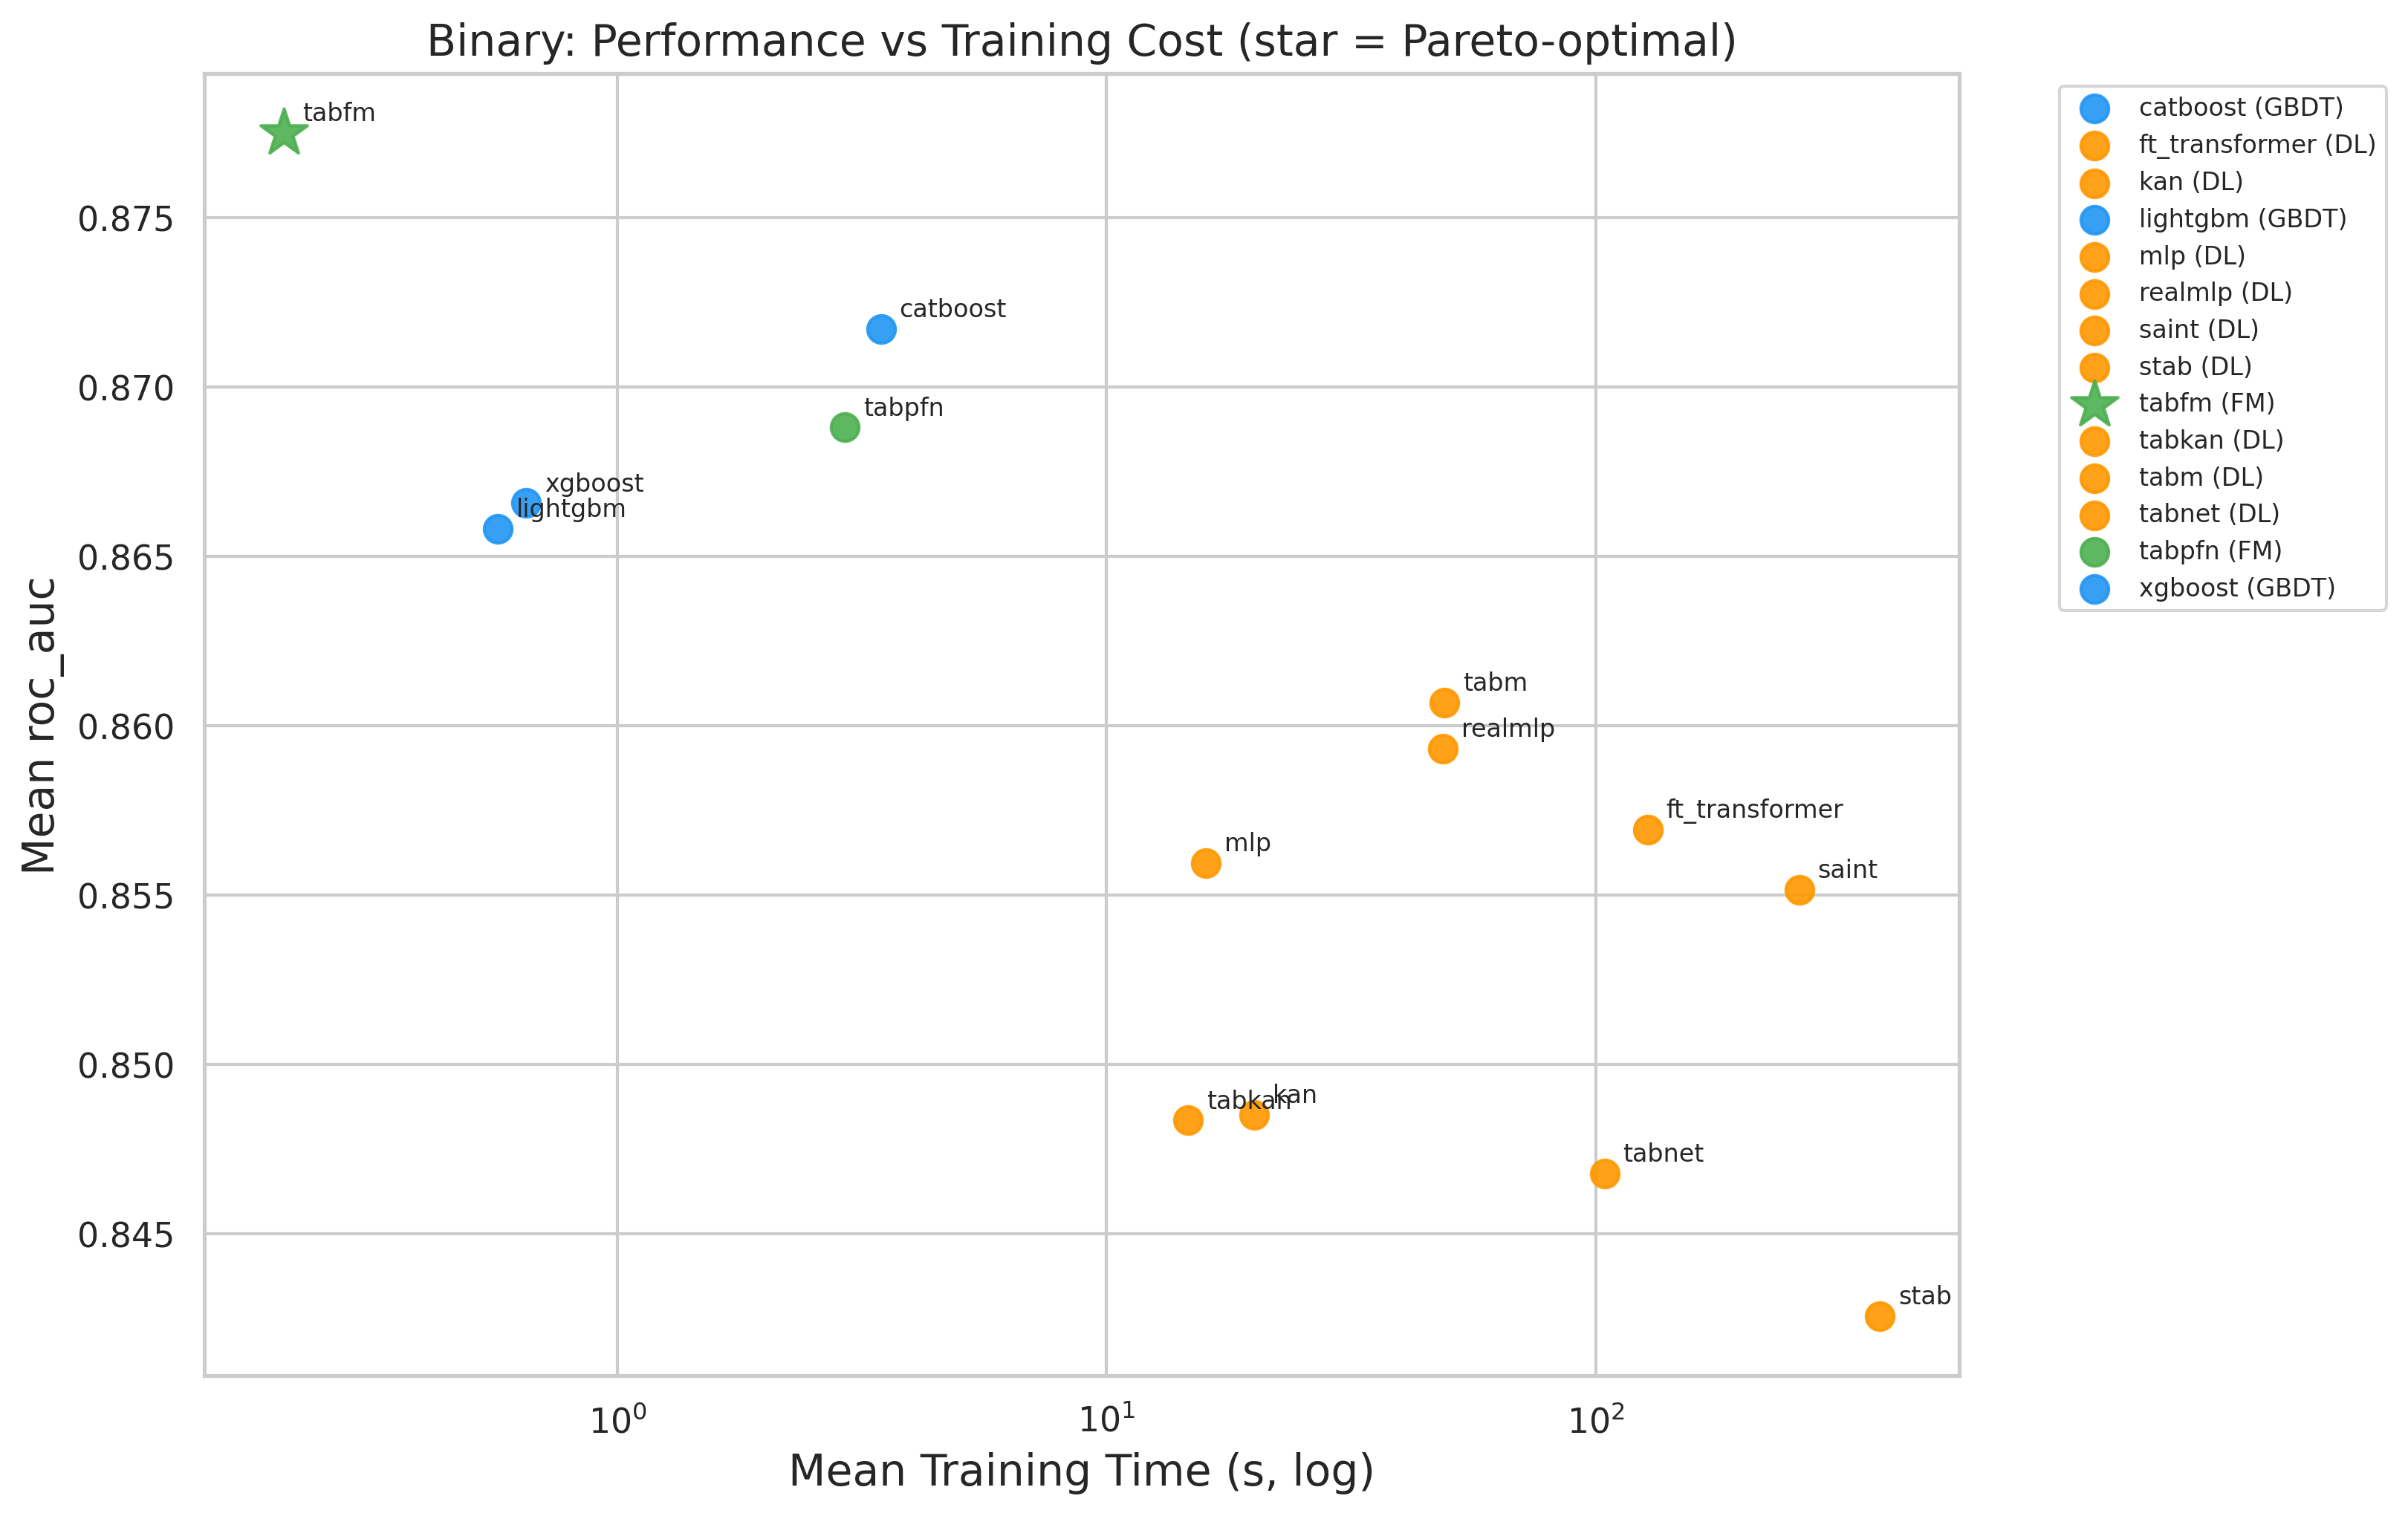

*Fronteira de Pareto custo×desempenho (binária): a fronteira e' {TabPFN, XGBoost, LightGBM} — todo DL e' dominado.*

In [11]:
show('pareto_binary.png', 'Fronteira de Pareto custo×desempenho (binária): a fronteira e\' {TabPFN, XGBoost, LightGBM} — todo DL e\' dominado.', 760)

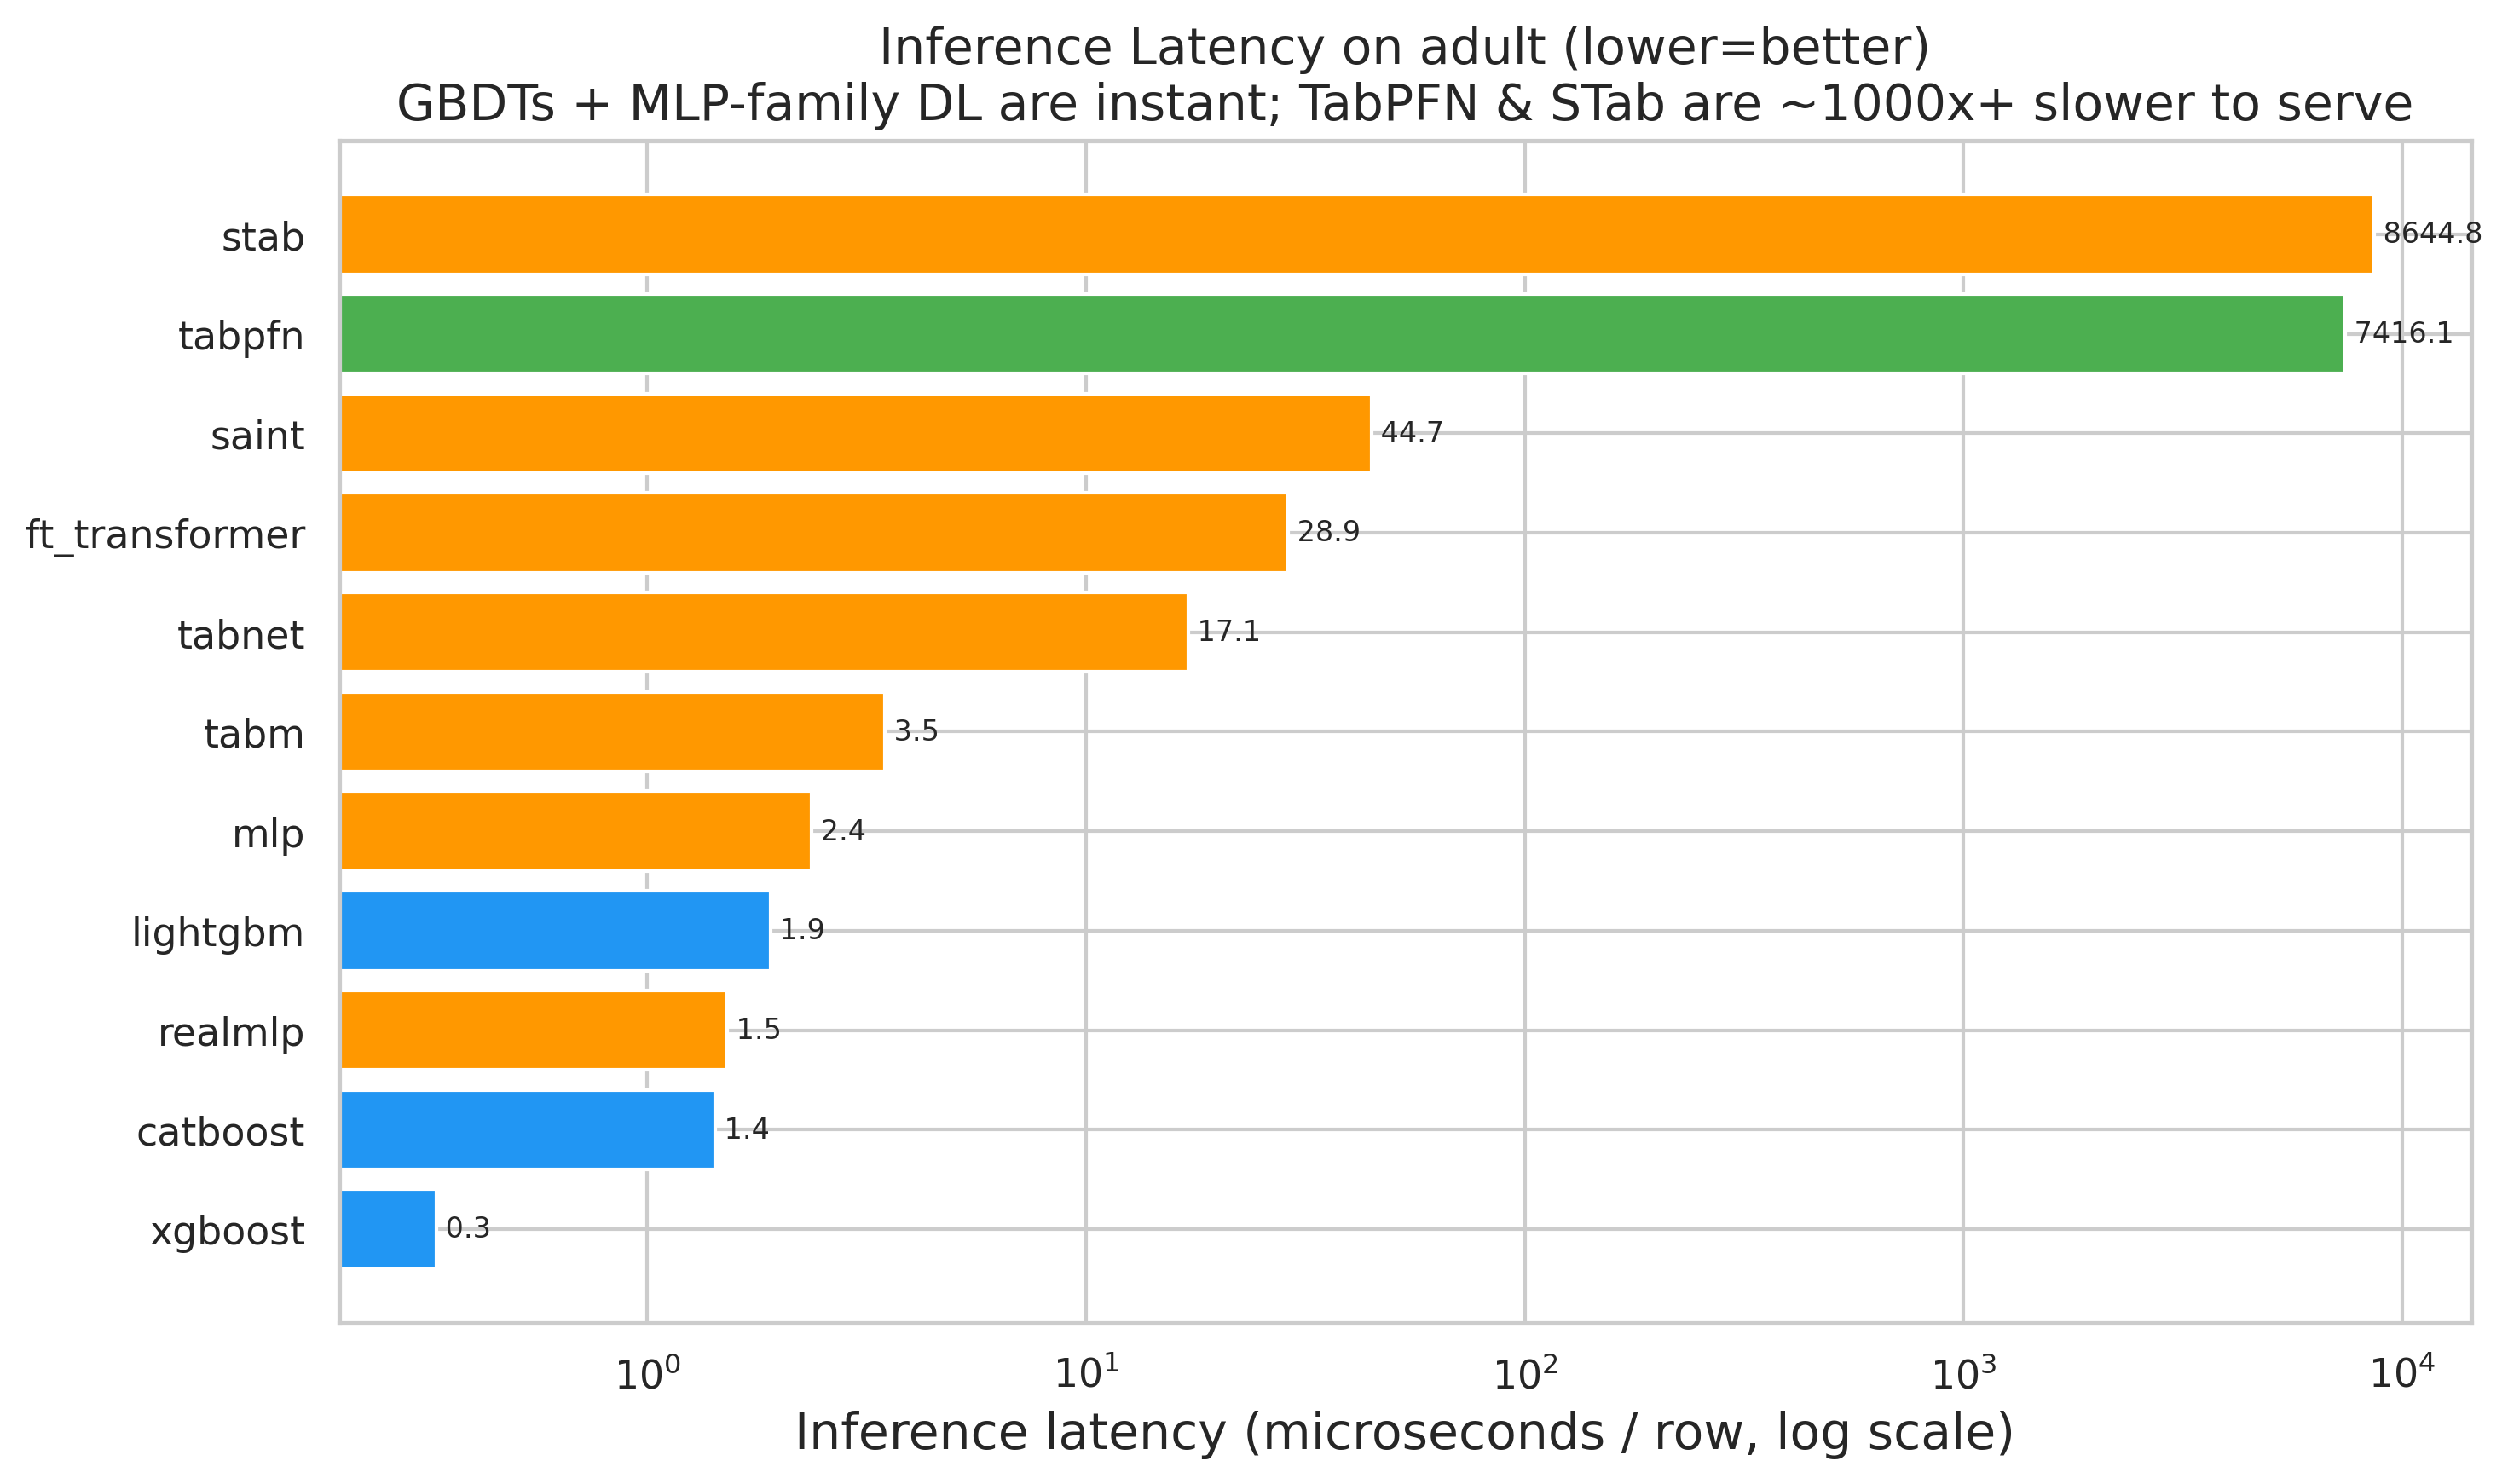

*Latencia de inferencia (adult). A INVERSAO do TabPFN: o mais barato de treinar e' o 2o mais caro de servir (~22.000x mais lento que XGBoost).*

In [12]:
show('inference_time.png', 'Latencia de inferencia (adult). A INVERSAO do TabPFN: o mais barato de treinar e\' o 2o mais caro de servir (~22.000x mais lento que XGBoost).', 760)

**Leitura do Ato II.** Custo é o primeiro eixo onde as famílias separam *limpo*. **A inversão do TabPFN**
é o achado-âncora: barato de treinar (~1s, zero tuning), caríssimo de servir. E latência **não** é um
corte "árvore vs rede" — é arquitetural: o *tier* rápido inclui os 3 GBDTs **e** os DL tipo-MLP
(RealMLP/MLP/TabM); só atenção, in-context (TabPFN) e *sampling* (STab) são lentos.

---
## 6. Ato III — As Reversões (o desempenho é condicional)

A melhor família **depende da estrutura do problema**: tarefa, tamanho, desbalanceamento e tipo de feature.

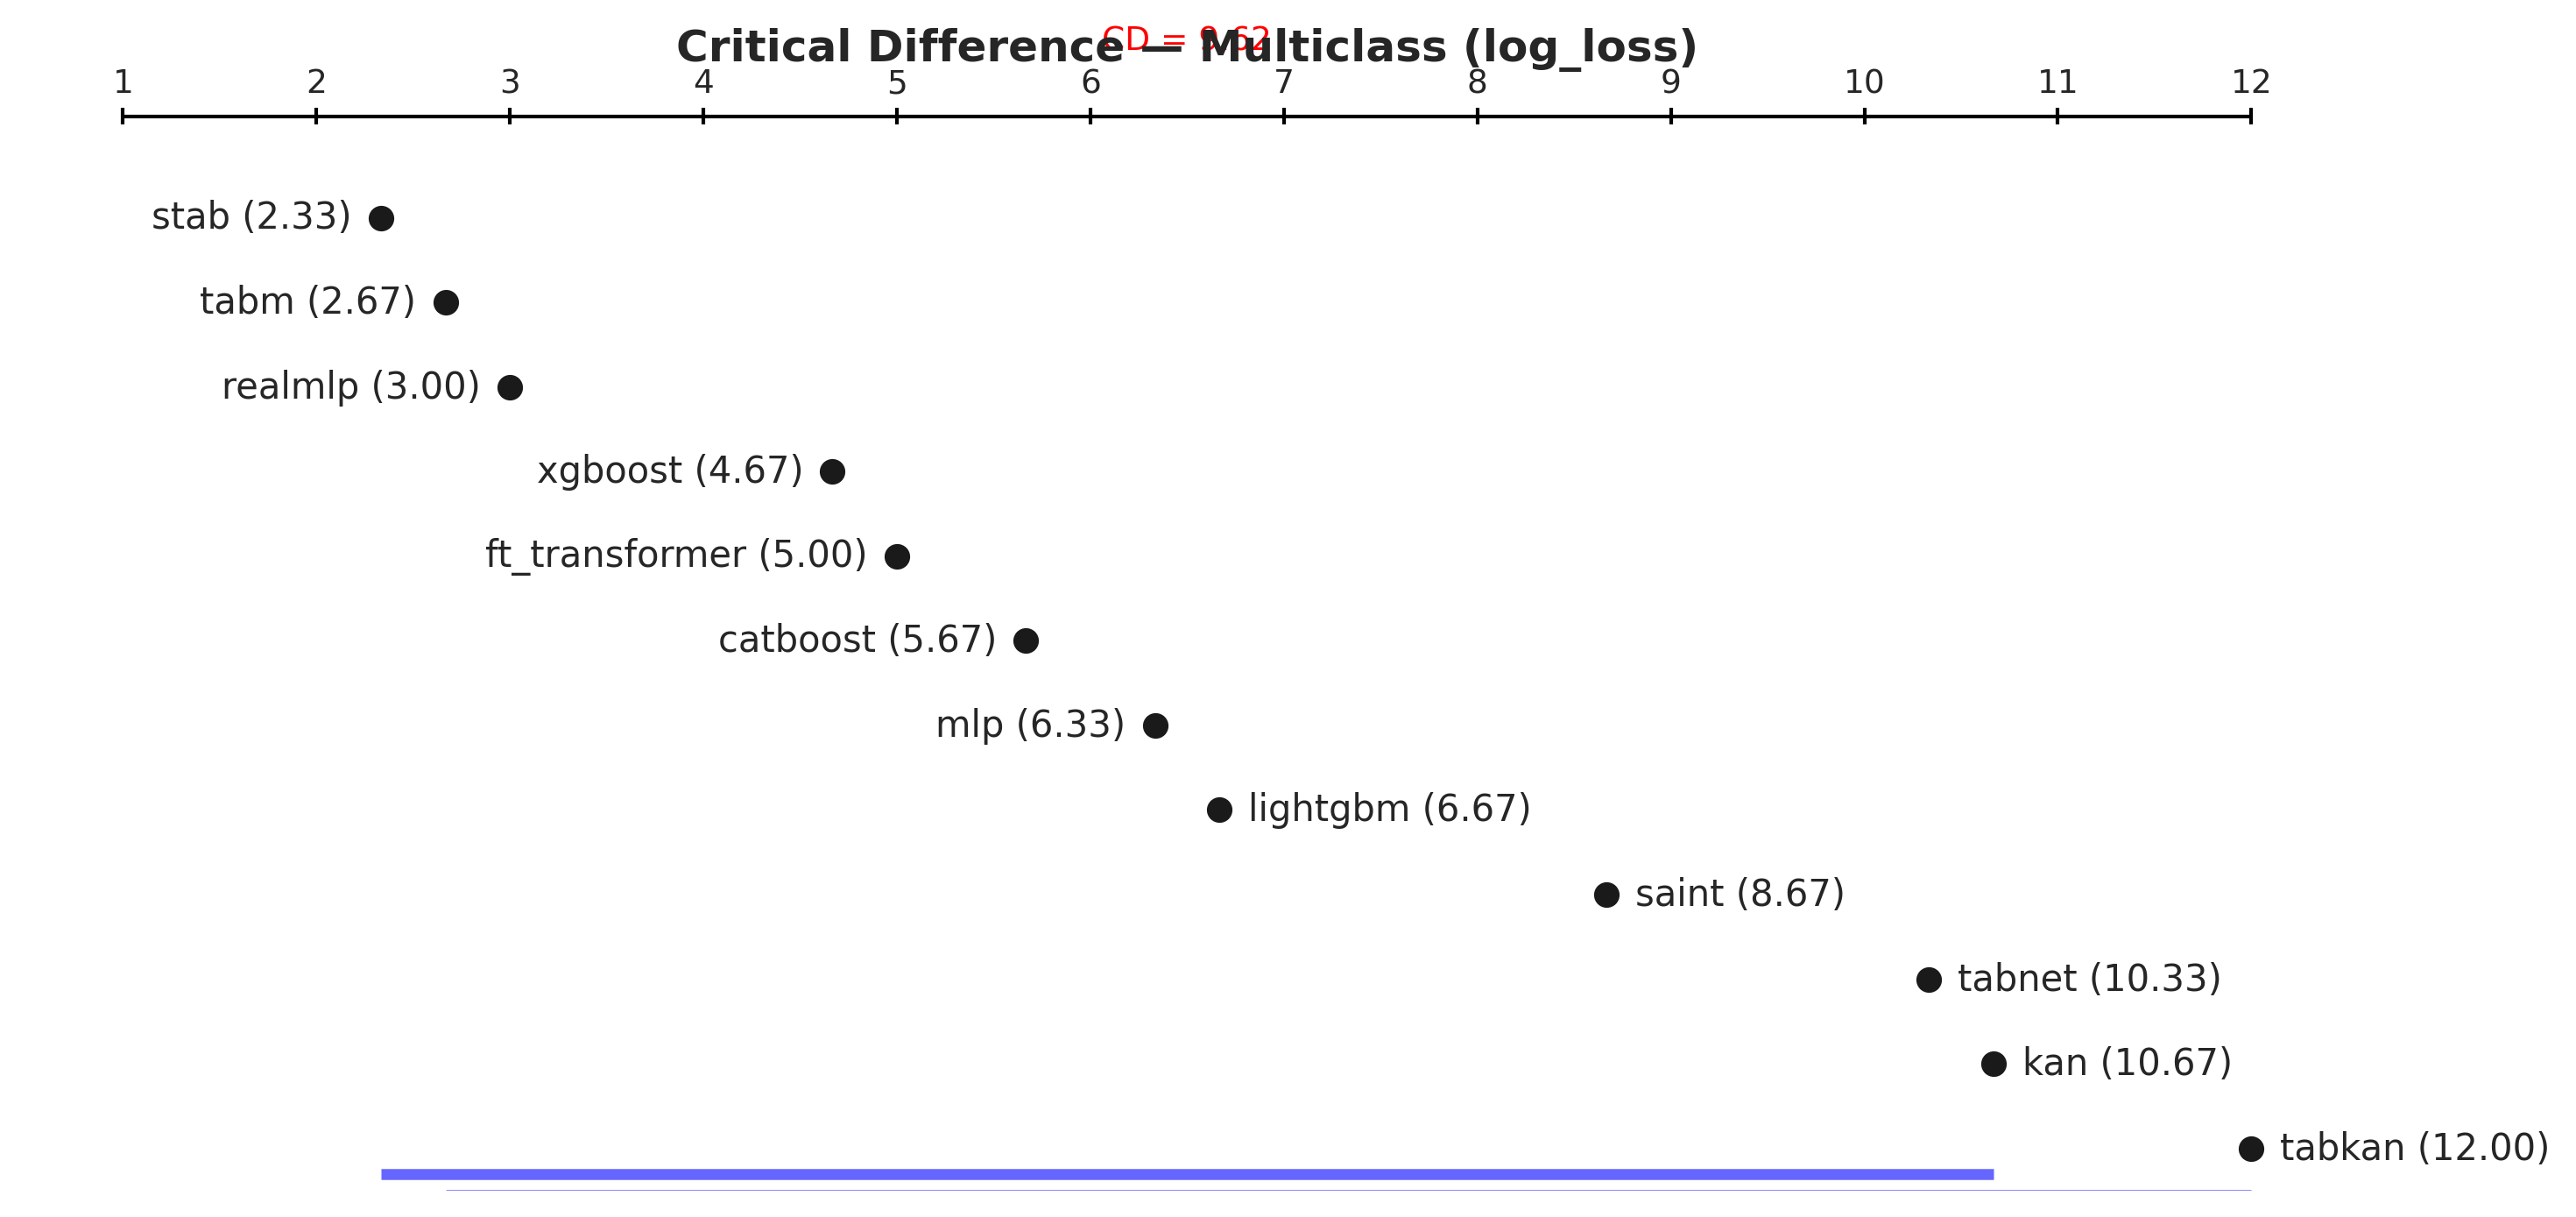

*CD multiclasse: STab/TabM/RealMLP (DL) topam — a reversao mais marcante do benchmark (descritivo, N=3).*

In [13]:
show('cd_diagram_multiclass.png', 'CD multiclasse: STab/TabM/RealMLP (DL) topam — a reversao mais marcante do benchmark (descritivo, N=3).', 720)

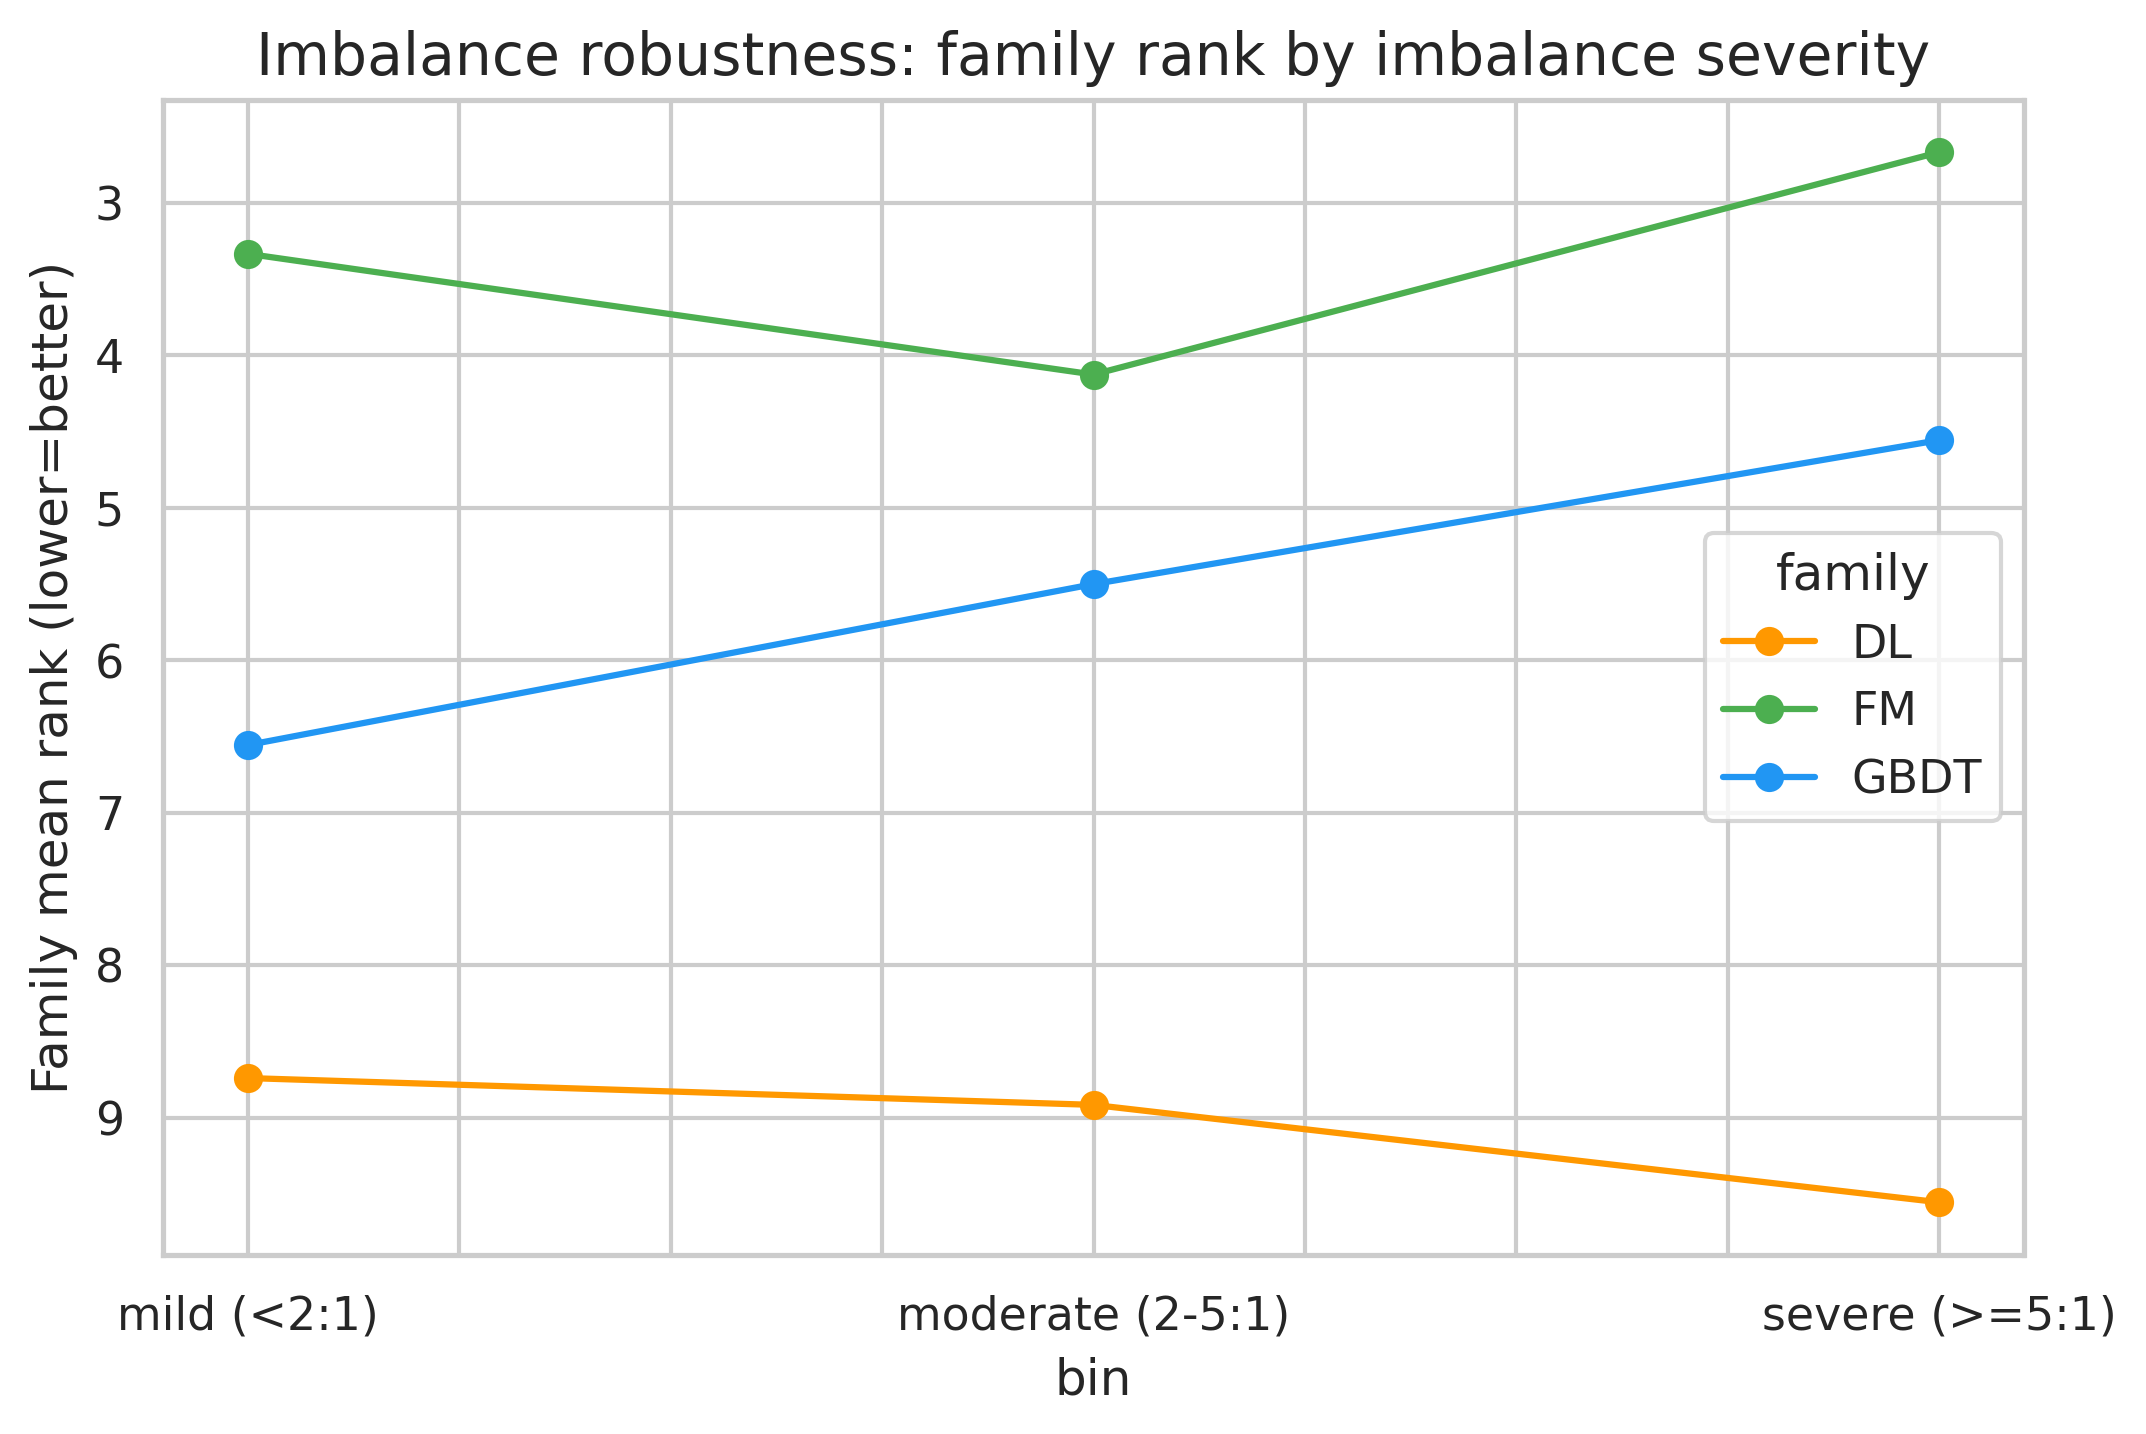

*Robustez ao desbalanceamento: GBDT melhora conforme a minoria fica rara; DL piora; TabPFN no meio.*

In [14]:
show('imbalance_robustness.png', 'Robustez ao desbalanceamento: GBDT melhora conforme a minoria fica rara; DL piora; TabPFN no meio.', 680)

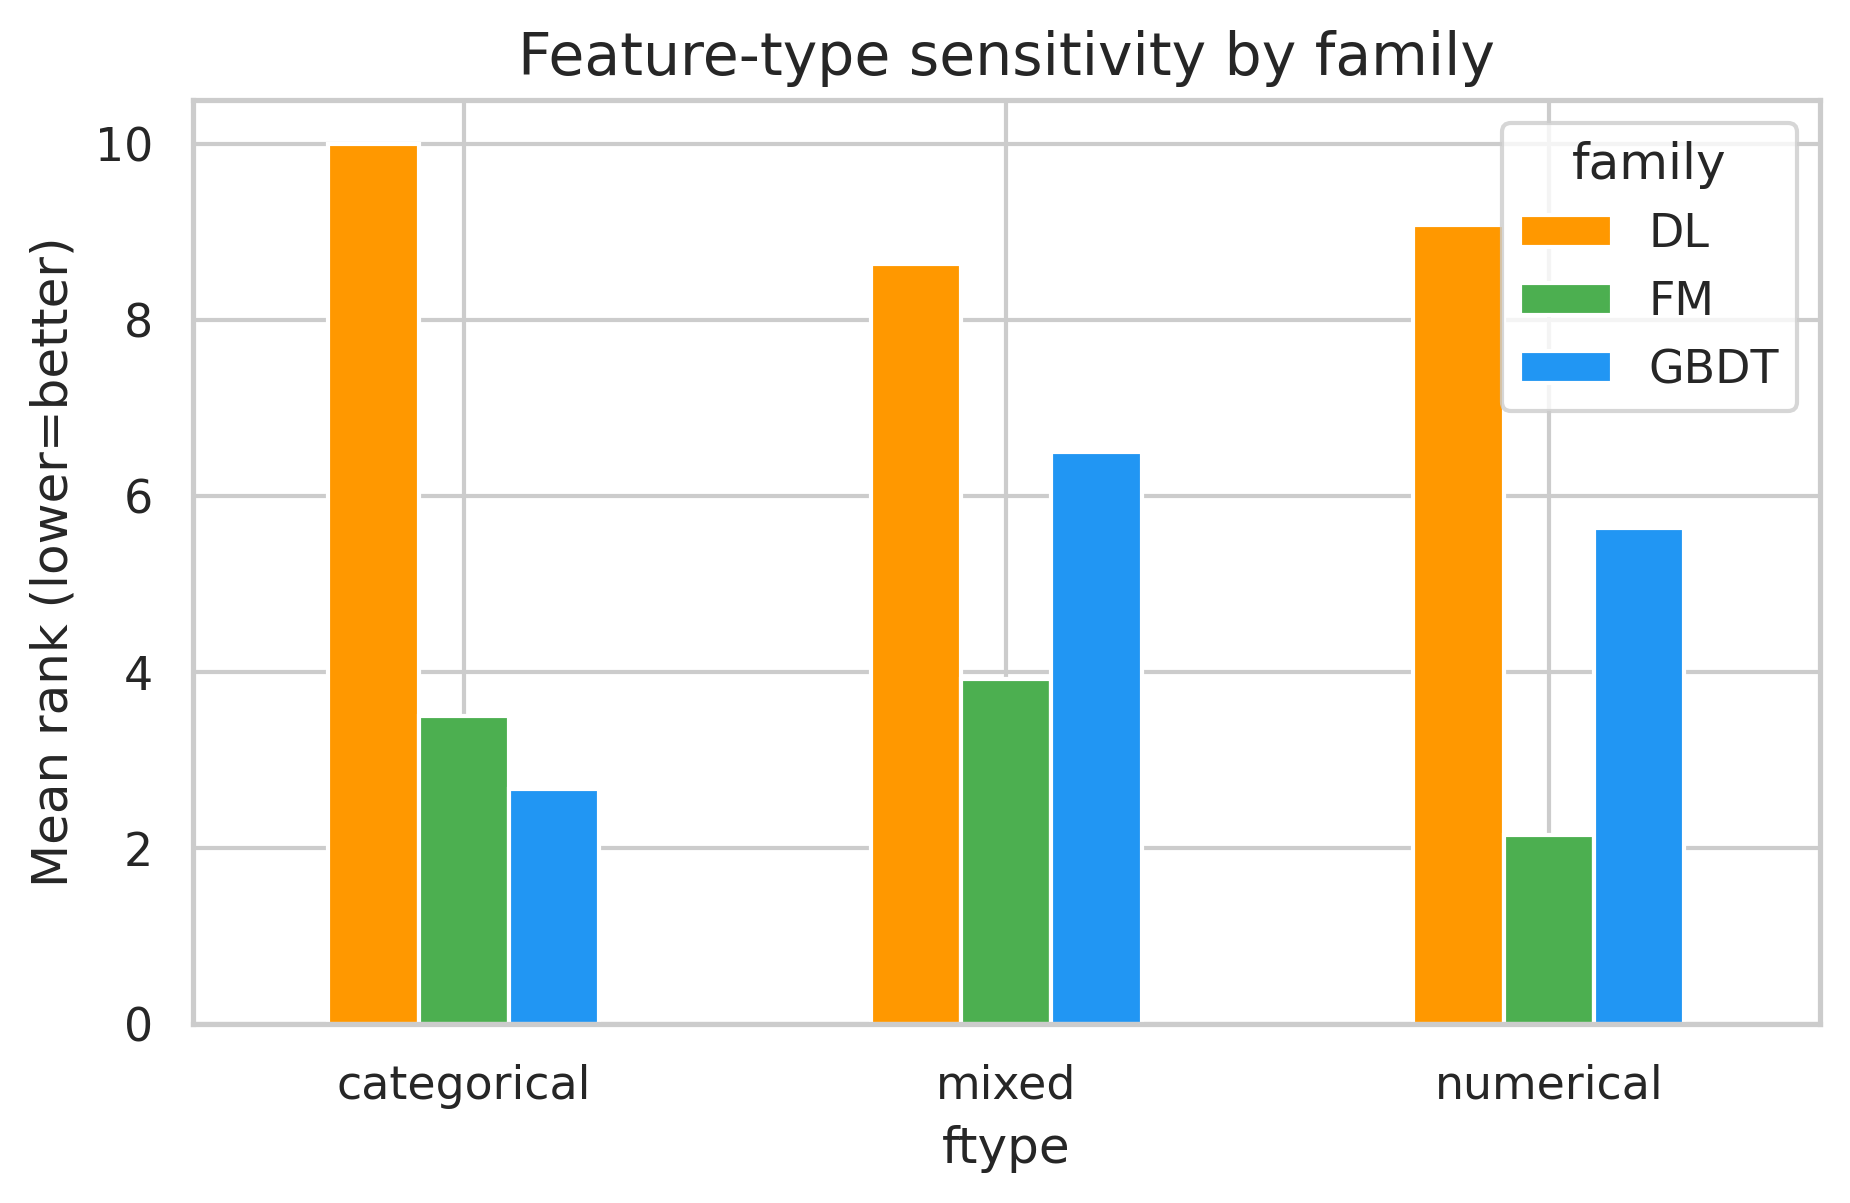

*Sensibilidade ao tipo de feature: o gargalo de one-hot do DL aparece no extremo categorico.*

In [15]:
show('feature_type_sensitivity.png', 'Sensibilidade ao tipo de feature: o gargalo de one-hot do DL aparece no extremo categorico.', 640)

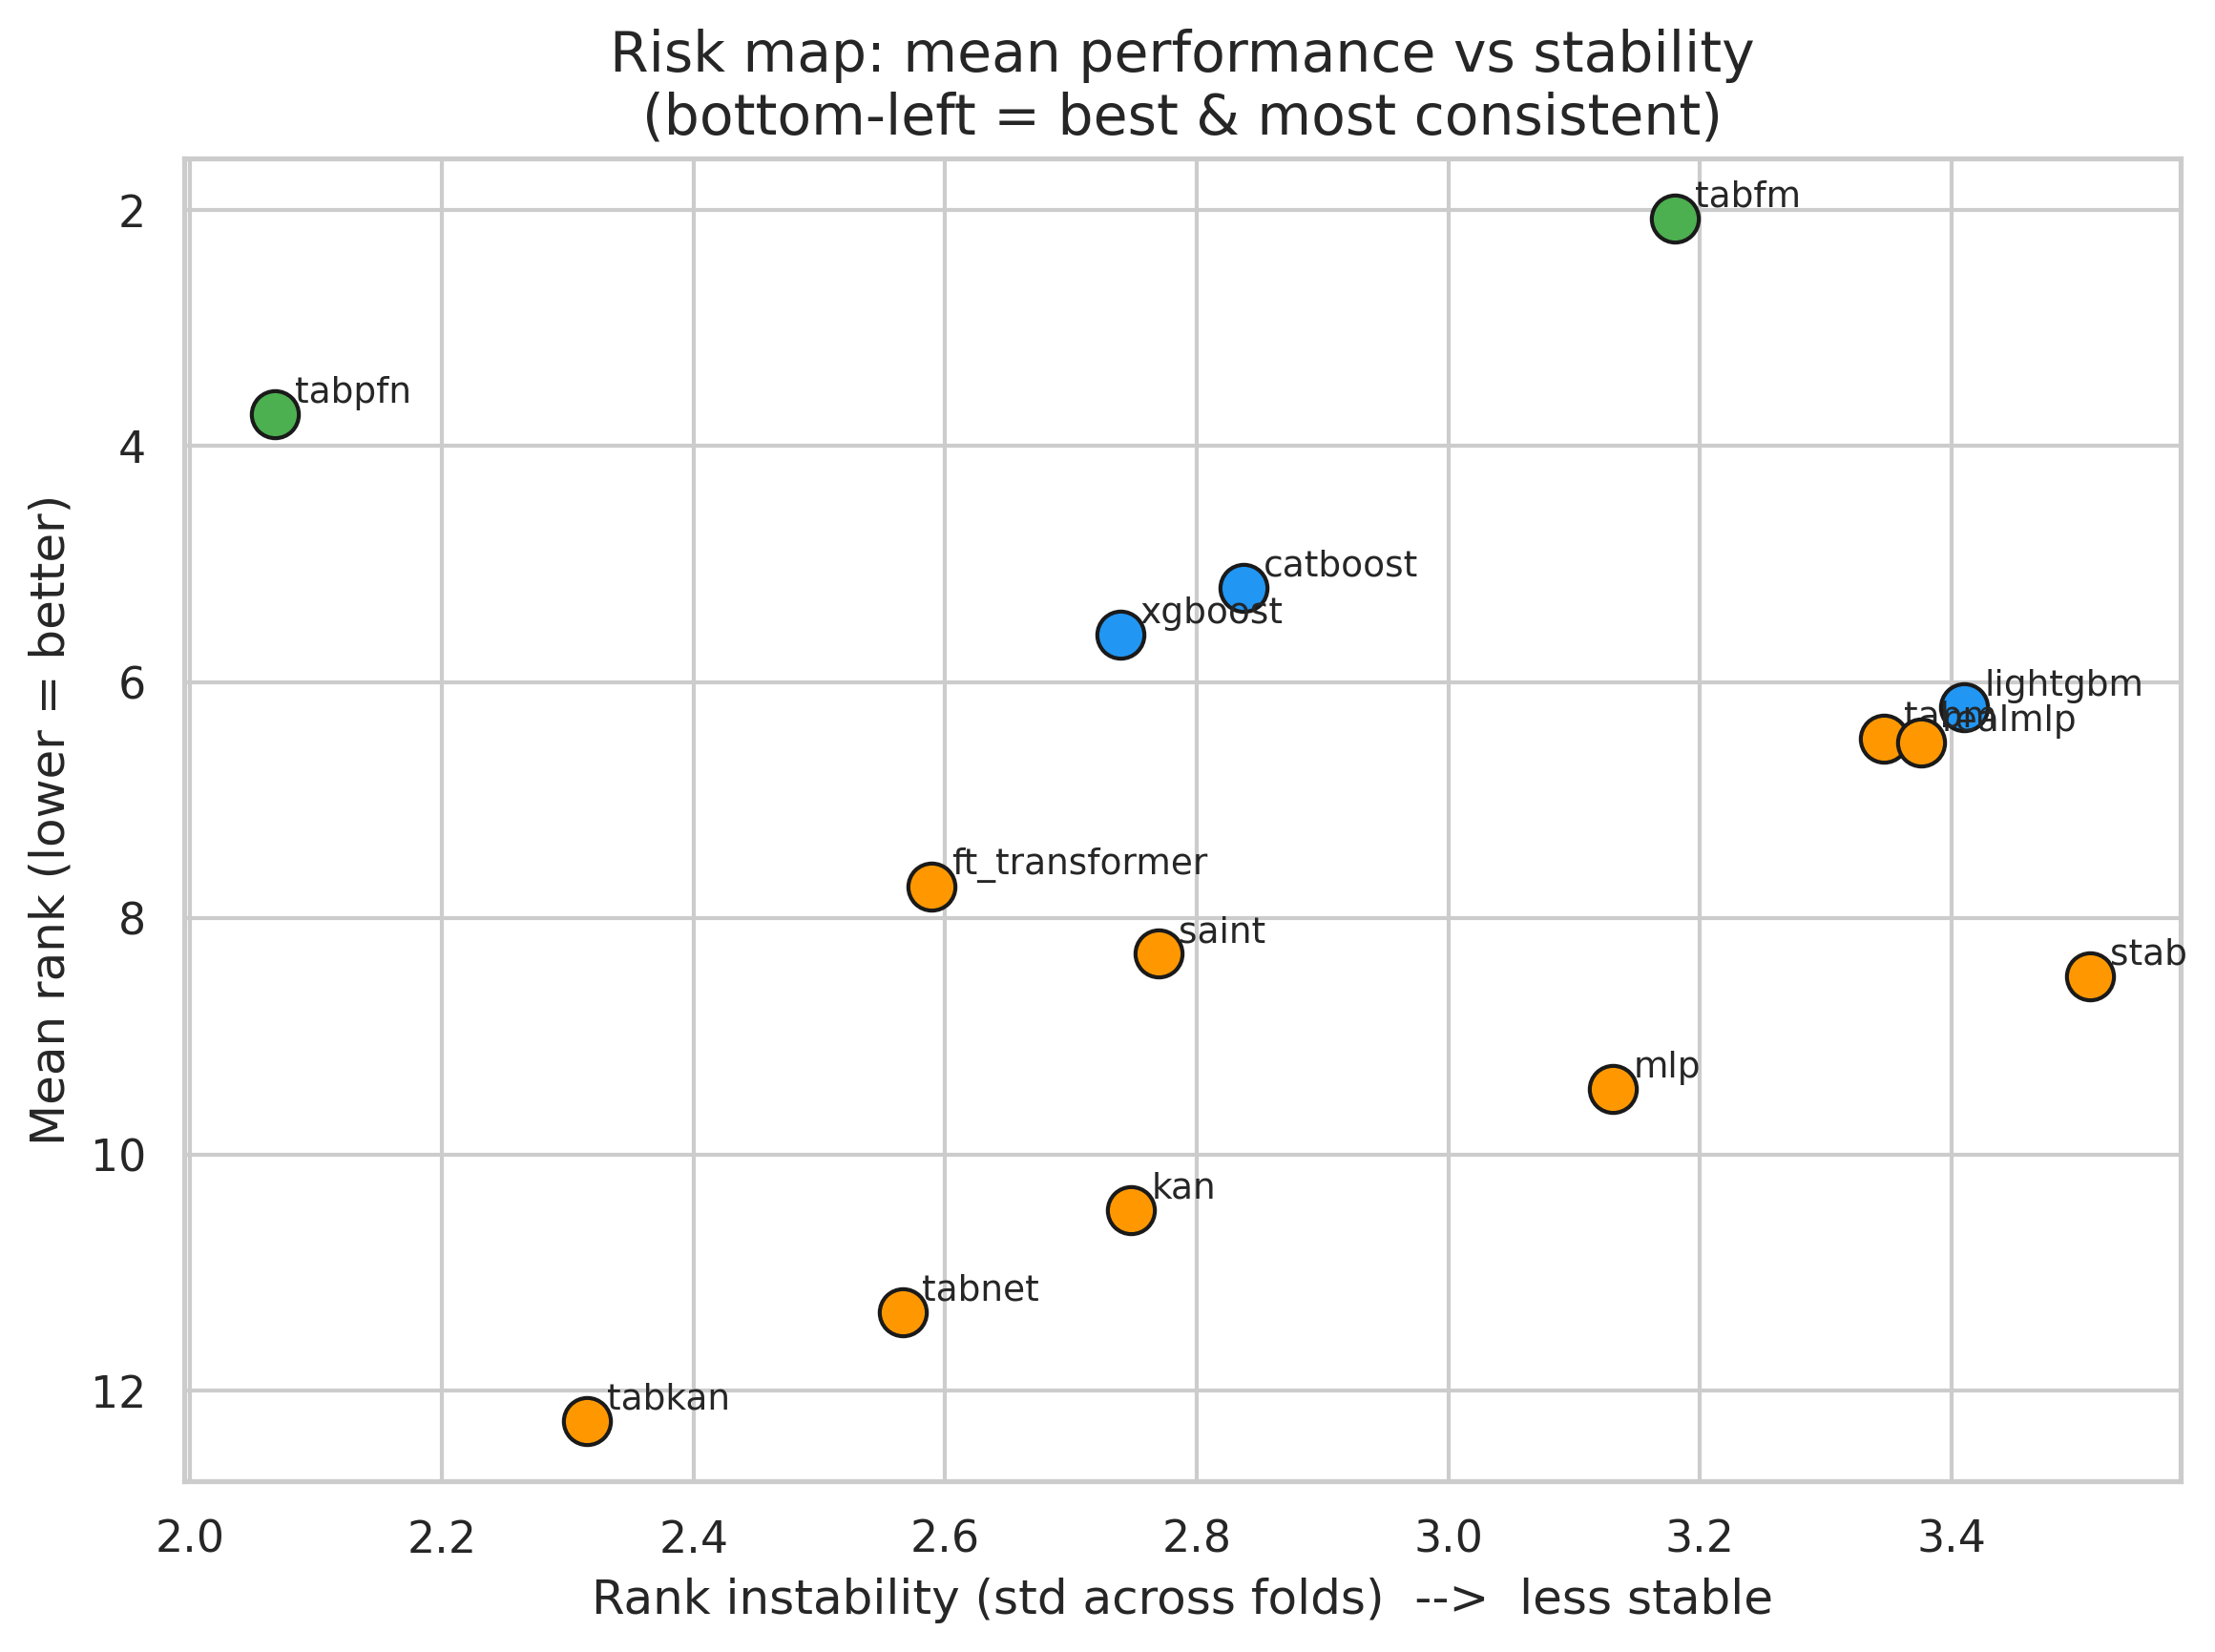

*Mapa de risco: TabPFN tem o melhor rank medio E o maior piso (raramente catastrofico); os demais caem a rank 10-11 em algum fold.*

In [16]:
show('robustness_riskmap.png', 'Mapa de risco: TabPFN tem o melhor rank medio E o maior piso (raramente catastrofico); os demais caem a rank 10-11 em algum fold.', 720)

**Leitura do Ato III.** GBDTs/TabPFN lideram binária e regressão, mas **DL reverte à frente em multiclasse**;
GBDTs ficam relativamente mais fortes sob desbalanceamento; atenção quebra em dados categóricos (one-hot).
E, em risco: **TabPFN raramente é catastrófico** — todo o resto tem um fold ruim.

### 6.1 Curvas de aprendizado — onde a liderança muda de mãos (RQ2)

O Ato III mostrou que o vencedor depende do *tipo* de tarefa. Mas a tensão original — *"GBDT vence"*
(Grinsztajn 2022) vs *"o DL moderno alcançou"* (TabM, RealMLP 2024) — é, no fundo, uma afirmação sobre
**tamanho de amostra**. Então varremos isso diretamente: re-treinando cada modelo em fatias crescentes do
pool (500 → pool completo), com os hiperparâmetros do Optuna **fixos** e o **mesmo** teste hold-out do
benchmark. **6 modelos × 5 datasets × 3 sementes.** A curva isola o efeito do *tamanho* a capacidade fixa.

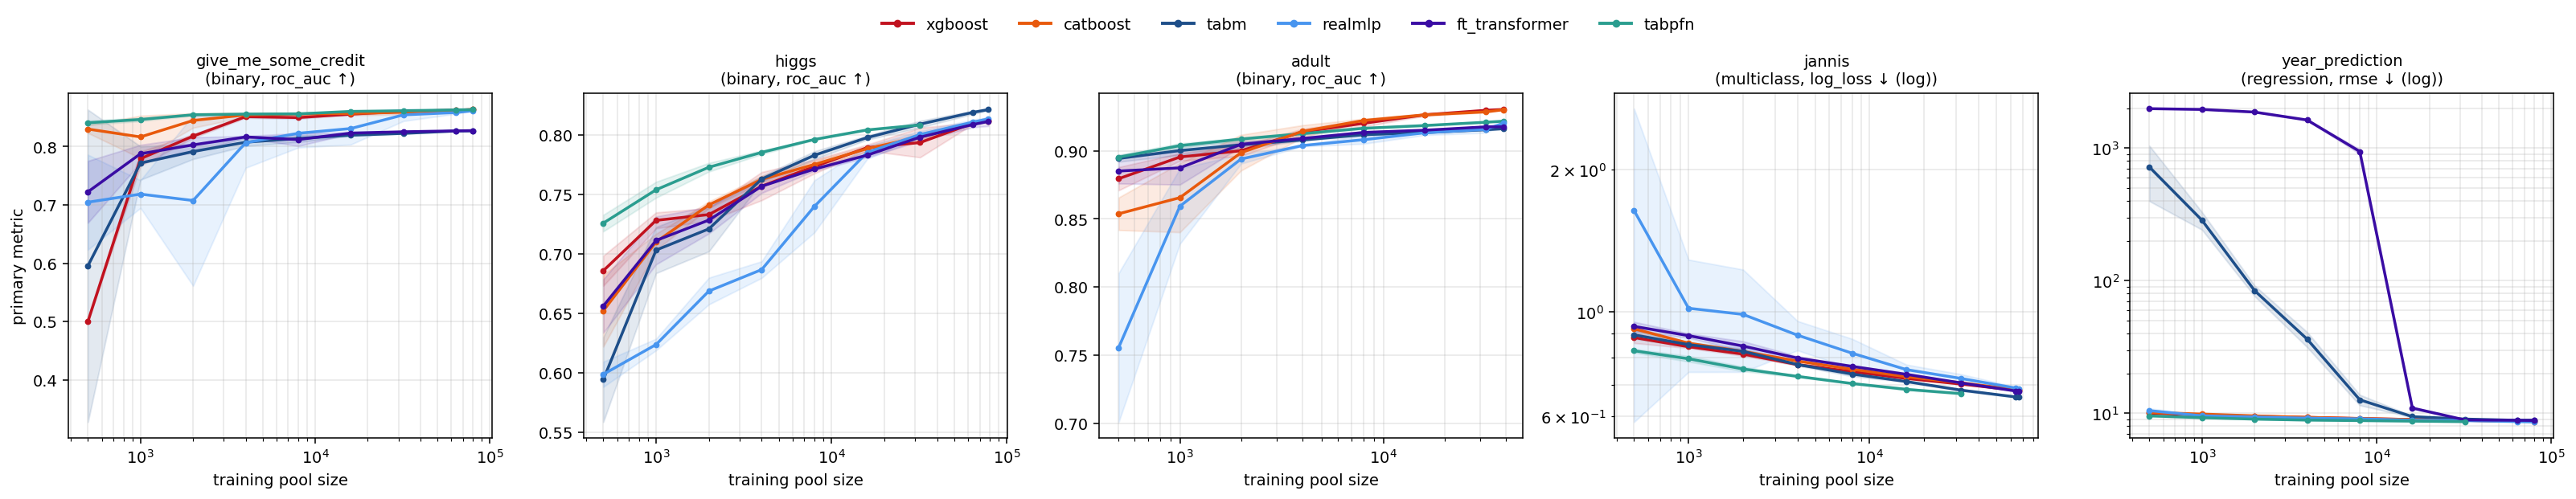

*Curvas de aprendizado (pool 500 → completo, 3 sementes). Binária em escala linear (AUC ↑); multiclasse/regressão em log-y (log-loss / RMSE ↓). O DL/foundation alcança e, em 3/5 datasets, ultrapassa os GBDTs.*

In [17]:
show('learning_curves.png', 'Curvas de aprendizado (pool 500 → completo, 3 sementes). Binária em escala linear (AUC ↑); '
     'multiclasse/regressão em log-y (log-loss / RMSE ↓). O DL/foundation alcança e, em 3/5 datasets, ultrapassa os GBDTs.', 1000)

In [18]:
# Numeros-chave da RQ2, calculados aqui (visiveis) a partir de results/learning_curve/curve.csv
lc = pd.read_csv('../results/learning_curve/curve.csv')
PRIM = {'binary': ('roc_auc', True), 'multiclass': ('log_loss', False), 'regression': ('rmse', False)}
lc['primary'] = lc.apply(lambda r: r[PRIM[r.task_type][0]], axis=1)

def _env(a, fam, higher):  # melhor modelo da familia em cada tamanho (envelope)
    f = a[a.family == fam].groupby('train_size')['primary']
    return f.max() if higher else f.min()

rows = []
for ds in ['give_me_some_credit', 'higgs', 'adult', 'jannis', 'year_prediction']:
    sub = lc[lc.dataset == ds]; task = sub.task_type.iloc[0]; higher = PRIM[task][1]
    a = sub.groupby(['model', 'family', 'train_size'])['primary'].mean().reset_index()
    gb, dl = _env(a, 'gbdt', higher), _env(a, 'deep_learning', higher)
    sizes = sorted(set(gb.index) & set(dl.index)); gb, dl = gb.reindex(sizes), dl.reindex(sizes)
    lead = (gb - dl) if higher else (dl - gb)   # > 0  =>  GBDT melhor
    cross = next((s for i, s in enumerate(sizes)
                  if lead.iloc[i] > 0 and (lead.iloc[i:] > 0).all()), None)
    rows.append({'dataset': ds, 'tarefa': task,
                 'vence pequeno': 'GBDT' if lead.iloc[0] > 0 else 'DL',
                 'vence grande': 'GBDT' if lead.iloc[-1] > 0 else 'DL',
                 'GBDT reassume em n≈': cross if cross is not None else 'nunca (DL à frente)'})
print('Crossover por dataset (envelope best-of-familia):')
display(pd.DataFrame(rows))

# Rank medio no regime de poucos dados (n <= 4000) — a casa do TabPFN
sm = lc[lc.train_size <= 4000]
piv = (sm.groupby(['dataset', 'model'])['primary'].mean()
       .reset_index().pivot(index='dataset', columns='model', values='primary'))
rk = piv.copy()
for ds in rk.index:
    rk.loc[ds] = piv.loc[ds].rank(ascending=not PRIM[lc[lc.dataset == ds].task_type.iloc[0]][1])
print('\nRank medio em n <= 4000 (1 = melhor):')
display(rk.mean().sort_values().round(2).to_frame('rank_medio'))

Crossover por dataset (envelope best-of-familia):


,dataset,tarefa,vence pequeno,vence grande,GBDT reassume em n≈
0,give_me_some_credit,binary,GBDT,GBDT,500
1,higgs,binary,GBDT,DL,nunca (DL à frente)
2,adult,binary,DL,GBDT,4000
3,jannis,multiclass,GBDT,DL,nunca (DL à frente)
4,year_prediction,regression,GBDT,DL,nunca (DL à frente)



Rank medio em n <= 4000 (1 = melhor):


,rank_medio
model,
tabpfn,1.0
xgboost,2.8
catboost,3.6
tabm,3.8
ft_transformer,4.4
realmlp,5.4


**Leitura da §6.1 (RQ2).** O empate do Ato I era **condicional ao tamanho** o tempo todo. Em **3 de 5**
datasets (higgs, jannis, year_prediction) o DL ultrapassa os GBDTs conforme o pool cresce e **não devolve
a liderança**; `adult` mostra o inverso (DL cedo, GBDT reassume em n≈4000); só `give_me_some_credit` fica
GBDT o tempo todo. E o **TabPFN é o especialista de poucos dados, quantificado**: rank médio **1.0** (o
melhor) em *todos* os datasets no regime n ≤ 4000 — casando com o custo do Ato II (barato de treinar, caro
de servir): barato *e* melhor exatamente onde há pouco dado.

*Caveat: hiperparâmetros fixos do pool completo (reaproveitados do Optuna); um re-tune por tamanho mudaria
os níveis absolutos, não a **direção** do crossover.*

### 6.2 A quebra do empate — a geração 2026 (14 modelos)

O benchmark foi expandido com três modelos: **KAN** e **TabKAN** (a família Kolmogorov-Arnold, sem
teste neutro prévio na literatura) e **TabFM** (o foundation model do Google, lançado em jun/2026 —
segunda implementação independente do paradigma PFN/ICL, ao lado do TabPFN). Protocolo idêntico,
mesmos splits. O resultado reorganiza a narrativa: **o empate do Ato I era um retrato da geração
até 2025** — e a geração 2026 o quebra.

In [19]:
# §6.2 — numeros-chave da geracao 2026, calculados aqui (14 modelos)
test14 = pd.read_csv('../results/aggregated/test_results.csv')
PRIM14 = {'binary': ('roc_auc', True), 'multiclass': ('log_loss', False), 'regression': ('rmse', False)}

print('Rank medio por tarefa (1 = melhor), 14 modelos:')
rank_tbl = {}
for task, (col, higher) in PRIM14.items():
    piv14 = test14[test14.task_type==task].pivot(index='dataset', columns='model', values=col)
    rank_tbl[task] = piv14.rank(axis=1, ascending=not higher).mean()
display(pd.DataFrame(rank_tbl).round(2).sort_values('binary'))

wins, total = 0, 0
for ds in test14.dataset.unique():
    sub = test14[test14.dataset==ds]; task = sub.task_type.iloc[0]
    col, higher = PRIM14[task]
    s = sub.dropna(subset=[col])
    best = s.loc[s[col].idxmax() if higher else s[col].idxmin(), 'model']
    total += 1; wins += (best == 'tabfm')
print(f'TabFM e o #1 absoluto em {wins}/{total} datasets (participa de 17/18; helena excluido por limite de 10 classes).')

lodo = pd.read_csv('../results/aggregated/lodo_validation_14.csv')
cols = ['regret_lodo', 'regret_GBDT', 'regret_DL', 'regret_FM']
print('\nValidacao LODO do framework (regret normalizado; 0 = escolheu o melhor):')
display(pd.DataFrame({'medio': lodo[cols].mean(), 'mediano': lodo[cols].median()}).round(3))
print('A politica "FM primeiro" domina; rotear por meta-features nao supera politicas triviais.')

Rank medio por tarefa (1 = melhor), 14 modelos:


,binary,multiclass,regression
model,,,
tabfm,2.7,1.00,1.2
tabpfn,4.2,2.50,3.0
xgboost,5.0,6.00,5.0
catboost,5.3,7.00,5.8
lightgbm,6.3,8.00,5.6
tabm,6.6,3.67,8.4
ft_transformer,7.4,6.33,8.8
saint,7.5,10.00,8.4
realmlp,7.7,4.33,5.2


TabFM e o #1 absoluto em 13/18 datasets (participa de 17/18; helena excluido por limite de 10 classes).

Validacao LODO do framework (regret normalizado; 0 = escolheu o melhor):


,medio,mediano
regret_lodo,0.051,0.000
regret_GBDT,0.305,0.291
regret_DL,0.313,0.349
regret_FM,0.021,0.000


A politica "FM primeiro" domina; rotear por meta-features nao supera politicas triviais.


**Leitura da §6.2 — três achados, um arco.**
**(1) O empate foi quebrado — mas não por quem se esperava.** Não foi o DL tunado que alcançou os GBDTs:
foi o *foundation model* pré-treinado, zero-shot, com fit de segundos. E o custo é o contrapeso: ~100
ms/linha de inferência (~300.000× o XGBoost) — **o melhor modelo em acurácia é o pior em latência**, a
inversão do Ato II elevada ao extremo. A decisão multicritério deixou de ser "qual família?" e virou
**"a latência do FM cabe no meu caso de uso?"**.
**(2) As KANs falharam no teste independente.** Meio de tabela na binária, fundo nas três tarefas —
abaixo até do TabNet em multiclasse/regressão. Nosso benchmark é, até onde verificamos, o primeiro teste
neutro da família KAN sob protocolo uniforme; o resultado contradiz as alegações do paper do TabKAN
(XGBoost sub-tunado como baseline é a explicação provável) e confirma a literatura cética (Yu et al.
2024). *Resultado negativo com valor: economiza o hype.*
**(3) O framework sobrevive à validação.** Sob LODO, rotear por meta-features não supera políticas
triviais — mas a política **"FM primeiro, desvie por restrição"** tem regret mediano ≈0. O flowchart do
Ato IV (que já era orientado a restrições: latência? tamanho? categorias?) sai *validado*: as perguntas
certas eram as restrições, não a adivinhação do vencedor.

---
## 7. Ponte Ato III → IV — dá para *prever* o vencedor?

As reversões não são aleatórias: elas seguem **meta-features** do dataset (tamanho, dimensionalidade,
fração categórica). Uma árvore pequena e interpretável recupera quem vence — e seus *splits* viram as
ramificações do flowchart. **Validação (LODO, §6.2): como preditor, a árvore NÃO generaliza** (hit-rate
abaixo do baseline trivial) — ela é mantida como **ilustração descritiva da estrutura**, e o flowchart
se apoia nas *restrições* (latência, tamanho, categorias), que a validação por regret confirma como as
perguntas certas.

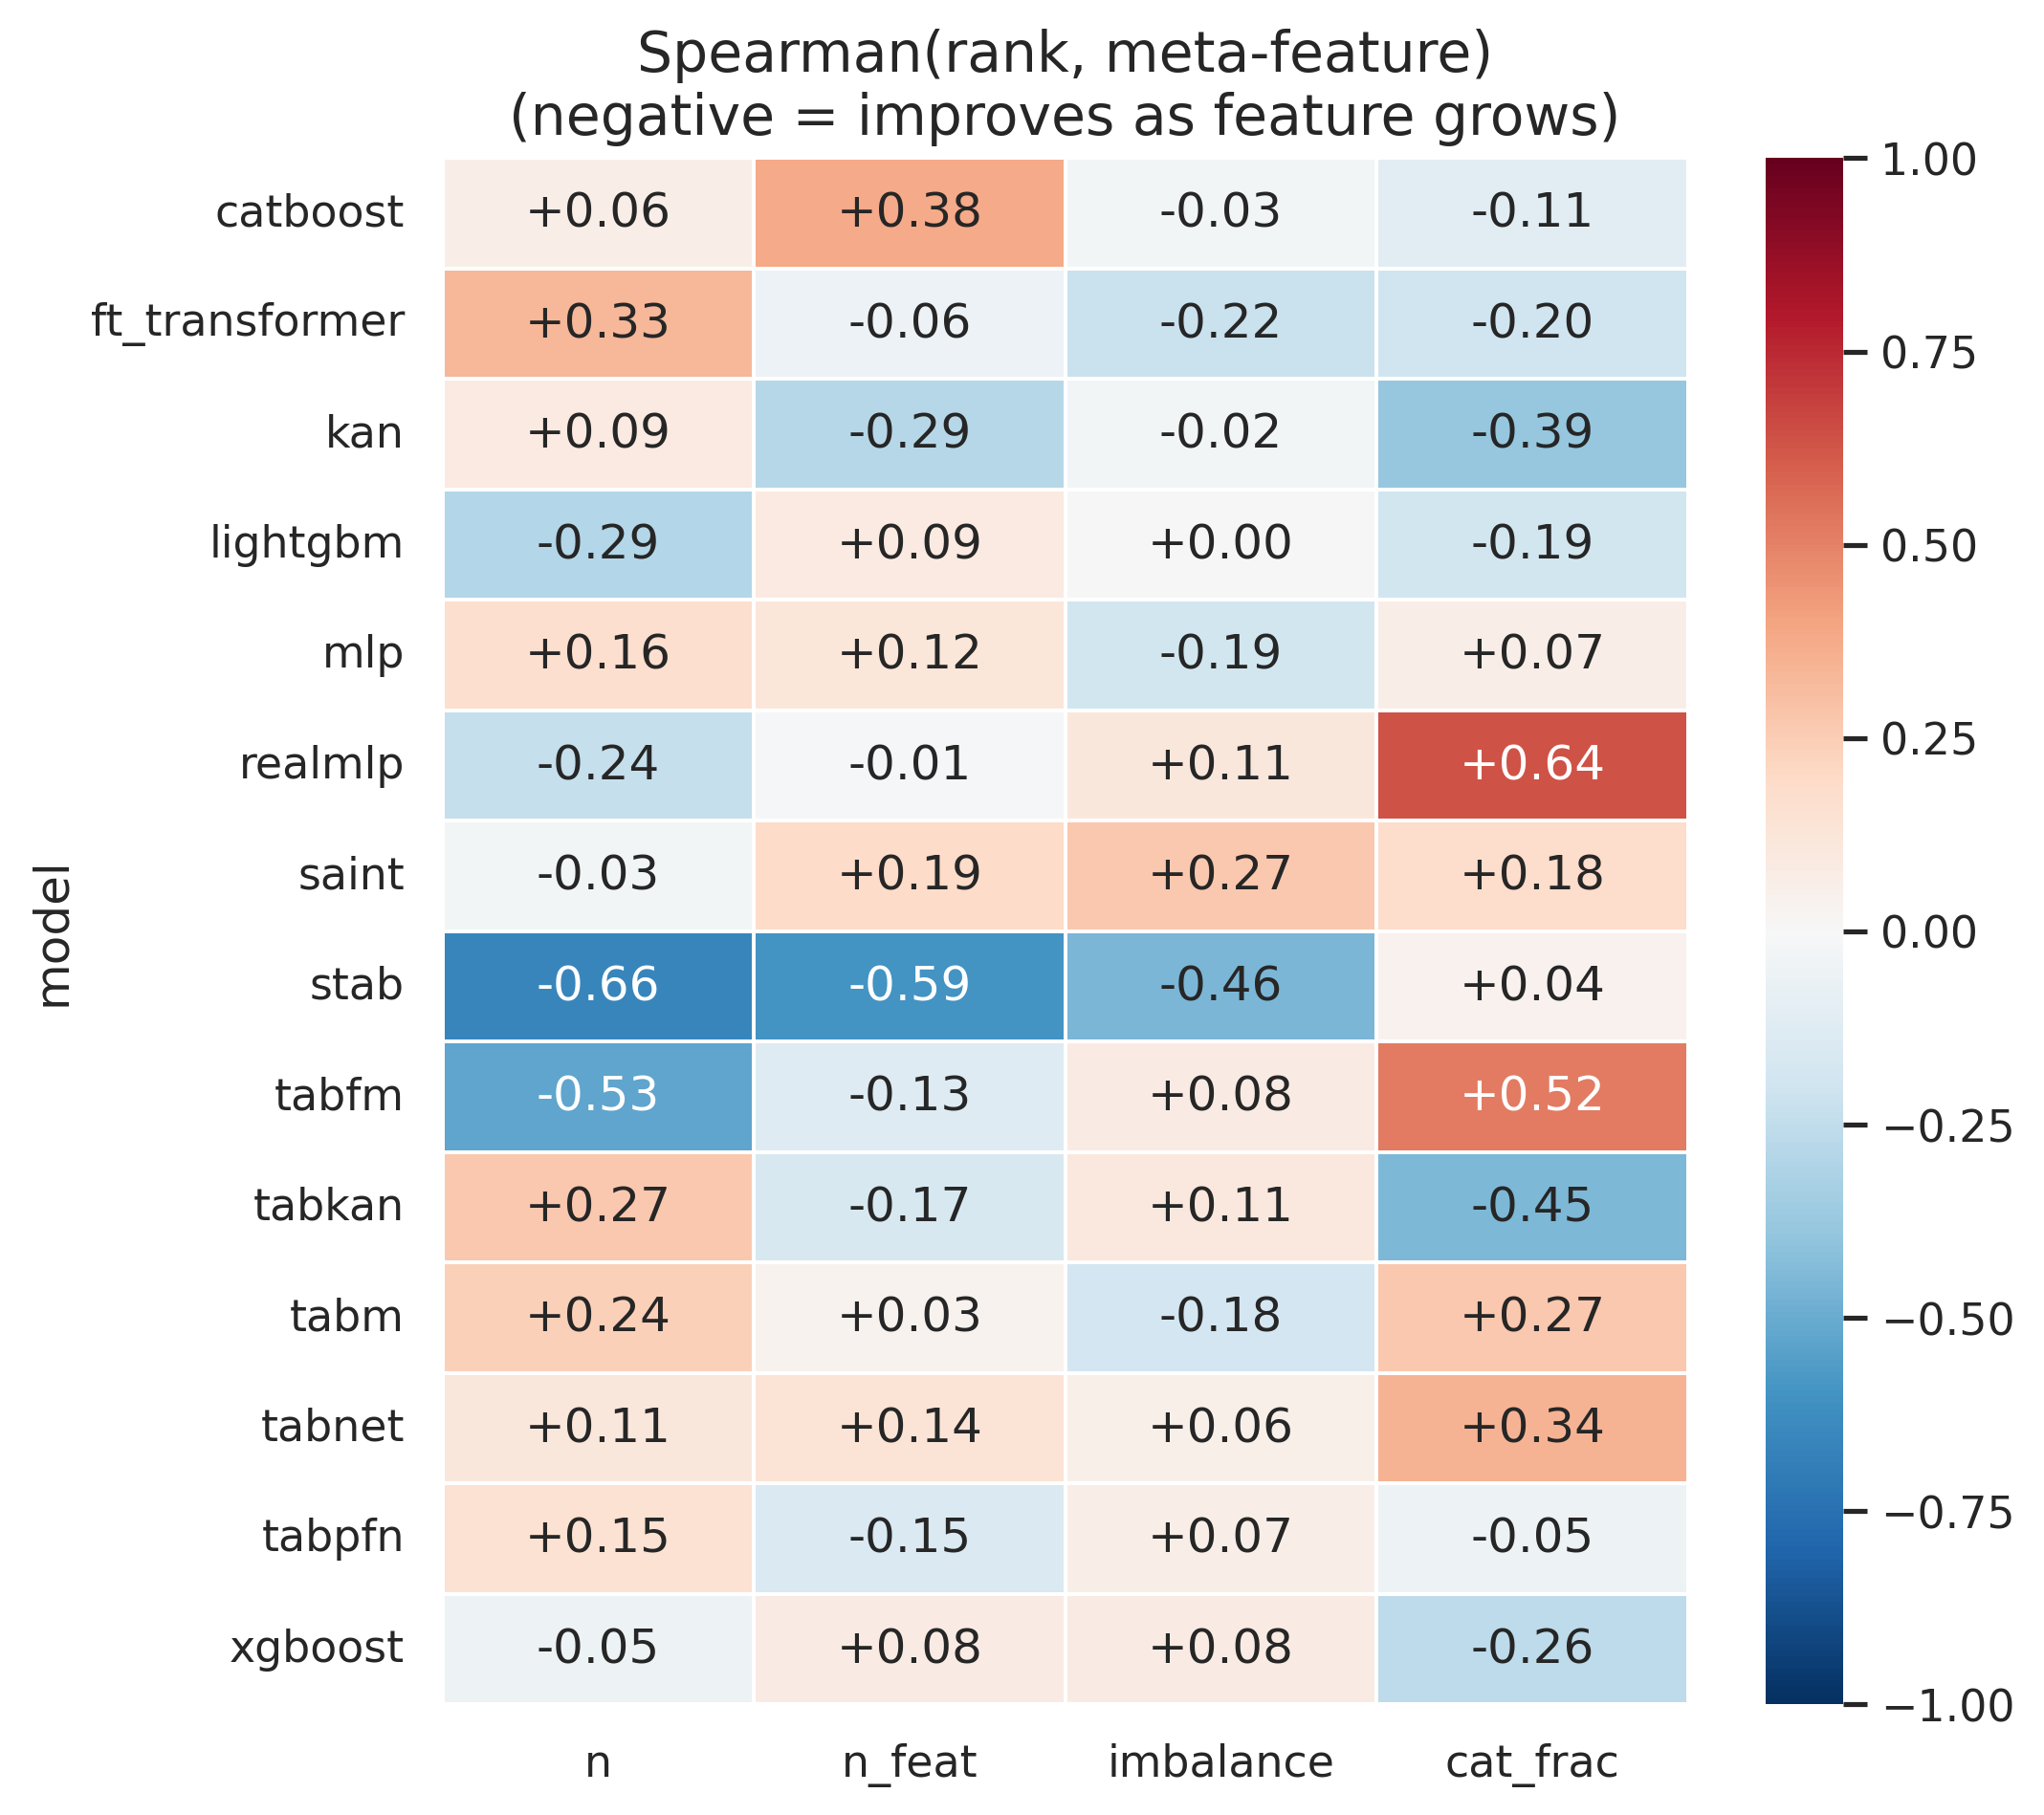

*Correlacao (Spearman) entre o rank de cada modelo e cada meta-feature.*

In [20]:
show('metafeature_correlations.png', 'Correlacao (Spearman) entre o rank de cada modelo e cada meta-feature.', 560)

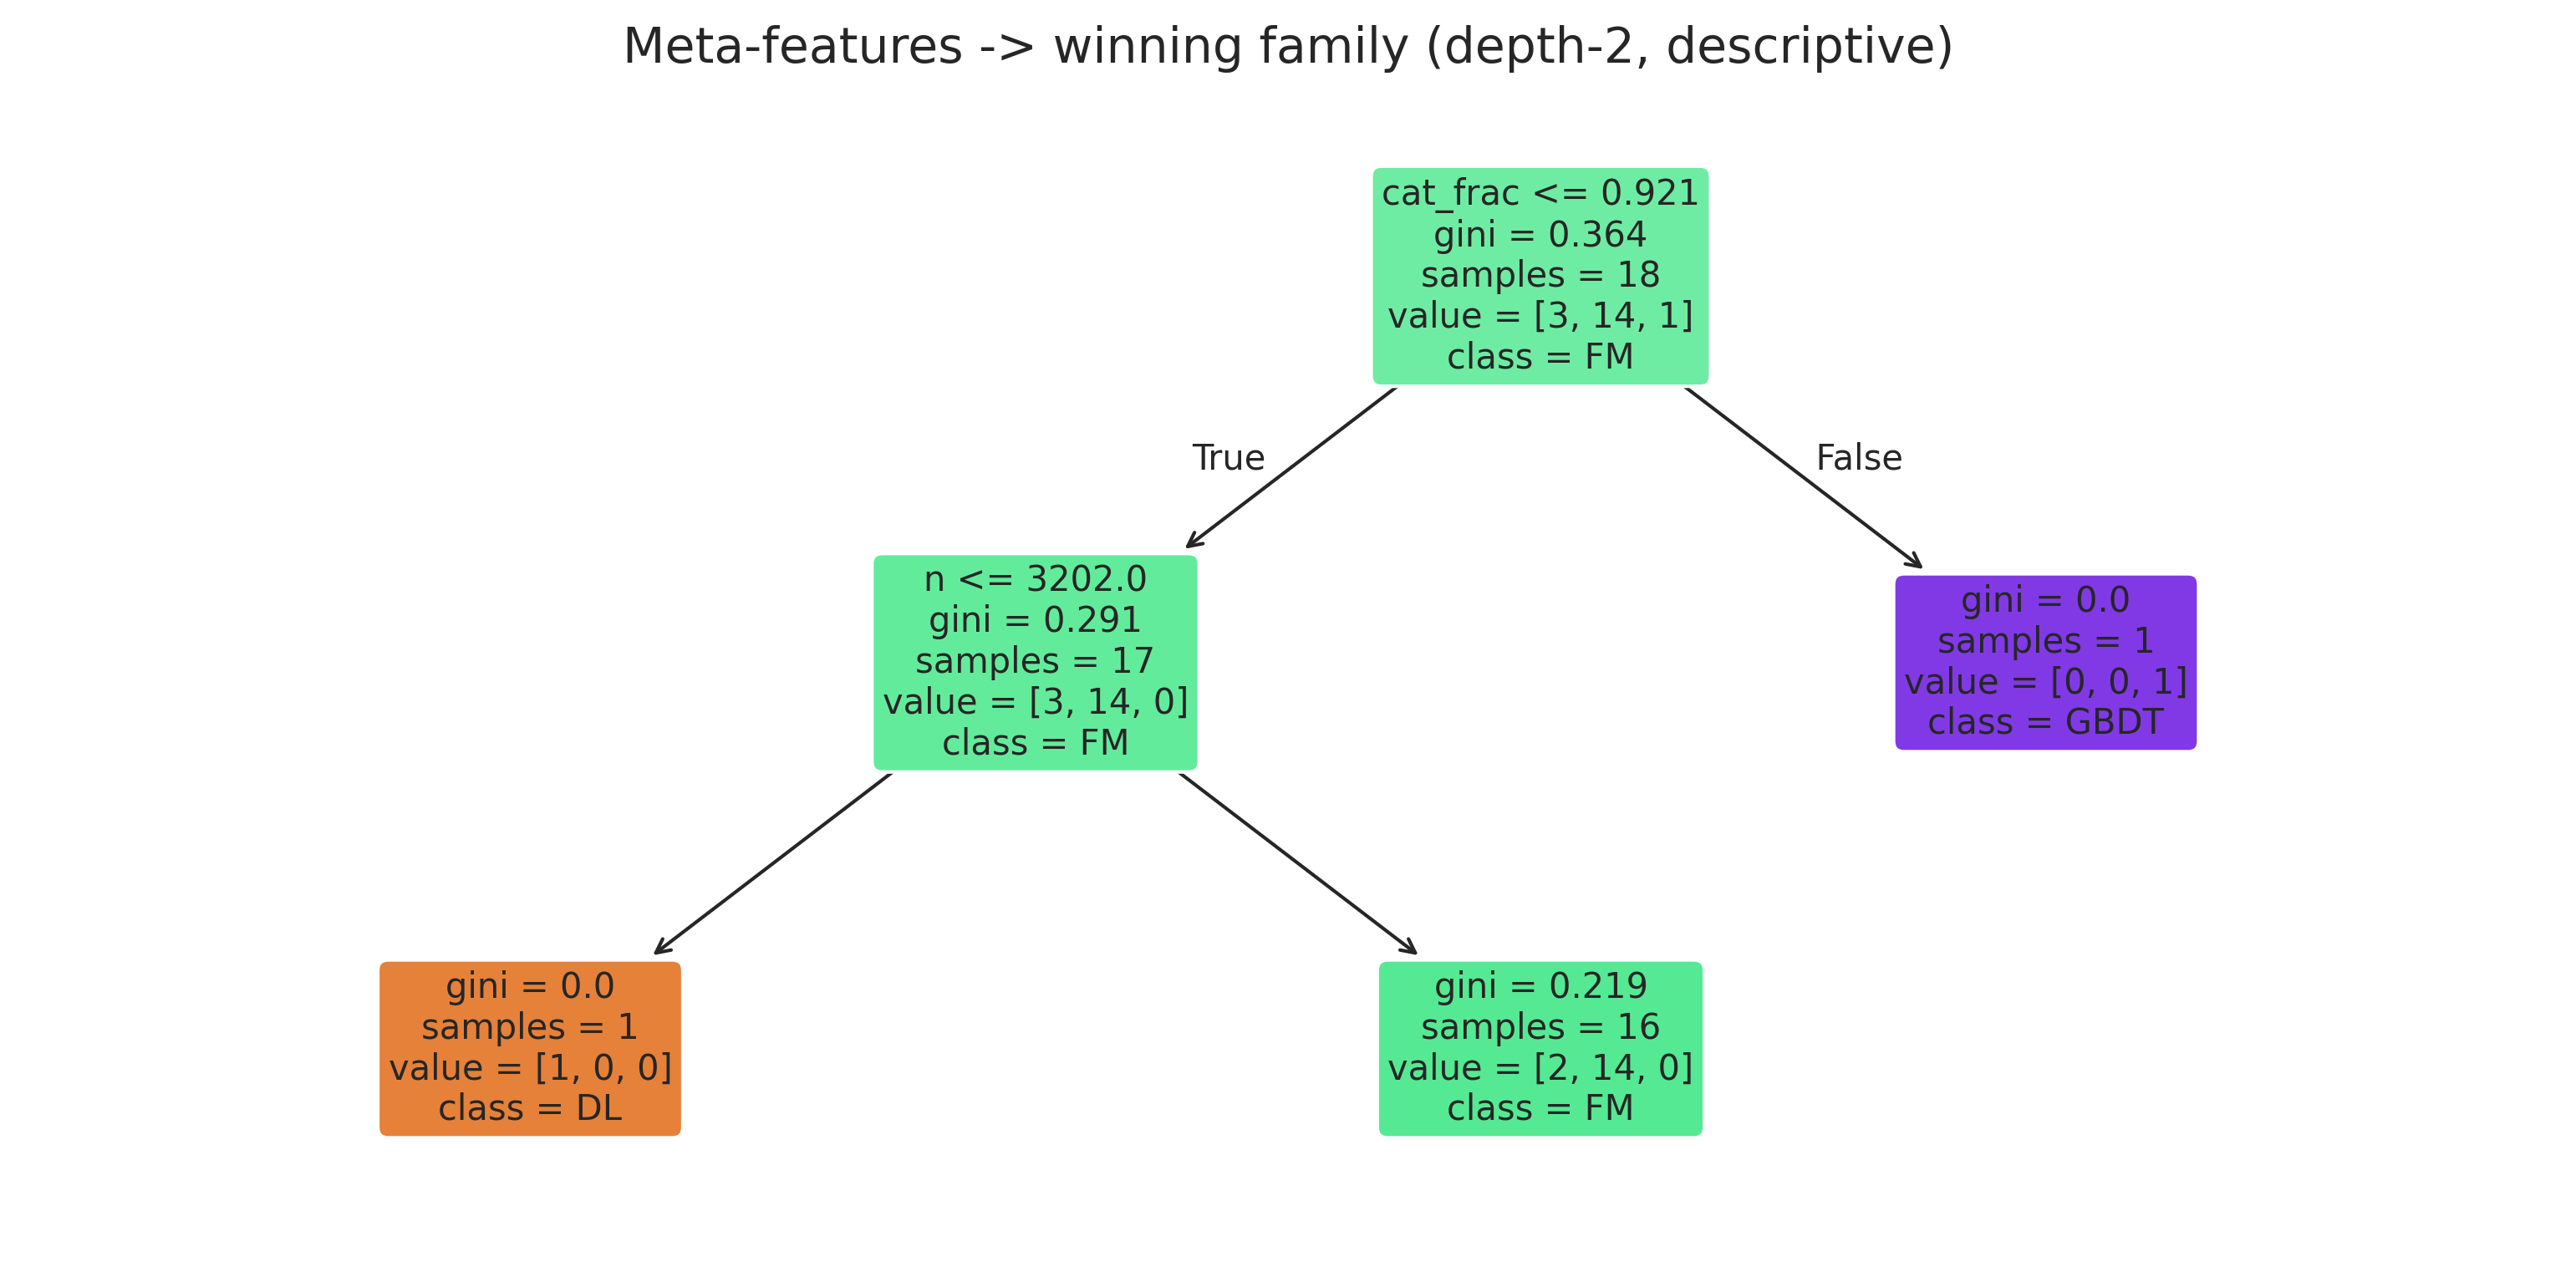

*Arvore meta-features -> familia vencedora: pequeno+poucas features -> TabPFN; grande+poucas -> GBDT; muitas features numericas -> DL.*

In [21]:
show('winner_decision_tree.png', 'Arvore meta-features -> familia vencedora: pequeno+poucas features -> TabPFN; grande+poucas -> GBDT; muitas features numericas -> DL.', 760)

---
## 8. Ato IV — O Framework de Decisão (a contribuição)

Síntese de todos os eixos em **(1)** uma matriz multicritério (pontuada a partir dos dados) e
**(2)** um flowchart prático — inexistente na literatura para o conjunto 2024–2025.

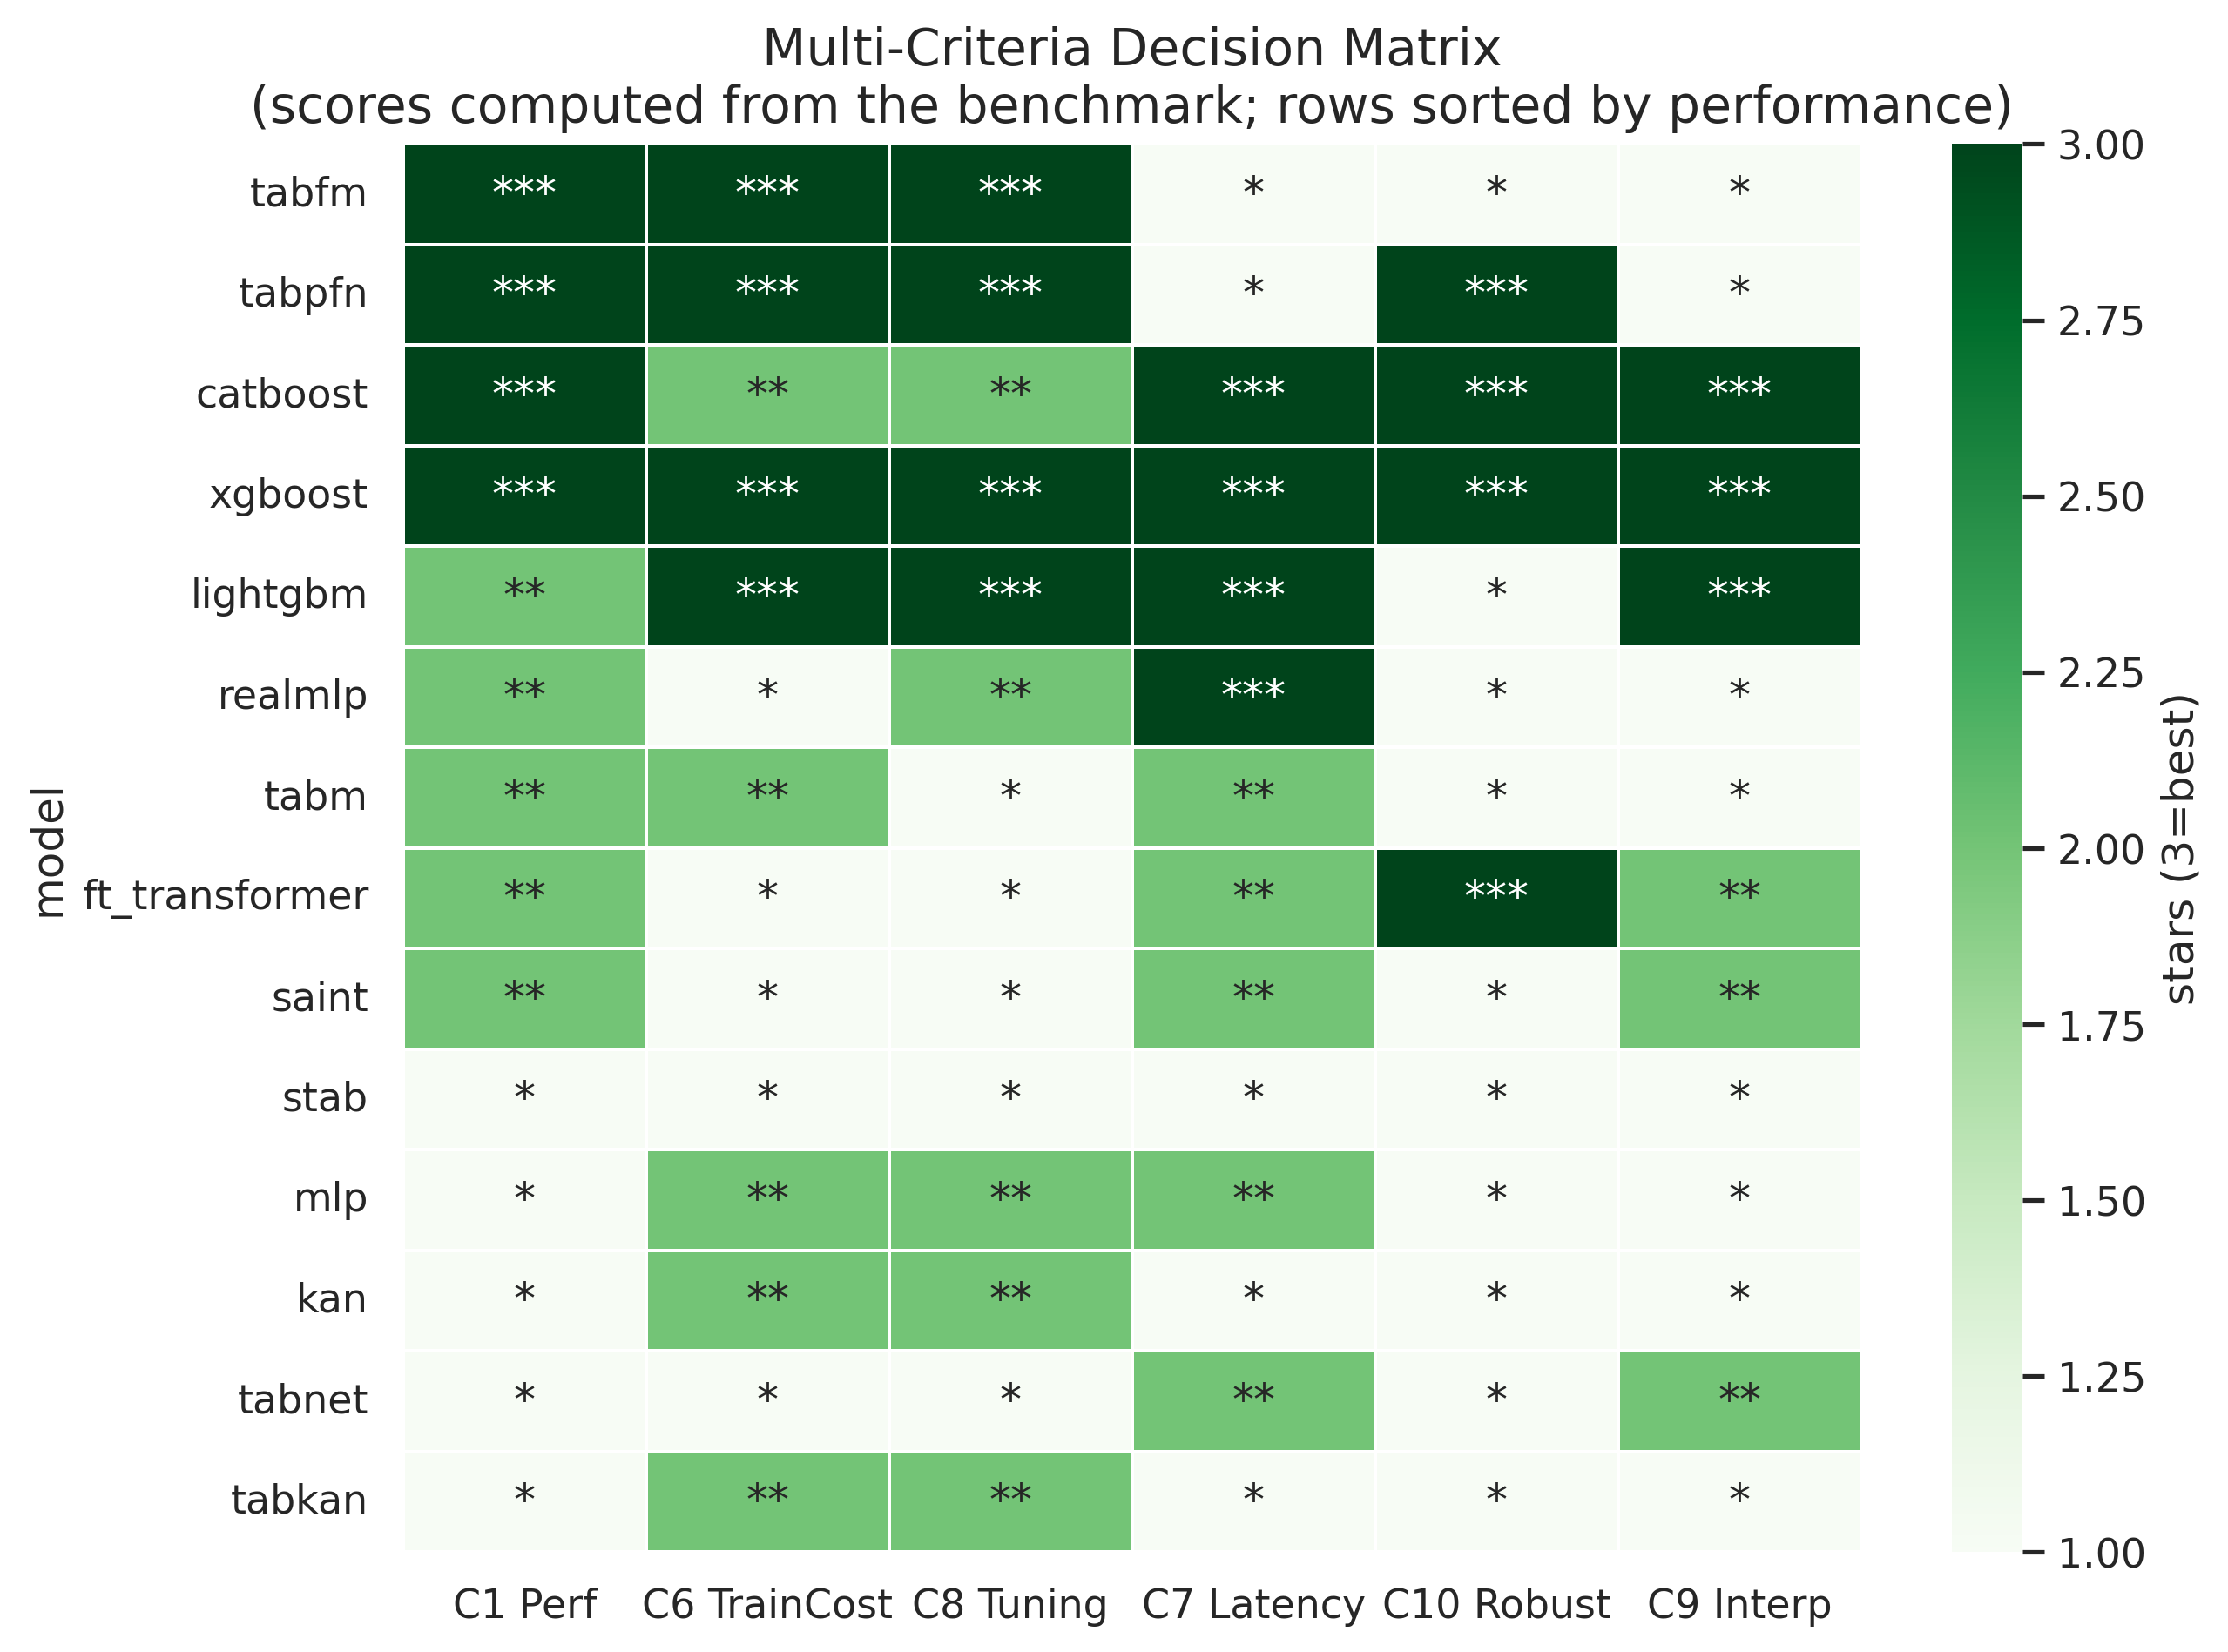

*Matriz de decisao: nenhum modelo e' 3-estrelas em tudo. TabPFN domina perf/tuning/robustez mas e' fraco em latencia; GBDTs sao os all-rounders.*

In [22]:
show('decision_matrix.png', 'Matriz de decisao: nenhum modelo e\' 3-estrelas em tudo. TabPFN domina perf/tuning/robustez mas e\' fraco em latencia; GBDTs sao os all-rounders.', 760)

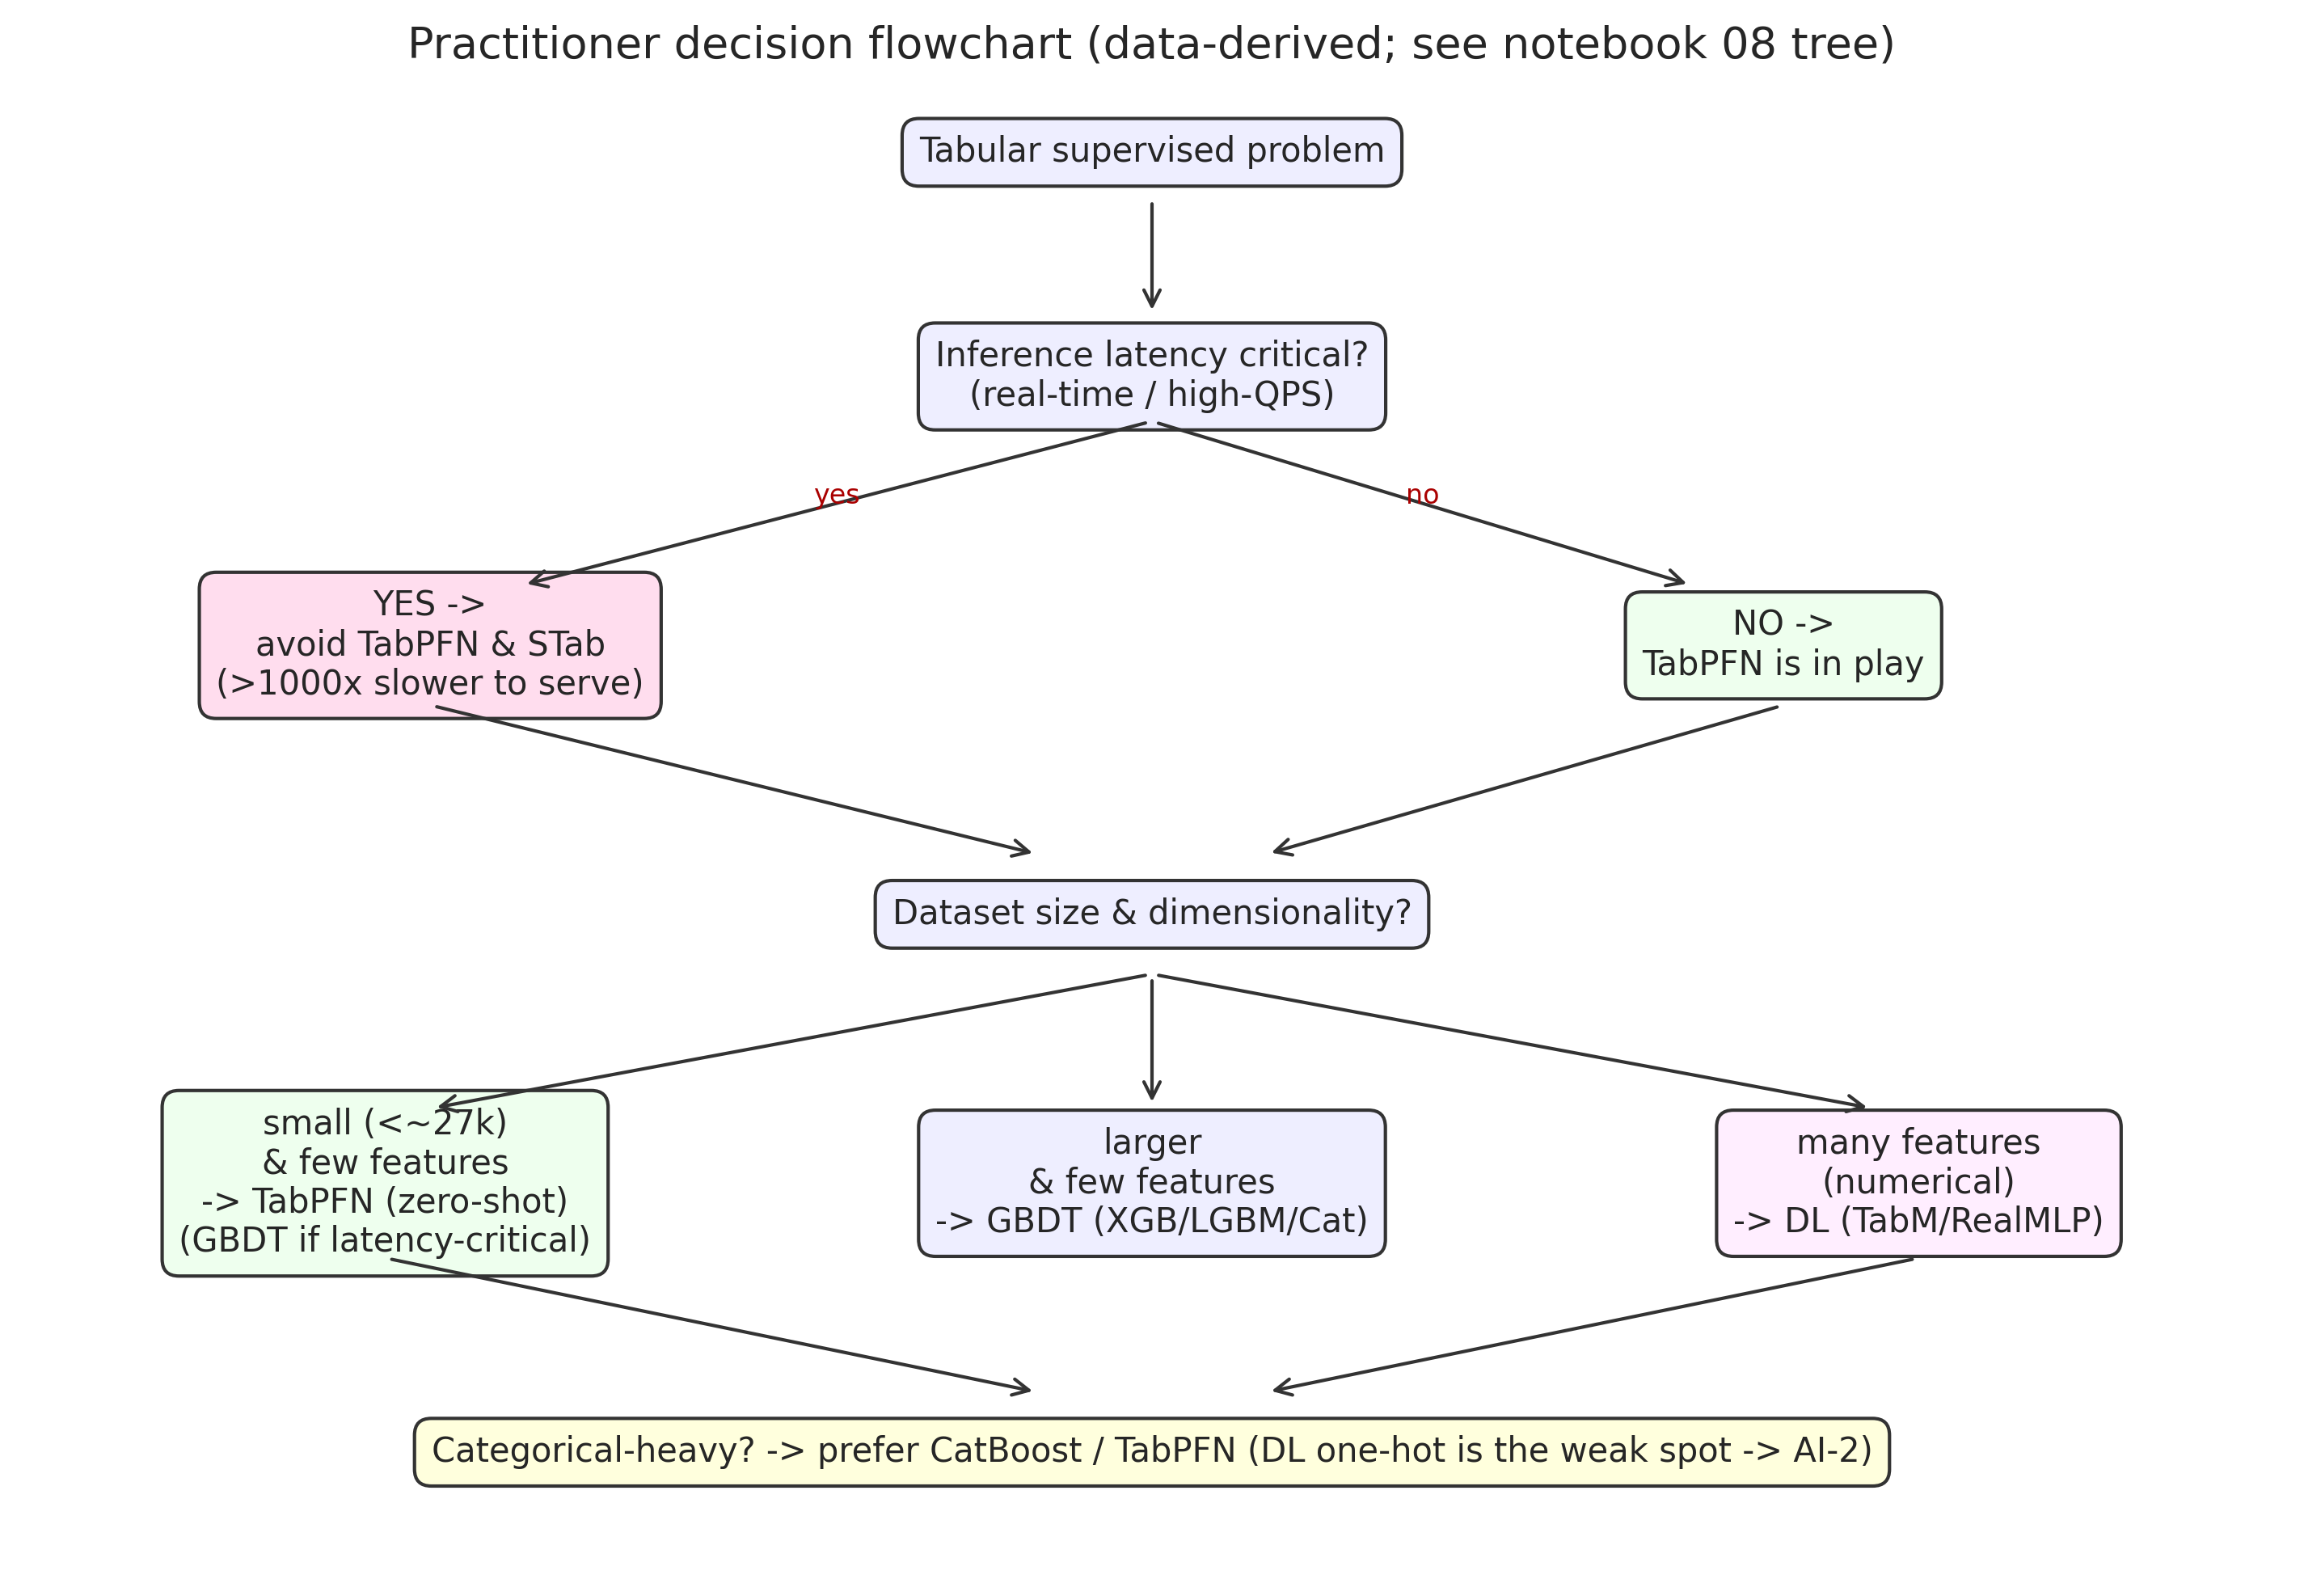

*Flowchart do praticante: responda 3 perguntas (latencia? tamanho/dimensao? categorico?) e obtenha um shortlist defensavel.*

In [23]:
show('decision_flowchart.png', 'Flowchart do praticante: responda 3 perguntas (latencia? tamanho/dimensao? categorico?) e obtenha um shortlist defensavel.', 820)

---
## 9. Interpretabilidade (C9)

GBDTs são intrinsecamente interpretáveis (importância de features, SHAP exato via TreeExplainer);
atenção é parcialmente interpretável; MLP/foundation são caixa-preta (exigem métodos post-hoc).

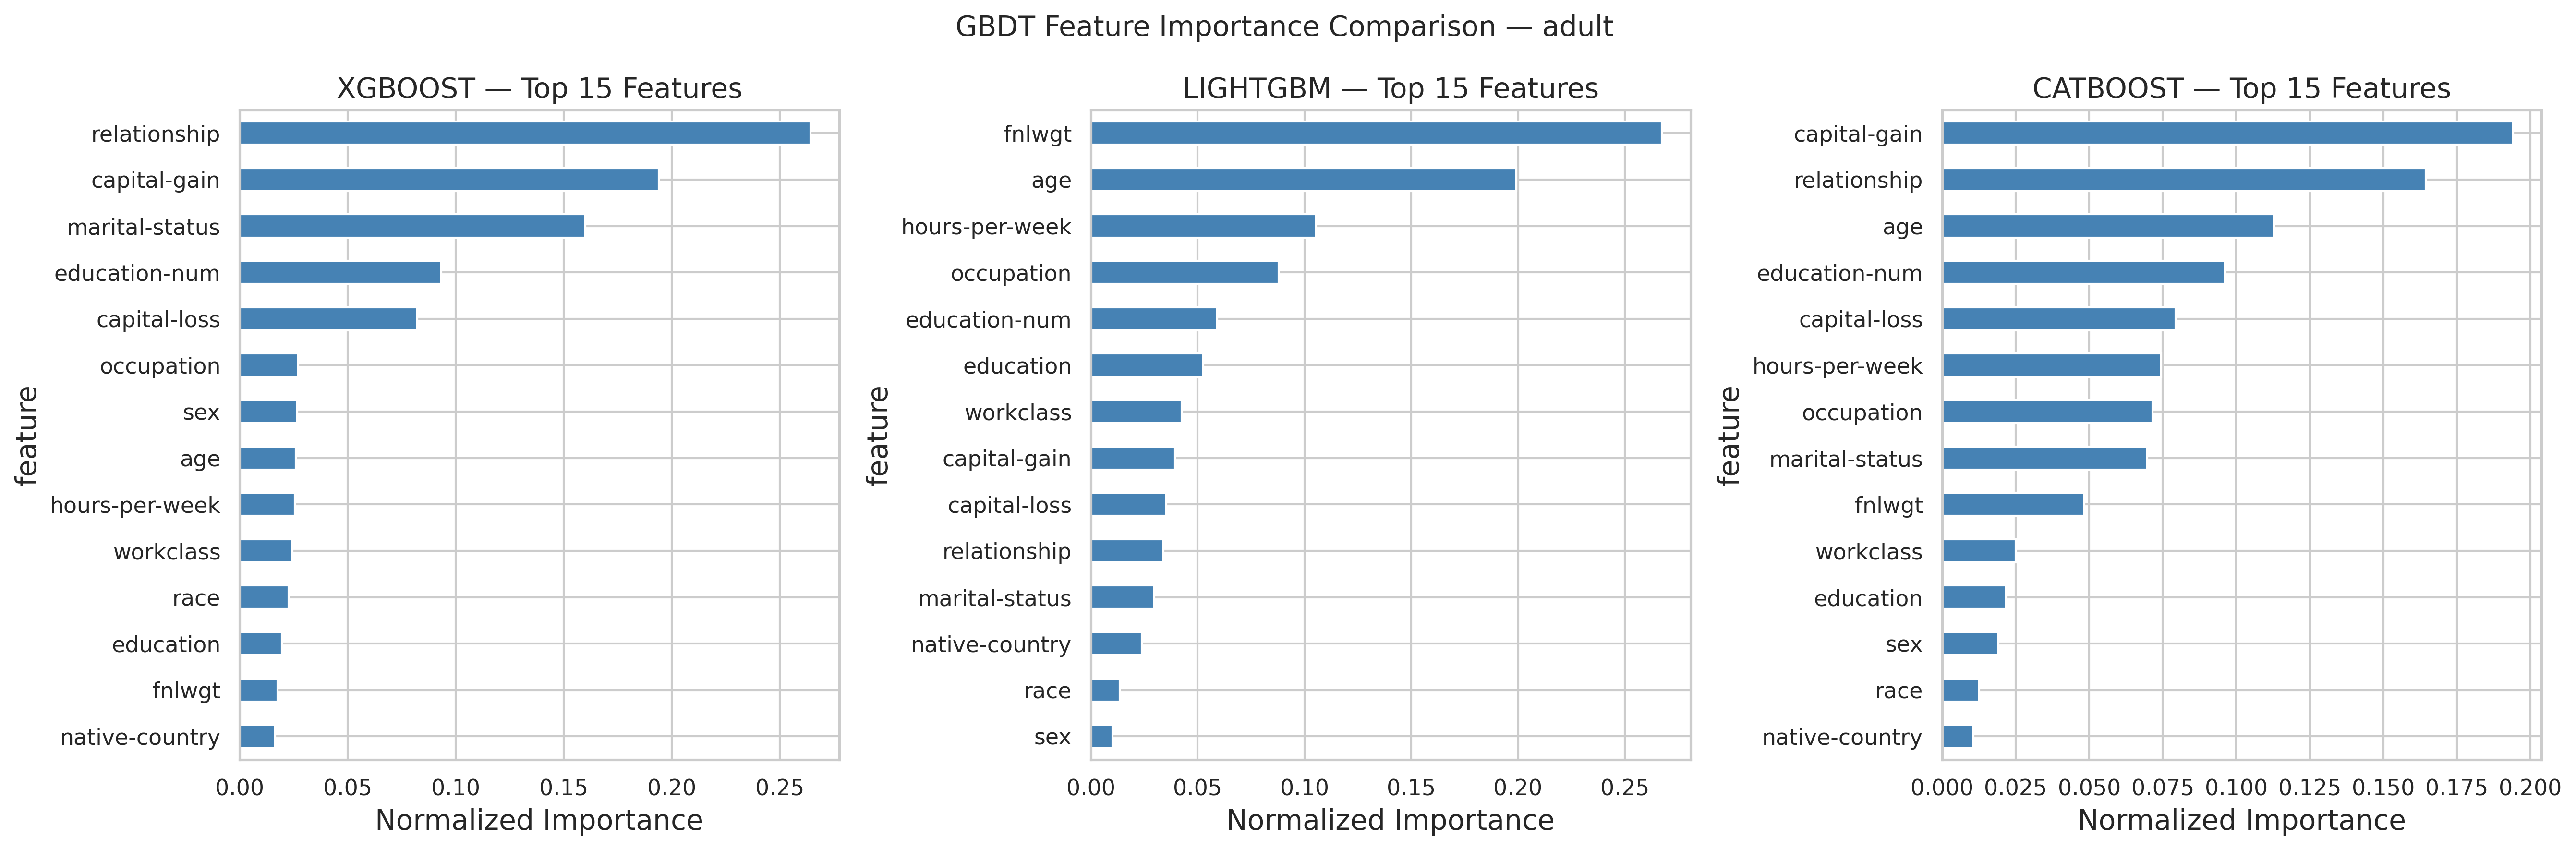

*Importancia de features nos 3 GBDTs (adult) — alta concordancia sobre o que importa.*

In [24]:
show('feature_importance_comparison.png', 'Importancia de features nos 3 GBDTs (adult) — alta concordancia sobre o que importa.', 820)

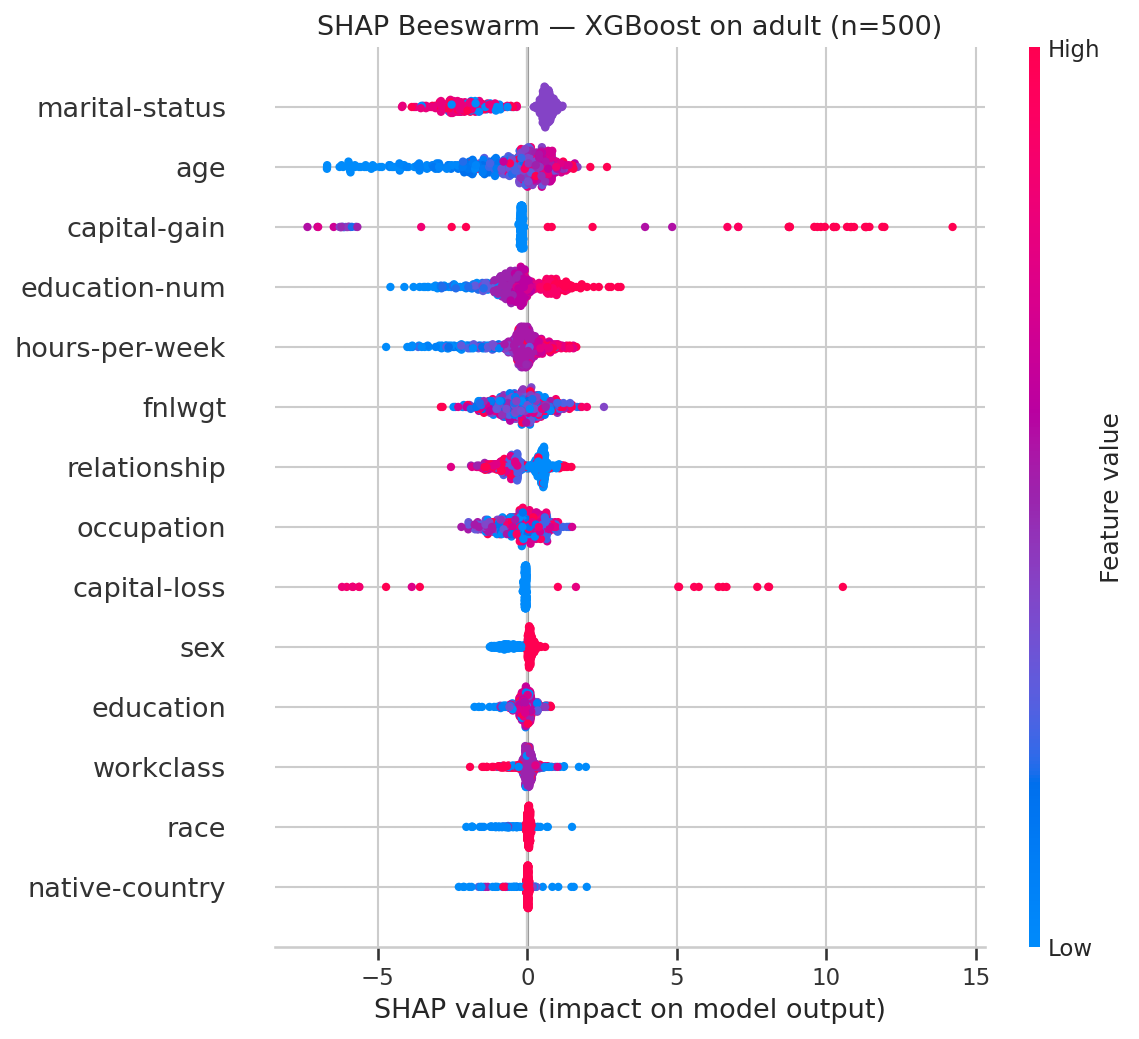

*SHAP (XGBoost, adult): atribuicao por amostra, direcao e magnitude de cada feature.*

In [25]:
show('shap_beeswarm_adult.png', 'SHAP (XGBoost, adult): atribuicao por amostra, direcao e magnitude de cada feature.', 680)

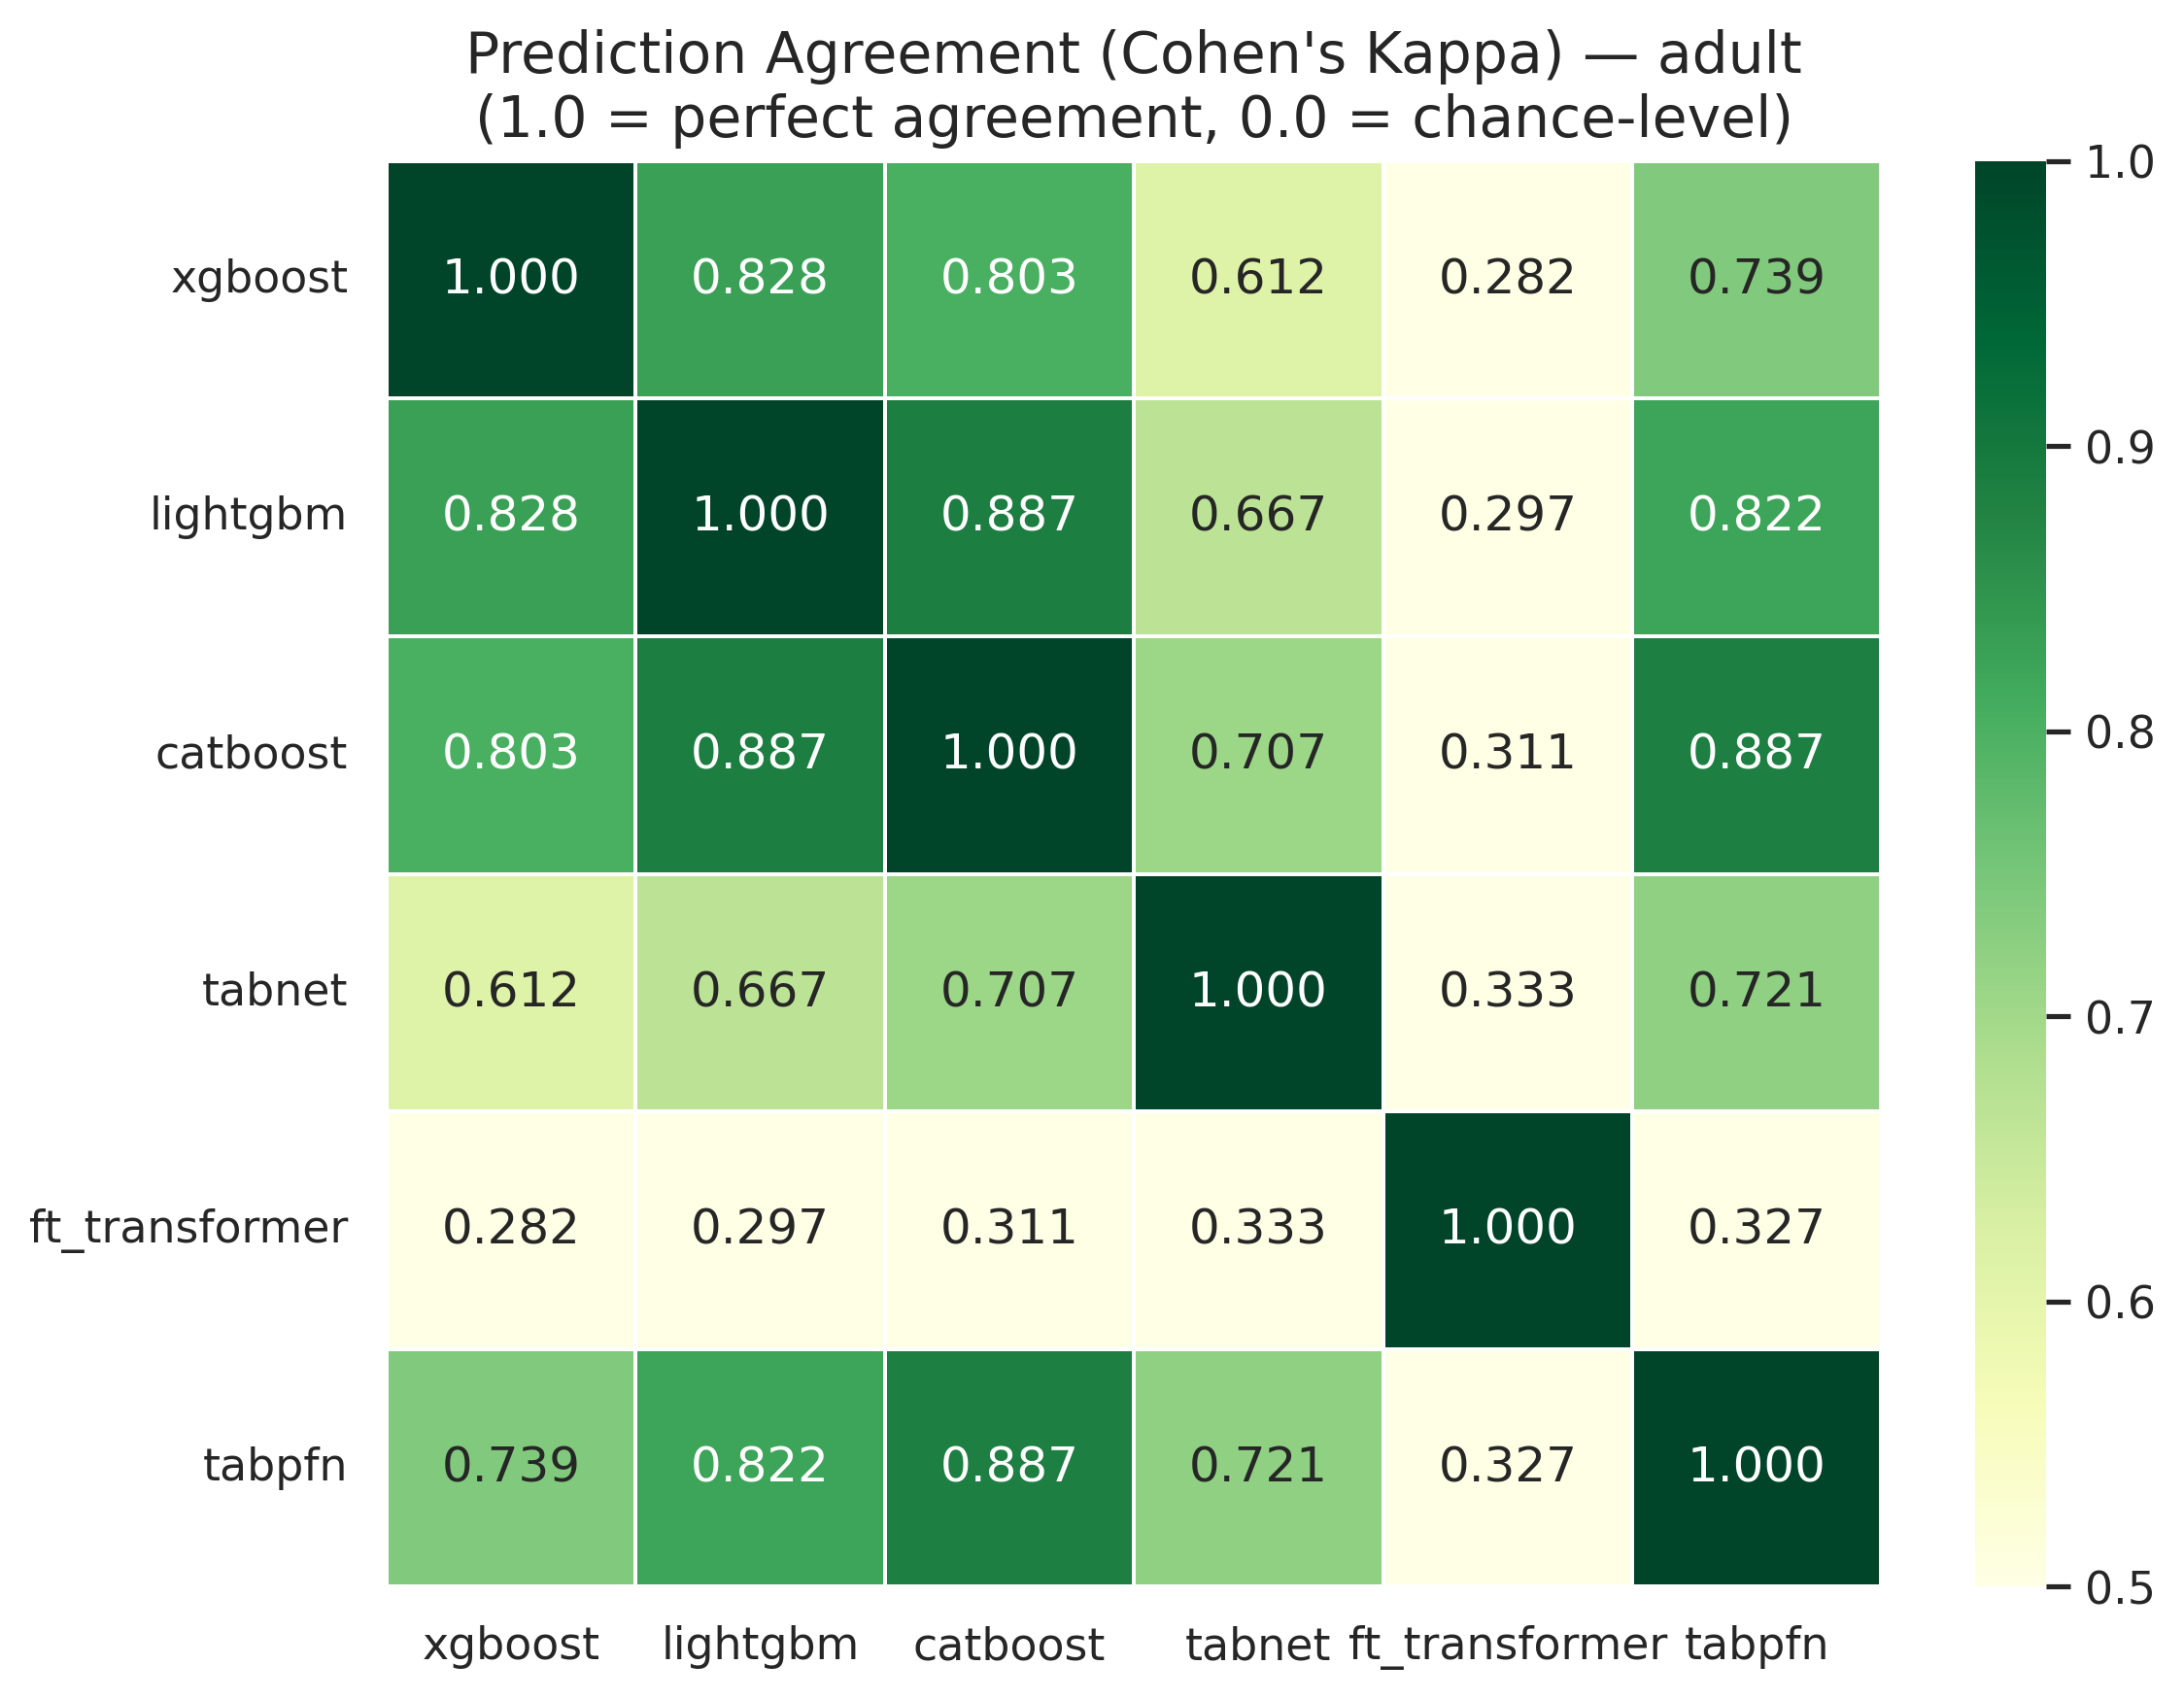

*Concordancia de predicoes (Cohen kappa) entre familias — quanto os modelos capturam padroes diferentes.*

In [26]:
show('prediction_agreement.png', 'Concordancia de predicoes (Cohen kappa) entre familias — quanto os modelos capturam padroes diferentes.', 680)

---
## 10. Honestidade estatística, estado do trabalho e onde mora a AI-2

**Caveats que carrego no texto:**
- **Baixo poder estatístico** (10/3/5 datasets): Friedman acha diferença; a separação fina vem do
  bayesiano (com **sensibilidade do ROPE** reportada) e da consistência entre datasets, não do post-hoc.
  Com N=5 (regressão), o Wilcoxon não pode rejeitar a α=0.05 (piso 0.0625) — declarado, e por isso a
  regressão se apoia em ranks/efeitos/bayesiano.
- **helena (100 classes)** excede o limite dos DOIS foundation models (TabPFN e TabFM) → exclusão
  estrutural documentada (250/252 células).
- **TabFM tem 2 semanas de vida** — sem paper peer-reviewed (citamos blog + model card + versão pinada);
  nossos números referem-se à v1.0.1 e isso é declarado.
- **Multiclasse é sub-amostrado** (N=3) → descritivo. O *bin* severo de desbalanceamento segue
  **confundido** com cardinalidade (amazon_employee).

**Compute concluído nesta fase:**
- Benchmark expandido para **14 modelos** (§6.2) sob protocolo idêntico.
- **Curvas de aprendizado / crossover (RQ2)** (§6.1).
- **Validação LODO do framework** (§6.2/§7) — inclusive o resultado negativo do roteamento.
- **Auditoria formal da metodologia estatística** (Iman-Davenport, sensibilidade do ROPE, pisos de
  p-valor) — `docs/metodologia-estatistica.md`.

**Onde mora a contribuição (AI-2) — atualizado após checagem de novidade (jul/2026):** a política
validada é "**FM primeiro**"; o único obstáculo dela é a **latência** (~100 ms/linha). A contribuição
ataca exatamente isso: **destilação distribucional de foundation models para regressão** — inédita (a
classificação foi coberta pelo Pocket FM, mai/2026, citado como prior work) — com fronteira de Pareto
comparando destilar × comprimir contexto × cachear. Desenho pré-registrado com hipóteses falsificáveis
(`docs/desenho-experimental-destilacao.md`); piloto em andamento. Sucesso é **mover a fronteira de
Pareto**: acurácia de FM a latência de GBDT.

---
### Reprodutibilidade
seed=42 fixo · hash SHA-256 de cada dataset gravado por experimento · configs versionadas
(`configs/*.yaml`) · 250/252 resultados + notebooks executados no GitHub · versões pinadas (incl.
commit do tabfm) · análises em `src/evaluation/enrichments.py` · programa de pesquisa completo em
`docs/programa-de-pesquisa.md`.